# Kandinsky 2.2 ControlNet-depth — DIMER guided notebook: depth-conditioned generation and LoRA fine-tuning (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/kandinsky-controlnet-depth-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/kandinsky-controlnet-depth-pipeline/blob/main/tutorials/kandinsky_controlnet_depth_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-kandinsky--2--2--controlnet--depth-ffcc4d?style=flat)](https://huggingface.co/kandinsky-community/kandinsky-2-2-controlnet-depth) [![Upstream](https://img.shields.io/badge/Upstream-ai--forever%2FKandinsky--2-181717?style=flat&logo=github&logoColor=white)](https://github.com/ai-forever/Kandinsky-2) [![License](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://www.apache.org/licenses/LICENSE-2.0)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** depth-conditioned text-to-image generation (photograph → depth hint → prompt + hint → 512 × 512 image), held-out denoising-loss, CLIP and depth-fidelity evaluation, and bounded LoRA fine-tuning to a set of captioned photographs

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/kandinsky_controlnet_depth_pipeline/`, at revision `bbcf3379f563`), the stage runner, the hash-locked requirements (68 packages), the pinned snapshot manifests and the licence, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, the Hugging Face Hub at the immutable revision `08632524a2b7e3bed39a7901d92cdd07e37544d0` and its three companion revisions (~17836 MB, digest-verified before loading), and the public sample-data bucket named in the Prerequisites. It was generated by `tools/build_notebook.py` (build_notebook.py/3.0); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux **GPU** runtime (a 16 GB T4 is enough; see the Prerequisites) builds an isolated Python environment from the carried hash-locked requirements (torch, diffusers, transformers, peft, accelerate, sentencepiece, safetensors, huggingface-hub, numpy, pillow and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it stages and digest-verifies four pinned snapshots from the Hub — the 5.29 GB Kandinsky 2.2 ControlNet-depth decoder (UNet + MoVQ), the 10.57 GB Kandinsky 2.2 diffusion prior, the 1.37 GB DPT depth estimator and a 0.6 GB CLIP scorer — fetches 60 CC0 iNaturalist bird photographs as digest-verified JPEGs (6 MB, no credential), validates them and splits them 36 / 12 / 12 by seed, turns every photograph into a depth hint and every caption into an image embedding (then releases the prior), scores the frozen model — the held-out denoising loss, and twelve depth-conditioned generations scored for prompt alignment, similarity to the held-out photographs and depth fidelity against a mismatched-hint baseline — runs a guided change-one-thing activity on the hint, runs a bounded LoRA fine-tuning (4 epochs over 36 images) and exports the adapter as safetensors with a manifest, scores the exported adapter in a fresh process on identical inputs, and reloads it in a second fresh process to verify parity with the trained in-memory model before rendering a new prompt on an existing depth layout. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart (NOTEBOOK_SPEC 2.2 §5). The whole run took about 19 minutes on a Kaggle T4 (1,156.2 s, measured 2026-09-29 with an empty model cache, so the downloads are included) at the previous revision of this notebook, which ran the same stages; this revision changes explanations and small printed outputs only.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and re-run from that cell to supply your own captioned photographs as a zip holding `captions.csv` (columns `id`, `file`, `caption`) beside the image files (JPEG or PNG, shorter side 256..4096 px). The split is stratified within each caption: a caption with 3..7 distinct images gives one test and one validation image (about 20 % each from 8 images on), a caption with one or two images goes to training only, and at least 4 training images must remain — so at least **6 distinct images**, for example six of one caption; two captions of three images each are refused (2 training images). The split assumes your photographs are independent: remove near-duplicates (bursts, crops or edits of one scene), because only byte-identical copies are detected. Set `BYOD_PATH` to a zip already in the runtime to skip the upload dialog. Your photographs get depth hints from the same estimator and flow through the same contract — validation, hints and prompt encoding, frozen baseline, adaptation, held-out evaluation, generation, artifact export and reload parity. The expected schema, the limits and the privacy guidance are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. An invalid zip stops Section 4 with the validator's own message. BYOD is optional and never part of the default path.

Kandinsky 2.2 ControlNet-depth is a version of the Kandinsky 2.2 latent diffusion decoder that was retrained to follow a **depth map** as well as a text prompt. A frozen diffusion prior turns the prompt into a CLIP image embedding; a 1.25 B-parameter UNet removes noise from a small latent image while reading that embedding and a 512 × 512 depth hint; a MoVQ decoder turns the latent into pixels. The hint is produced by a separate model, the DPT depth estimator `Intel/dpt-large`, from an ordinary photograph. The result is an image whose *content* follows the words and whose *layout* follows the photograph's depth.

### Who this notebook is for

This notebook is for a learner who can open a hosted notebook, run cells and read basic Python, and who is new to conditioned diffusion models. No prior experience with diffusion training is assumed; the terms are explained where they first matter and collected in the glossary below. You need a Linux GPU runtime (a free Colab T4 is enough), about 31 GB of free disk and roughly an hour, much of it downloads.

### How to use this notebook

1. In Colab choose **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**. Nothing needs to be edited for the default path, and no runtime restart is needed.
2. Cells titled **Infrastructure** (Sections 1–3) check the runtime, carry the repository's code, build an isolated Python environment from hash-locked packages and download the pinned models. They are collapsed; run them without studying them.
3. **Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory — the verified snapshots, the depth hints, the prompt embeddings, the frozen model's images, the adapter artifact and JSON records — and GPU memory is released when each stage ends.
4. Sections 4–10 are the lesson. Each principal step starts with a **question** and, where it makes sense, asks you to **predict** the result first. After the cell, read **What to notice**, then open **Check your reasoning** to compare your answer.
5. Values you may change are **form fields** (the `# @param` lines). The canonical run uses their defaults; Section 7 is the place to change one of them deliberately.
6. Every output is written under `outputs/` in the run directory that Section 1 creates.

### Roadmap

| Section | Kind | What happens |
|---|---|---|
| 1–3 | *Engineering* | check the runtime, carry the code, build the isolated environment, verify four model snapshots |
| 4 | *Core concept* | real captioned photographs, validation, a seeded split |
| 5 | *Core concept* | photograph → depth hint; caption → image embedding |
| 6 | *Evaluation practice* | the frozen model: loss, generations, three kinds of score |
| 7 | *Core concept* | **change one thing**: give the model a different hint |
| 8 | *Core concept* | bounded LoRA fine-tuning and adapter export |
| 9 | *Evaluation practice* | the paired before/after comparison, from the exported adapter |
| 10 | *Engineering* | a fresh reload with parity, and a new prompt |
| 11 | *Engineering* | troubleshooting |

**Fast path:** if time is short, run everything and read only Sections 5, 6, 7 and 9.

### Input → Model/System → Output

`photograph` → **DPT depth estimator** → `depth hint (512 × 512)`; `caption` → **diffusion prior** → `image embedding`; `(hint, embedding, noise)` → **UNet + MoVQ** → `512 × 512 generated image`. For adaptation: `{id, image, caption}` records → hints + embeddings + latents → **LoRA training** → `adapter.safetensors` + `manifest.json`.

<details>
<summary><b>Glossary</b> (open when a term is unfamiliar)</summary>

- **Latent diffusion:** the model works on a compressed 64 × 64 × 4 *latent* instead of pixels; generation starts from noise and removes a little of it at each *step*.
- **Depth hint:** a greyscale map where brighter means nearer. Here it is estimated by DPT, so it is *relative* depth, not metres.
- **ControlNet-style conditioning:** an extra input (the hint) that constrains *where* things are, while the prompt says *what* they are.
- **Prior / image embedding:** the prior turns text into the CLIP image embedding the decoder expects.
- **Classifier-free guidance:** each step is computed with and without the prompt and pushed towards the prompt by `guidance_scale`.
- **Denoising loss (MSE):** how far the model's noise prediction is from the true noise added to a real photograph's latent — the training objective.
- **LoRA:** small low-rank matrices added beside frozen weights; only they are trained.
- **CLIP similarity:** cosine similarity between a CLIP embedding of an image and of a text (or another image), × 100.
- **Depth fidelity:** how closely the estimated depth of a generated image follows the hint it was given (correlation, and error after aligning scale and offset).
- **Held-out:** records never used for training or for choosing the kept epoch.
- **Hash-locked environment:** a separate Python environment built from a requirements file that pins every package to one version and one set of SHA-256 digests; the installer refuses anything else.
- **Stage:** one step of the workflow run as its own process by `run_stage`; it reads the files earlier stages wrote and writes its own.
</details>

Two properties are handled in the open. **The prior pipeline can be released before training:** Section 5 encodes every prompt the notebook uses and then drops the prior, so the UNet, the depth estimator, the scorer and a training graph fit comfortably on a 16 GB GPU. **Generation has no ground truth**, so the notebook reads three kinds of number: the held-out *denoising loss*, CLIP scores beside a leave-one-out real-photo reference (a reference line, not a ceiling), and *depth fidelity* against a mismatched-hint baseline. None of these is a human judgement of image quality.

**About the decoder weights.** The upstream repository's `main` branch ships only pickled `.bin` files. This notebook downloads the safetensors files of the repository's open, unmerged conversion pull request, addressed by its immutable commit and verified by SHA-256. Whether that conversion is bit-identical to `main` is checked separately by `tools/verify_conversion.py` in the repository; that check is recorded in the model card.

**Learning objectives:** after this notebook you should be able to **explain** how a depth hint and a text prompt divide the work of conditioning a diffusion model; **produce** a depth hint from a photograph with a pinned estimator and **inspect** it; **predict** and then **observe** what happens to a generation when only the hint changes; **interpret** a held-out denoising loss, CLIP scores beside a leave-one-out real-photo reference and a depth-fidelity score against a mismatched-hint baseline; **run** a bounded LoRA fine-tuning with explicit hyperparameters and **compare** the adapted and frozen models on identical held-out inputs; and **verify** that an exported safetensors adapter, reloaded in a fresh process, reproduces the trained model's outputs.

**This notebook does not demonstrate:** other ControlNet conditions (edges, pose, segmentation), image-to-image or inpainting, resolutions other than 512 × 512, metric (absolute) depth, full fine-tuning, safety filtering of prompts or images, human preference benchmarks, prompt engineering, and any claim that a CLIP score, a depth-fidelity score or a denoising loss measures image quality. The repository exposes none of these.

## Prerequisites

- **Audience:** comfortable running notebook cells and reading short Python; no diffusion-training experience needed.
- **Runtime:** a fresh supported **Linux x86_64 GPU** runtime (Google Colab T4 or better, Kaggle T4, or a Linux Jupyter kernel with a CUDA GPU of at least 15 GB). The kernel's own Python version does not matter: the notebook installs nothing into it, and runs every stage with CPython 3.12.12 in an isolated environment built from 68 hash-locked packages (torch 2.14.0, whose Linux wheel is the CUDA 13.0 build). The prior runs in float16 while it encodes prompts and is then released; the UNet runs in float16 (2.5 GB) with the LoRA parameters in float32; the MoVQ decoder and the DPT estimator run in float16. CPU-only runtimes are not supported for this notebook. About 18 GB of disk is needed for the snapshots (the Section 1 check asks for 19 GiB, with headroom) and about 12 GB for the isolated environment.
- **Knowledge:** what a diffusion model does at inference (noise → latent → pixels over several steps), what classifier-free guidance is, what a LoRA adapter changes and what it does not, and why a training loss is not a quality score. The glossary above covers each term.
- **Weights:** the decoder, the prior, the depth estimator and the CLIP scorer are all loaded from safetensors; nothing is unpickled and no Hub-hosted code is executed — the model classes come from `diffusers`, `transformers` and `peft` on PyPI. The decoder safetensors come from an open, unmerged conversion pull request of the upstream repository, pinned by commit. Upstream weights are Apache-2.0; the scorer is MIT.
- **Data contract:** a record is `{id, image, caption}` — an RGB image with shorter side 256..4096 px (resized so the shorter side is 512 px and centre-cropped to 512 × 512; the crop is reported) and a caption of 1..1000 characters. Its depth hint is computed from the cropped image. Validation is structural: nothing checks that a caption describes its image, that a depth map is plausible, or that the model can render the prompt.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — photographs of identifiable people, licensed stock images or client material are exactly that. A depth map can still reveal the layout of a private space. The default path uploads nothing.
- **External access (data):** besides the Hub, the default path fetches 60 pinned photographs (about 6 MB) from the public iNaturalist open-data bucket `inaturalist-open-data.s3.amazonaws.com` over HTTPS, digest-verified before decoding; every photo is CC0 and its observation page is recorded.
- **External access:** the Hugging Face Hub, to fetch the pinned `kandinsky-community/kandinsky-2-2-controlnet-depth` snapshot and its companions (~17836 MB in total) at revision `08632524a2b7…` and the revisions in the carried manifests; PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 68 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime

**Section type:** Engineering.

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with a CUDA GPU and enough free disk, and creates a new run directory. **Output:** the GPU name and the directories this run will use. Each run writes to a new directory under `outputs/kandinsky_controlnet_depth/`, so an earlier export cannot be mistaken for a current result. The verified snapshots are kept in `weights/` and reused by a later run.

In [ ]:
# @title Infrastructure: check the runtime, GPU and disk; create a fresh run directory
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 GPU runtime (Google Colab or Kaggle with a T4 or better): its locked environment is built for manylinux x86_64.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
except FileNotFoundError as exc:
    raise RuntimeError('No GPU driver was found. Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if gpu.returncode:
    raise RuntimeError('CUDA was not detected. Select a fresh T4 GPU runtime, then Run all.')
STEM = 'kandinsky_controlnet_depth'
ROOT = Path.cwd() / 'outputs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ROOT.name)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 19.0 - staged_gib), 'environment': 12.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'gpu': gpu.stdout.strip(), 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'gpu': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0', 'weights': '/content/weights', 'environment': '/tmp/kandinsky_controlnet_depth_env_5a1517e18af0', 'free_gib': {'weights': 193.2, 'environment': 193.2}}


**What to notice:** one dictionary naming the GPU (for example `Tesla T4, 15360 MiB`), the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a GPU or disk message, see Section 11.

## 2. Carry the code and install the locked runtime

**Section type:** Engineering.

> **Infrastructure.** The next two code cells are collapsed. The first **is** the repository's code, carried so that this notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's four modules under `src/kandinsky_controlnet_depth_pipeline/` (identity constants, snapshot verification and staging, validation, the pipeline class with its depth hints, the sample corpus, and the CLIP and depth-fidelity metrics), the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (68 packages), the four snapshot manifests and the licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The text is the repository's files byte for byte; the repository's parity test (`tests/test_notebook_parity.py`) fails whenever the two diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

In [ ]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/kandinsky_controlnet_depth_pipeline/__init__.py': '"""DIMER pipeline for Kandinsky 2.2 ControlNet-depth: verified snapshots, depth hints from a pinned estimator,\ndepth-conditioned generation, held-out denoising-loss, CLIP and depth-fidelity evaluation, and bounded LoRA\nfine-tuning with a portable adapter."""\n\nfrom .metrics import (\n    REAL_PHOTO_REFERENCE_KIND,\n    REAL_PHOTO_REFERENCE_READING,\n    ClipScorer,\n    depth_agreement,\n    depth_fidelity_from_maps,\n    real_photo_baseline,\n    real_photo_depth_ceiling,\n    real_photo_reference,\n    score_depth_fidelity,\n    score_generations,\n)\nfrom .pipeline import (\n    DEFAULT_GUIDANCE,\n    DEFAULT_STEPS,\n    DEFAULT_WEIGHTS_DIR,\n    DEPTH_ID,\n    DEPTH_KEY,\n    DEPTH_LICENSE,\n    DEPTH_PARAMETERS,\n    DEPTH_REVISION,\n    DEPTH_TENSORS,\n    DEPTH_WEIGHTS_DIR,\n    EVAL_TIMESTEPS,\n    INPUT_SCHEMA,\n    LORA_ALPHA,\n    LORA_PARAMETERS,\n    LORA_RANK,\n    LORA_TARGETS,\n    LORA_TENSORS,\n    MANIFEST_NAME,\n    MAX_CAPTION_CHARS,\n    MAX_IMAGE_SIDE,\n    MIN_IMAGE_SIDE,\n    MIN_TRAIN_RECORDS,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    MOVQ_PARAMETERS,\n    MOVQ_TENSORS,\n    PRIOR_ID,\n    PRIOR_KEY,\n    PRIOR_LICENSE,\n    PRIOR_PARAMETERS,\n    PRIOR_REVISION,\n    PRIOR_TENSORS,\n    PRIOR_WEIGHTS_DIR,\n    RESOLUTION,\n    SCORER_ID,\n    SCORER_KEY,\n    SCORER_LICENSE,\n    SCORER_REVISION,\n    SCORER_WEIGHTS_DIR,\n    UNET_PARAMETERS,\n    UNET_TENSORS,\n    KandinskyDepthPipeline,\n    build_depth_estimator,\n    build_prior,\n    build_unet,\n    dataset_digest,\n    flat_hint,\n    hint_array,\n    image_digest,\n    lora_parameter_names,\n    normalize_depth,\n    preprocess_image,\n    prompt_seed,\n    stage_missing_depth_files,\n    stage_missing_files,\n    stage_missing_prior_files,\n    stage_missing_scorer_files,\n    validate_dataset,\n    validate_hint,\n    validate_inputs,\n    validate_prompts,\n    verify_depth_snapshot,\n    verify_prior_snapshot,\n    verify_scorer_snapshot,\n    verify_snapshot,\n)\nfrom .samples import (\n    CAPTION_TEMPLATE,\n    CORPUS_BASE_URL,\n    CORPUS_LICENSE,\n    SAMPLE_LABEL_SOURCE,\n    SAMPLE_RECORDS,\n    SAMPLE_SPLIT,\n    SPECIES,\n    build_sample_dataset,\n    caption_for,\n    check_split_disjoint,\n    dataset_manifest,\n    fetch_corpus,\n    fetch_sample_dataset,\n    load_byod_dataset,\n    read_corpus,\n    sample_prompts,\n    split_dataset,\n    write_dataset_csv,\n)\n\n__all__ = [\n    "CAPTION_TEMPLATE",\n    "CORPUS_BASE_URL",\n    "CORPUS_LICENSE",\n    "DEFAULT_GUIDANCE",\n    "DEFAULT_STEPS",\n    "DEFAULT_WEIGHTS_DIR",\n    "DEPTH_ID",\n    "DEPTH_KEY",\n    "DEPTH_LICENSE",\n    "DEPTH_PARAMETERS",\n    "DEPTH_REVISION",\n    "DEPTH_TENSORS",\n    "DEPTH_WEIGHTS_DIR",\n    "EVAL_TIMESTEPS",\n    "INPUT_SCHEMA",\n    "LORA_ALPHA",\n    "LORA_PARAMETERS",\n    "LORA_RANK",\n    "LORA_TARGETS",\n    "LORA_TENSORS",\n    "MANIFEST_NAME",\n    "MAX_CAPTION_CHARS",\n    "MAX_IMAGE_SIDE",\n    "MIN_IMAGE_SIDE",\n    "MIN_TRAIN_RECORDS",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "MOVQ_PARAMETERS",\n    "MOVQ_TENSORS",\n    "PRIOR_ID",\n    "PRIOR_KEY",\n    "PRIOR_LICENSE",\n    "PRIOR_PARAMETERS",\n    "PRIOR_REVISION",\n    "PRIOR_TENSORS",\n    "PRIOR_WEIGHTS_DIR",\n    "REAL_PHOTO_REFERENCE_KIND",\n    "REAL_PHOTO_REFERENCE_READING",\n    "RESOLUTION",\n    "SAMPLE_LABEL_SOURCE",\n    "SAMPLE_RECORDS",\n    "SAMPLE_SPLIT",\n    "SCORER_ID",\n    "SCORER_KEY",\n    "SCORER_LICENSE",\n    "SCORER_REVISION",\n    "SCORER_WEIGHTS_DIR",\n    "SPECIES",\n    "UNET_PARAMETERS",\n    "UNET_TENSORS",\n    "ClipScorer",\n    "KandinskyDepthPipeline",\n    "build_depth_estimator",\n    "build_prior",\n    "build_sample_dataset",\n    "build_unet",\n    "caption_for",\n    "check_split_disjoint",\n    "dataset_digest",\n    "dataset_manifest",\n    "depth_agreement",\n    "depth_fidelity_from_maps",\n    "fetch_corpus",\n    "fetch_sample_dataset",\n    "flat_hint",\n    "hint_array",\n    "image_digest",\n    "load_byod_dataset",\n    "lora_parameter_names",\n    "normalize_depth",\n    "preprocess_image",\n    "prompt_seed",\n    "read_corpus",\n    "real_photo_baseline",\n    "real_photo_depth_ceiling",\n    "real_photo_reference",\n    "sample_prompts",\n    "score_depth_fidelity",\n    "score_generations",\n    "split_dataset",\n    "stage_missing_depth_files",\n    "stage_missing_files",\n    "stage_missing_prior_files",\n    "stage_missing_scorer_files",\n    "validate_dataset",\n    "validate_hint",\n    "validate_inputs",\n    "validate_prompts",\n    "verify_depth_snapshot",\n    "verify_prior_snapshot",\n    "verify_scorer_snapshot",\n    "verify_snapshot",\n    "write_dataset_csv",\n]\n', 'src/kandinsky_controlnet_depth_pipeline/pipeline.py': '"""Kandinsky 2.2 ControlNet-depth (`kandinsky-community/kandinsky-2-2-controlnet-depth` + `kandinsky-2-2-prior`)\nDIMER pipeline: verified snapshots, depth-conditioned generation (image -> depth hint -> prompt + hint -> image),\nheld-out denoising-loss evaluation, and bounded LoRA fine-tuning of the UNet with a portable adapter.\n\nKandinsky 2.2 ControlNet-depth is the Kandinsky 2.2 latent diffusion decoder retrained to accept a spatial hint:\n* A **diffusion prior** (1.03 B parameters, shared with text-to-image Kandinsky 2.2) maps a text prompt to a\n  predicted CLIP ViT-G/14 image embedding;\n* A **UNet2DConditionModel** (1,253,429,212 parameters, `addition_embed_type="image_hint"`) denoises a 4-channel\n  latent conditioned on that embedding and on a 3 x 512 x 512 depth hint, which its `input_hint_block` encodes to\n  a 4-channel map concatenated with the latent (8 input channels);\n* A **MoVQ VQModel** (67.8 M parameters) decodes the latent to a 512 x 512 RGB image.\n\nThe depth hint is the relative depth map of a 512 x 512 image estimated by `Intel/dpt-large` (DPT, the default\nmodel of the `transformers` `depth-estimation` task, pinned here by revision and loaded explicitly), min-max\nnormalised to 0..255 as the upstream model card does, repeated over three channels and divided by 255.\n\nFour pinned snapshots are used, each verified against its DIMER manifest before loading:\n* The **decoder** (`MODEL_ID`, UNet + MoVQ, 5.29 GB safetensors). The upstream `main` branch ships only pickled\n  `.bin` weights; the safetensors pinned here come from the repository\'s open, unmerged conversion pull request #5,\n  addressed by its immutable commit (`MODEL_REVISION`). `tools/verify_conversion.py` compares them with `main`.\n* The **prior** (`PRIOR_ID`, 10.57 GB safetensors);\n* The **depth estimator** (`DEPTH_ID`, 1.37 GB safetensors, Apache-2.0);\n* The **scorer** used for evaluation (`SCORER_ID`, an MIT-licensed CLIP ViT-B/32, 605 MB).\n\nEvery file is safetensors or plain JSON/text: nothing is unpickled and no Hub-hosted code is executed. The\nadaptation contract attaches LoRA to the attention projections of the UNet (rank 8, 176 tensors, 1,646,592\nparameters); the hint encoder, MoVQ, prior and depth estimator remain frozen. Everything model-related is imported\nlazily so snapshot verification and input validation run before torch/diffusers/transformers are imported.\n"""\n\nfrom __future__ import annotations\n\nimport gc\nimport hashlib\nimport json\nimport math\nimport time\nimport warnings\nfrom collections.abc import Callable, Mapping, Sequence\nfrom dataclasses import dataclass, field\nfrom pathlib import Path\nfrom typing import Any\n\nMODEL_ID = "kandinsky-community/kandinsky-2-2-controlnet-depth"\nMODEL_REVISION = "08632524a2b7e3bed39a7901d92cdd07e37544d0"\nMODEL_LICENSE = "apache-2.0"\nMODEL_KEY = "kandinsky-2-2-controlnet-depth"\nARTIFACT_FORMAT = "org.valcorza.kandinsky-controlnet-depth.adapter.v1"\nARTIFACT_FORMAT_VERSION = "1.0"\nARTIFACT_WEIGHTS_NAME = "adapter.safetensors"\nARTIFACT_MANIFEST_NAME = "manifest.json"\n_WEIGHTS_ROOT = Path(__file__).resolve().parents[2] / "weights"\nDEFAULT_WEIGHTS_DIR = _WEIGHTS_ROOT / MODEL_KEY\nMANIFEST_NAME = "dimer-base-manifest.json"\n\n# Shared prior snapshot: diffusion prior + CLIP ViT-G text/image encoders\nPRIOR_ID = "kandinsky-community/kandinsky-2-2-prior"\nPRIOR_REVISION = "9fc51ad5732afc5d031724219d22e6c42179c5a8"\nPRIOR_LICENSE = "apache-2.0"\nPRIOR_KEY = "kandinsky-2-2-prior"\nPRIOR_WEIGHTS_DIR = _WEIGHTS_ROOT / PRIOR_KEY\n\n# Depth estimator that produces the hint (the transformers `depth-estimation` default, pinned and loaded explicitly)\nDEPTH_ID = "Intel/dpt-large"\nDEPTH_REVISION = "bc15f29aa3a80d532f2ed650b5e16ac48d8958f9"\nDEPTH_LICENSE = "apache-2.0"\nDEPTH_KEY = "dpt-large"\nDEPTH_WEIGHTS_DIR = _WEIGHTS_ROOT / DEPTH_KEY\n\n# Evaluation scorer (CLIP ViT-B/32 safetensors)\nSCORER_ID = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"\nSCORER_REVISION = "1a25a446712ba5ee05982a381eed697ef9b435cf"\nSCORER_LICENSE = "mit"\nSCORER_KEY = "clip-vit-b-32-laion2b"\nSCORER_WEIGHTS_DIR = _WEIGHTS_ROOT / SCORER_KEY\n\n# Architecture and contract facts (read from the pinned safetensors headers)\nUNET_PARAMETERS = 1_253_429_212\nUNET_TENSORS = 740\nMOVQ_PARAMETERS = 67_832_495\nMOVQ_TENSORS = 431\nPRIOR_PARAMETERS = 1_026_225_920\nPRIOR_TENSORS = 338\nDEPTH_PARAMETERS = 341_850_305  # tensors stored in the pinned DPT checkpoint\nDEPTH_TENSORS = 458\n# `DPTForDepthEstimation` builds 4 more tensors (1,180,160 parameters): the residual branch of its first fusion\n# layer, which the checkpoint omits because the forward pass never calls it (that layer receives no residual input).\nDEPTH_MODEL_PARAMETERS = 343_030_465\nDEPTH_MODEL_TENSORS = 462\n\nRESOLUTION = 512\nLATENT_CHANNELS = 4\nHINT_CHANNELS = 3\nMOVQ_SCALE = 8\nMAX_CAPTION_CHARS = 1_000\nMIN_IMAGE_SIDE = 256\nMAX_IMAGE_SIDE = 4_096\nMIN_TRAIN_RECORDS = 4\nMAX_RECORDS = 2_000\nDEFAULT_STEPS = 20\nDEFAULT_GUIDANCE = 4.0\nMAX_STEPS = 100\nMAX_GUIDANCE = 20.0\nNUM_TRAIN_TIMESTEPS = 1000\nEVAL_TIMESTEPS: tuple[int, ...] = (100, 300, 500, 700, 900)\nLORA_RANK = 8\nLORA_ALPHA = 8\nLORA_TARGETS: tuple[str, ...] = ("to_q", "to_k", "to_v", "to_out.0")\nLORA_TENSORS = 176\nLORA_PARAMETERS = 1_646_592\nNEGATIVE_PROMPT = ""\n\n\n# --------------------------------------------------------------------------------------------------\n# manifests and staging (four pinned snapshots)\n# --------------------------------------------------------------------------------------------------\n\n\ndef _sha256_file(path: Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, "rb") as fh:\n        for chunk in iter(lambda: fh.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef prompt_seed(prompt: str) -> int:\n    """Seed for the prior\'s sampler: the first 4 bytes of SHA-256(prompt), masked to 31 bits.\n\n    Stable across processes, unlike ``hash(prompt)``, which Python salts per interpreter.\n    """\n    return int.from_bytes(hashlib.sha256(prompt.encode("utf-8")).digest()[:4], "big") & 0x7FFFFFFF\n\n\ndef _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"no snapshot manifest at {manifest_path}")\n    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n    if manifest.get("modelId") != model_id:\n        raise ValueError(f"manifest modelId {manifest.get(\'modelId\')!r} != {model_id!r}")\n    if manifest.get("revision") != revision:\n        raise ValueError(f"manifest revision {manifest.get(\'revision\')!r} != {revision!r}")\n    for entry in manifest["files"]:\n        file_path = root / entry["path"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f"snapshot file missing: {file_path}")\n        size = file_path.stat().st_size\n        if size != entry["bytes"]:\n            raise ValueError(f"{entry[\'path\']}: size {size} != manifest {entry[\'bytes\']}")\n        digest = _sha256_file(file_path)\n        if digest != entry["sha256"]:\n            raise ValueError(f"{entry[\'path\']}: sha256 {digest} != manifest {entry[\'sha256\']}")\n        if not entry["path"].endswith((".safetensors", ".json", ".model", ".txt", ".md")):\n            raise ValueError(f"{entry[\'path\']}: unexpected file type in a code-free snapshot")\n    return manifest\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the ControlNet-depth decoder snapshot against its DIMER manifest (size + SHA-256 of every file)."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    return _verify_manifest(root, MODEL_ID, MODEL_REVISION)\n\n\ndef verify_prior_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the prior snapshot against its own DIMER manifest."""\n    root = Path(path) if path is not None else PRIOR_WEIGHTS_DIR\n    return _verify_manifest(root, PRIOR_ID, PRIOR_REVISION)\n\n\ndef verify_depth_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the depth-estimator snapshot against its own DIMER manifest."""\n    root = Path(path) if path is not None else DEPTH_WEIGHTS_DIR\n    return _verify_manifest(root, DEPTH_ID, DEPTH_REVISION)\n\n\ndef verify_scorer_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    """Check the CLIP scorer snapshot against its own manifest."""\n    root = Path(path) if path is not None else SCORER_WEIGHTS_DIR\n    return _verify_manifest(root, SCORER_ID, SCORER_REVISION)\n\n\ndef _hub_download(relative_path: str, root: Path, model_id: str, revision: str) -> None:\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(model_id, relative_path, revision=revision, local_dir=str(root))\n\n\ndef _stage_missing(\n    root: Path,\n    model_id: str,\n    revision: str,\n    allow_download: bool,\n    downloader: Callable[[str, Path], None] | None,\n) -> list[str]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n    with open(manifest_path, encoding="utf-8") as fh:\n        manifest = json.load(fh)\n    if manifest.get("modelId") != model_id or manifest.get("revision") != revision:\n        raise ValueError(\n            f"manifest names {manifest.get(\'modelId\')}@{manifest.get(\'revision\')}, "\n            f"package pins {model_id}@{revision}; refusing to stage"\n        )\n    if len(revision) != 40 or any(c not in "0123456789abcdef" for c in revision):\n        raise ValueError(f"refusing to stage from a non-commit revision {revision!r}")\n    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at {revision}"\n        )\n    fetch = downloader or (lambda rel, dst: _hub_download(rel, dst, model_id, revision))\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch decoder-manifest entries that are absent locally, at the pinned 40-hex commit only."""\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    return _stage_missing(root, MODEL_ID, MODEL_REVISION, allow_download, downloader)\n\n\ndef stage_missing_prior_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch prior-manifest entries that are absent locally."""\n    root = Path(path) if path is not None else PRIOR_WEIGHTS_DIR\n    return _stage_missing(root, PRIOR_ID, PRIOR_REVISION, allow_download, downloader)\n\n\ndef stage_missing_depth_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch depth-estimator entries that are absent locally."""\n    root = Path(path) if path is not None else DEPTH_WEIGHTS_DIR\n    return _stage_missing(root, DEPTH_ID, DEPTH_REVISION, allow_download, downloader)\n\n\ndef stage_missing_scorer_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Fetch CLIP scorer entries that are absent locally."""\n    root = Path(path) if path is not None else SCORER_WEIGHTS_DIR\n    return _stage_missing(root, SCORER_ID, SCORER_REVISION, allow_download, downloader)\n\n\n# --------------------------------------------------------------------------------------------------\n# captioned-image records, depth hints and validation (no model import)\n# --------------------------------------------------------------------------------------------------\n\nINPUT_SCHEMA: dict[str, Any] = {\n    "record": "{id, image, caption}: a PIL image (or a path to one) and the caption that describes it",\n    "image_side": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],\n    "resolution": RESOLUTION,\n    "preprocessing": (\n        f"each image is resized so its shorter side is {RESOLUTION} px and centre-cropped to {RESOLUTION}×{RESOLUTION}; "\n        "the crop is reported per record. Nothing else is changed"\n    ),\n    "hint": (\n        f"a {RESOLUTION}×{RESOLUTION} uint8 relative depth map (larger = nearer), computed by {DEPTH_ID} on the "\n        "preprocessed image and min-max normalised to 0..255; the model receives it as three identical channels / 255"\n    ),\n    "caption_chars": [1, MAX_CAPTION_CHARS],\n    "records": [MIN_TRAIN_RECORDS, MAX_RECORDS],\n    "generation": {"steps": [1, MAX_STEPS], "guidance_scale": [1.0, MAX_GUIDANCE], "size": RESOLUTION},\n    "validation": (\n        "record shape, image decodability and side limits, caption length, duplicate ids and hint shape/dtype only. "\n        "Nothing checks that a caption describes its image, that the images are photographs, that a depth map is "\n        "plausible, or that the prompt is one the model can render -- any RGB image with any string is accepted"\n    ),\n}\n\n\ndef _check_record(record: Any, index: int) -> dict[str, Any]:\n    from PIL import Image\n\n    label = f"records[{index}]"\n    if not isinstance(record, Mapping):\n        raise ValueError(f"{label} must be a mapping with id/image/caption")\n    for key in ("id", "image", "caption"):\n        if key not in record:\n            raise ValueError(f"{label} is missing {key!r}")\n    rid, image, caption = record["id"], record["image"], record["caption"]\n    if not isinstance(rid, str) or not rid or len(rid) > 64:\n        raise ValueError(f"{label}: id must be a non-empty string of at most 64 characters")\n    if isinstance(image, str | Path):\n        path = Path(image)\n        if not path.is_file():\n            raise ValueError(f"{label}: image file not found: {path}")\n        image = Image.open(path)\n        image.load()\n    if not isinstance(image, Image.Image):\n        raise ValueError(f"{label}: image must be a PIL.Image.Image or a file path")\n    width, height = image.size\n    if min(width, height) < MIN_IMAGE_SIDE or max(width, height) > MAX_IMAGE_SIDE:\n        raise ValueError(f"{label}: image sides must be within {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px, got {image.size}")\n    if not isinstance(caption, str) or not caption.strip() or len(caption) > MAX_CAPTION_CHARS:\n        raise ValueError(f"{label}: caption must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")\n    item = {"id": rid, "image": image.convert("RGB"), "caption": caption.strip()}\n    for key in ("label", "common_name", "scientific_name", "observer", "inat_photo_id", "inat_observation_url", "source_id"):\n        if key in record:\n            item[key] = record[key]\n    return item\n\n\ndef image_digest(image: Any) -> str:\n    """SHA-256 of the decoded RGB pixels (size + bytes), so a re-encoded copy of the same photo matches."""\n    rgb = image.convert("RGB")\n    return hashlib.sha256(f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes()).hexdigest()\n\n\ndef dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:\n    payload = [[r["id"], image_digest(r["image"]), r["caption"]] for r in records]\n    return hashlib.sha256(json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8")).hexdigest()\n\n\ndef validate_dataset(\n    records: Sequence[Mapping[str, Any]], *, min_records: int = MIN_TRAIN_RECORDS, max_records: int = MAX_RECORDS\n) -> dict[str, Any]:\n    """Structural validation of a captioned-image dataset; raises ValueError before any model import."""\n    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):\n        raise ValueError("records must be a list of {id, image, caption} mappings")\n    if not min_records <= len(records) <= max_records:\n        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")\n    checked = []\n    ids: set[str] = set()\n    crops = 0\n    for index, record in enumerate(records):\n        item = _check_record(record, index)\n        if item["id"] in ids:\n            raise ValueError(f"duplicate id {item[\'id\']!r}")\n        ids.add(item["id"])\n        width, height = item["image"].size\n        if width != height:\n            crops += 1\n        checked.append(item)\n    sides = [min(r["image"].size) for r in checked]\n    return {\n        "records": checked,\n        "n_records": len(checked),\n        "n_captions": len({r["caption"] for r in checked}),\n        "shorter_side": {"min": min(sides), "max": max(sides)},\n        "centre_cropped": crops,\n        "resolution": RESOLUTION,\n        "digest": dataset_digest(checked),\n        "model_id": MODEL_ID,\n    }\n\n\ndef validate_inputs(record: Mapping[str, Any]) -> dict[str, Any]:\n    """Validate one record; returns its id, size, the crop it will get and the caption length."""\n    item = _check_record(record, 0)\n    width, height = item["image"].size\n    short = min(width, height)\n    scale = RESOLUTION / short\n    return {\n        "id": item["id"],\n        "size": (width, height),\n        "resized_to": (round(width * scale), round(height * scale)),\n        "centre_crop": (RESOLUTION, RESOLUTION),\n        "caption_chars": len(item["caption"]),\n    }\n\n\ndef validate_prompts(prompts: Sequence[str]) -> list[str]:\n    """Generation prompts: non-empty strings within the caption limit; duplicates are allowed."""\n    if isinstance(prompts, str) or not isinstance(prompts, Sequence) or not prompts:\n        raise ValueError("prompts must be a non-empty list of strings")\n    out = []\n    for index, prompt in enumerate(prompts):\n        if not isinstance(prompt, str) or not prompt.strip() or len(prompt) > MAX_CAPTION_CHARS:\n            raise ValueError(f"prompts[{index}] must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")\n        out.append(prompt.strip())\n    return out\n\n\ndef validate_hint(depth: Any, *, label: str = "hint") -> Any:\n    """A depth hint is a RESOLUTION × RESOLUTION uint8 array (0 = farthest, 255 = nearest in relative depth)."""\n    import numpy as np\n\n    if not isinstance(depth, np.ndarray):\n        raise ValueError(f"{label} must be a numpy array, got {type(depth).__name__}")\n    if depth.shape != (RESOLUTION, RESOLUTION):\n        raise ValueError(f"{label} must have shape ({RESOLUTION}, {RESOLUTION}), got {depth.shape}")\n    if depth.dtype != np.uint8:\n        raise ValueError(f"{label} must be uint8 (0..255), got {depth.dtype}")\n    return depth\n\n\ndef normalize_depth(depth: Any) -> Any:\n    """Min-max normalise a relative depth map to uint8 0..255, as the transformers depth-estimation pipeline does\n    (`(d - min) / (max - min) * 255`, truncated). A constant map becomes all zeros."""\n    import numpy as np\n\n    array = np.asarray(depth, dtype=np.float64)\n    if array.ndim != 2:\n        raise ValueError(f"depth must be a 2-D map, got shape {array.shape}")\n    low, high = float(array.min()), float(array.max())\n    if not math.isfinite(low) or not math.isfinite(high):\n        raise ValueError("depth map contains non-finite values")\n    if high - low <= 0.0:\n        return np.zeros(array.shape, dtype=np.uint8)\n    return ((array - low) / (high - low) * 255).astype(np.uint8)\n\n\ndef hint_array(depth: Any) -> Any:\n    """The model\'s hint for one depth map: float32 (3, H, W) in [0, 1], the map repeated over three channels."""\n    import numpy as np\n\n    validate_hint(depth)\n    return np.repeat((depth.astype(np.float32) / 255.0)[None], HINT_CHANNELS, axis=0)\n\n\ndef flat_hint(value: int = 128) -> Any:\n    """A constant depth map (no spatial information): the \'change one thing\' control of the tutorial."""\n    import numpy as np\n\n    if not 0 <= int(value) <= 255:\n        raise ValueError("value must be in 0..255")\n    return np.full((RESOLUTION, RESOLUTION), int(value), dtype=np.uint8)\n\n\ndef preprocess_image(image: Any) -> Any:\n    """Resize the shorter side to RESOLUTION and centre-crop; returns a PIL RGB image of RESOLUTION²."""\n    from PIL import Image\n\n    rgb = image.convert("RGB")\n    width, height = rgb.size\n    scale = RESOLUTION / min(width, height)\n    new = (max(RESOLUTION, round(width * scale)), max(RESOLUTION, round(height * scale)))\n    resized = rgb.resize(new, Image.Resampling.BICUBIC)\n    left = (new[0] - RESOLUTION) // 2\n    top = (new[1] - RESOLUTION) // 2\n    return resized.crop((left, top, left + RESOLUTION, top + RESOLUTION))\n\n\n# --------------------------------------------------------------------------------------------------\n# model construction\n# --------------------------------------------------------------------------------------------------\n\n\ndef _lora_config() -> Any:\n    from peft import LoraConfig\n\n    return LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=list(LORA_TARGETS))\n\n\ndef lora_parameter_names(unet: Any) -> list[str]:\n    """The exact tensor set the adaptation contract may change on a UNet built with the adapter."""\n    return sorted(name for name, _param in unet.named_parameters() if ".lora_A." in name or ".lora_B." in name)\n\n\ndef build_unet(weights_dir: Path, *, dtype: Any, use_lora: bool) -> Any:\n    """Load the pinned hint-conditioned UNet from the verified snapshot; optionally attach the (untrained) LoRA."""\n    import torch\n    from diffusers import UNet2DConditionModel\n\n    with warnings.catch_warnings():\n        warnings.simplefilter("ignore")\n        model = UNet2DConditionModel.from_pretrained(str(weights_dir), subfolder="unet", torch_dtype=dtype, use_safetensors=True)\n    n_params = sum(p.numel() for p in model.parameters())\n    if n_params != UNET_PARAMETERS or len(model.state_dict()) != UNET_TENSORS:\n        raise ValueError(\n            f"unet has {n_params} parameters in {len(model.state_dict())} tensors; "\n            f"expected {UNET_PARAMETERS} / {UNET_TENSORS}"\n        )\n    if model.config.addition_embed_type != "image_hint":\n        raise ValueError(f"unet addition_embed_type is {model.config.addition_embed_type!r}, expected \'image_hint\'")\n    for param in model.parameters():\n        param.requires_grad_(False)\n    if use_lora:\n        from peft import inject_adapter_in_model\n\n        inject_adapter_in_model(_lora_config(), model, adapter_name="default")\n        names = lora_parameter_names(model)\n        if len(names) != LORA_TENSORS:\n            raise ValueError(f"adapter attached {len(names)} LoRA tensors, expected {LORA_TENSORS}")\n        name_set = set(names)\n        for name, param in model.named_parameters():\n            if name in name_set:\n                param.data = param.data.to(torch.float32)\n                param.requires_grad_(False)\n    model.eval()\n    return model\n\n\ndef build_prior(weights_dir: Path, *, dtype: Any) -> Any:\n    """Load the pinned Prior pipeline from the verified prior snapshot."""\n    from diffusers import KandinskyV22PriorPipeline\n\n    with warnings.catch_warnings():\n        warnings.simplefilter("ignore")\n        prior_pipe = KandinskyV22PriorPipeline.from_pretrained(str(weights_dir), torch_dtype=dtype, use_safetensors=True)\n    return prior_pipe\n\n\ndef build_depth_estimator(weights_dir: Path, *, dtype: Any) -> tuple[Any, Any]:\n    """Load the pinned DPT depth estimator and its image processor from the verified snapshot (never by task default)."""\n    from transformers import AutoImageProcessor, AutoModelForDepthEstimation\n\n    with warnings.catch_warnings():\n        warnings.simplefilter("ignore")\n        model = AutoModelForDepthEstimation.from_pretrained(str(weights_dir), dtype=dtype, use_safetensors=True)\n        processor = AutoImageProcessor.from_pretrained(str(weights_dir))\n    n_params = sum(p.numel() for p in model.parameters())\n    if n_params != DEPTH_MODEL_PARAMETERS or len(model.state_dict()) != DEPTH_MODEL_TENSORS:\n        raise ValueError(\n            f"depth estimator has {n_params} parameters in {len(model.state_dict())} tensors; "\n            f"expected {DEPTH_MODEL_PARAMETERS} / {DEPTH_MODEL_TENSORS}"\n        )\n    for param in model.parameters():\n        param.requires_grad_(False)\n    return model.eval(), processor\n\n\ndef _select_device(device: str | None) -> str:\n    import torch\n\n    if device is None:\n        return "cuda" if torch.cuda.is_available() else "cpu"\n    if device.startswith("cuda") and not torch.cuda.is_available():\n        raise ValueError("device=\'cuda\' requested but CUDA is not available")\n    return device\n\n\n@dataclass\nclass KandinskyDepthPipeline:\n    """Depth-conditioned text-to-image generation and bounded LoRA fine-tuning for Kandinsky 2.2 ControlNet-depth."""\n\n    unet: Any\n    movq: Any\n    scheduler_config: dict[str, Any]\n    prior_dir: Path\n    depth_dir: Path\n    device: str\n    dtype: Any\n    weights_dir: Path\n    source: str\n    use_lora: bool\n    adapter: dict[str, Any] | None = None\n    _prior: Any = field(default=None, repr=False)\n    _depth: Any = field(default=None, repr=False)\n    _prompt_cache: dict[str, Any] = field(default_factory=dict, repr=False)\n    _hint_cache: dict[str, Any] = field(default_factory=dict, repr=False)\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        *,\n        device: str | None = None,\n        weights_dir: str | Path | None = None,\n        prior_dir: str | Path | None = None,\n        depth_dir: str | Path | None = None,\n        allow_download: bool = False,\n        use_lora: bool = False,\n    ) -> KandinskyDepthPipeline:\n        """Stage and verify the decoder, prior and depth snapshots, then load the UNet, MoVQ and scheduler config."""\n        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR\n        prior = Path(prior_dir) if prior_dir is not None else PRIOR_WEIGHTS_DIR\n        depth = Path(depth_dir) if depth_dir is not None else DEPTH_WEIGHTS_DIR\n        stage_missing_files(root, allow_download=allow_download)\n        stage_missing_prior_files(prior, allow_download=allow_download)\n        stage_missing_depth_files(depth, allow_download=allow_download)\n        verify_snapshot(root)\n        verify_prior_snapshot(prior)\n        verify_depth_snapshot(depth)\n\n        import torch\n        from diffusers import DDPMScheduler, VQModel\n\n        chosen = _select_device(device)\n        dtype = torch.float16 if chosen.startswith("cuda") else torch.float32\n\n        unet = build_unet(root, dtype=dtype, use_lora=use_lora).to(chosen)\n        movq = VQModel.from_pretrained(str(root), subfolder="movq", torch_dtype=dtype, use_safetensors=True).to(chosen).eval()\n        for param in movq.parameters():\n            param.requires_grad_(False)\n        scheduler = DDPMScheduler.from_pretrained(str(root), subfolder="scheduler")\n\n        return cls(\n            unet=unet,\n            movq=movq,\n            scheduler_config=dict(scheduler.config),\n            prior_dir=prior,\n            depth_dir=depth,\n            device=chosen,\n            dtype=dtype,\n            weights_dir=root,\n            source="local-snapshot (verified safetensors)",\n            use_lora=use_lora,\n        )\n\n    # ---- prompts and prior caching -------------------------------------------------------------------\n\n    def encode_prompts(\n        self,\n        prompts: Sequence[str],\n        *,\n        prior_device: str | None = None,\n        num_inference_steps: int = 25,\n    ) -> dict[str, Any]:\n        """Encode every distinct prompt into the prompt cache with the Prior pipeline (seeded by `prompt_seed`)."""\n        import torch\n\n        wanted = [p for p in dict.fromkeys([NEGATIVE_PROMPT, *validate_prompts(list(prompts))]) if p not in self._prompt_cache]\n        if not wanted:\n            return {"encoded": 0, "cached": len(self._prompt_cache)}\n\n        p_device = prior_device or self.device\n        p_dtype = torch.float16 if p_device.startswith("cuda") else torch.float32\n\n        if self._prior is None:\n            started = time.perf_counter()\n            self._prior = build_prior(self.prior_dir, dtype=p_dtype).to(p_device)\n            self._prior.set_progress_bar_config(disable=True)\n            load_seconds = round(time.perf_counter() - started, 1)\n        else:\n            load_seconds = 0.0\n\n        started = time.perf_counter()\n        with torch.inference_mode():\n            for prompt in wanted:\n                gen = torch.Generator(device=p_device).manual_seed(prompt_seed(prompt))\n                out = self._prior(prompt=prompt, num_inference_steps=num_inference_steps, generator=gen)\n                self._prompt_cache[prompt] = {\n                    "image_embeds": out.image_embeds[0].to("cpu", self.dtype),\n                    "negative_image_embeds": out.negative_image_embeds[0].to("cpu", self.dtype),\n                }\n\n        return {\n            "encoded": len(wanted),\n            "cached": len(self._prompt_cache),\n            "prior_device": p_device,\n            "prior_dtype": str(p_dtype).replace("torch.", ""),\n            "load_seconds": load_seconds,\n            "encode_seconds": round(time.perf_counter() - started, 1),\n        }\n\n    def export_prompt_cache(self) -> dict[str, Any]:\n        """Export prompt embeddings (CPU tensors keyed by prompt)."""\n        return {\n            k: {"image_embeds": v["image_embeds"].clone(), "negative_image_embeds": v["negative_image_embeds"].clone()}\n            for k, v in self._prompt_cache.items()\n        }\n\n    def import_prompt_cache(self, cache: Mapping[str, Mapping[str, Any]]) -> int:\n        """Adopt prompt embeddings exported by `export_prompt_cache`."""\n        for prompt, entry in cache.items():\n            if "image_embeds" not in entry or "negative_image_embeds" not in entry:\n                raise ValueError(f"prompt cache entry for {prompt[:40]!r} missing required embedding keys")\n            self._prompt_cache[prompt] = {\n                "image_embeds": entry["image_embeds"],\n                "negative_image_embeds": entry["negative_image_embeds"],\n            }\n        return len(self._prompt_cache)\n\n    def release_prior(self) -> bool:\n        """Drop the loaded Prior pipeline to free GPU memory."""\n        had = self._prior is not None\n        self._prior = None\n        self._free_memory()\n        return had\n\n    def _free_memory(self) -> None:\n        import torch\n\n        gc.collect()\n        if torch.cuda.is_available():\n            torch.cuda.empty_cache()\n\n    def _embeds(self, prompt: str) -> tuple[Any, Any]:\n        if prompt not in self._prompt_cache:\n            raise ValueError(f"prompt not encoded; call encode_prompts([...]) first: {prompt[:60]!r}")\n        entry = self._prompt_cache[prompt]\n        return entry["image_embeds"].to(self.device, self.dtype), entry["negative_image_embeds"].to(self.device, self.dtype)\n\n    # ---- depth hints ---------------------------------------------------------------------------------\n\n    def estimate_depth(self, images: Sequence[Any], *, batch_size: int = 4) -> list[Any]:\n        """Relative depth of each image with the pinned DPT estimator: every image is preprocessed to RESOLUTION²,\n        the predicted depth is resized back to RESOLUTION² (bicubic) and min-max normalised to uint8."""\n        import numpy as np\n        import torch\n\n        if self._depth is None:\n            d_dtype = torch.float16 if self.device.startswith("cuda") else torch.float32\n            model, processor = build_depth_estimator(self.depth_dir, dtype=d_dtype)\n            self._depth = (model.to(self.device), processor, d_dtype)\n        model, processor, d_dtype = self._depth\n        out = []\n        prepared = [preprocess_image(image) for image in images]\n        for start in range(0, len(prepared), batch_size):\n            batch = prepared[start : start + batch_size]\n            inputs = processor(images=batch, return_tensors="pt")\n            with torch.inference_mode():\n                predicted = model(pixel_values=inputs["pixel_values"].to(self.device, d_dtype)).predicted_depth\n                resized = torch.nn.functional.interpolate(\n                    predicted[:, None].float(), size=(RESOLUTION, RESOLUTION), mode="bicubic", align_corners=False\n                )[:, 0]\n            out.extend(normalize_depth(np.asarray(d.cpu().numpy())) for d in resized)\n        return out\n\n    def compute_hints(self, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n        """Estimate and cache the depth hint of every record image not yet cached (keyed by pixel digest)."""\n        checked = validate_dataset(records, min_records=1)["records"]\n        wanted = [r for r in checked if image_digest(r["image"]) not in self._hint_cache]\n        started = time.perf_counter()\n        if wanted:\n            for record, depth in zip(wanted, self.estimate_depth([r["image"] for r in wanted]), strict=True):\n                self._hint_cache[image_digest(record["image"])] = depth\n        return {\n            "computed": len(wanted),\n            "cached": len(self._hint_cache),\n            "estimator": {"id": DEPTH_ID, "revision": DEPTH_REVISION},\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    def depth_hint(self, record: Mapping[str, Any]) -> Any:\n        """The cached hint of one record (call `compute_hints` first)."""\n        key = image_digest(record["image"])\n        if key not in self._hint_cache:\n            raise ValueError(f"no depth hint for record {record.get(\'id\')!r}; call compute_hints([...]) first")\n        return self._hint_cache[key]\n\n    def export_hint_cache(self) -> dict[str, Any]:\n        """Export depth hints (uint8 arrays keyed by record pixel digest)."""\n        return {k: v.copy() for k, v in self._hint_cache.items()}\n\n    def import_hint_cache(self, cache: Mapping[str, Any]) -> int:\n        """Adopt depth hints exported by `export_hint_cache`."""\n        for key, depth in cache.items():\n            self._hint_cache[key] = validate_hint(depth, label=f"hint {key[:12]}")\n        return len(self._hint_cache)\n\n    def release_depth_estimator(self) -> bool:\n        """Drop the loaded depth estimator."""\n        had = self._depth is not None\n        self._depth = None\n        self._free_memory()\n        return had\n\n    def _hint_tensor(self, depths: Sequence[Any]) -> Any:\n        import numpy as np\n        import torch\n\n        return torch.from_numpy(np.stack([hint_array(d) for d in depths])).to(self.device, self.dtype)\n\n    # ---- generation ------------------------------------------------------------------------------------\n\n    def _diffusers_pipeline(self) -> Any:\n        from diffusers import DDPMScheduler, KandinskyV22ControlnetPipeline\n\n        scheduler = DDPMScheduler.from_config(self.scheduler_config)\n        return KandinskyV22ControlnetPipeline(unet=self.unet, scheduler=scheduler, movq=self.movq)\n\n    def generate(\n        self,\n        prompts: Sequence[str],\n        hints: Sequence[Any],\n        *,\n        seed: int = 0,\n        steps: int = DEFAULT_STEPS,\n        guidance_scale: float = DEFAULT_GUIDANCE,\n    ) -> dict[str, Any]:\n        """Generate one RESOLUTION² image per (prompt, hint) pair with classifier-free guidance; image i uses seed + i."""\n        import numpy as np\n        import torch\n\n        prompts = validate_prompts(prompts)\n        if isinstance(hints, str) or len(hints) != len(prompts):\n            raise ValueError(f"hints must be a list with one depth map per prompt ({len(prompts)})")\n        for index, depth in enumerate(hints):\n            validate_hint(depth, label=f"hints[{index}]")\n        if not isinstance(steps, int) or not 1 <= steps <= MAX_STEPS:\n            raise ValueError(f"steps must be an int in 1..{MAX_STEPS}")\n        if not 1.0 <= float(guidance_scale) <= MAX_GUIDANCE:\n            raise ValueError(f"guidance_scale must be in 1..{MAX_GUIDANCE}")\n\n        if any(p not in self._prompt_cache for p in [NEGATIVE_PROMPT, *prompts]):\n            self.encode_prompts(prompts)\n\n        pipe = self._diffusers_pipeline()\n        pipe.set_progress_bar_config(disable=True)\n        started = time.perf_counter()\n        images = []\n        for index, (prompt, depth) in enumerate(zip(prompts, hints, strict=True)):\n            img_emb, neg_emb = self._embeds(prompt)\n            generator = torch.Generator(device=self.device).manual_seed(seed + index)\n            with torch.inference_mode():\n                out = pipe(\n                    image_embeds=img_emb[None],\n                    negative_image_embeds=neg_emb[None],\n                    hint=self._hint_tensor([depth]),\n                    height=RESOLUTION,\n                    width=RESOLUTION,\n                    num_inference_steps=steps,\n                    guidance_scale=float(guidance_scale),\n                    generator=generator,\n                    output_type="pil",\n                )\n            image = out.images[0]\n            pixel_mean = round(float(np.asarray(image).mean()), 3)\n            images.append({"prompt": prompt, "seed": seed + index, "image": image, "hint": depth, "pixel_mean": pixel_mean})\n        return {\n            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "adapted": self.adapter is not None},\n            "steps": steps,\n            "guidance_scale": float(guidance_scale),\n            "size": (RESOLUTION, RESOLUTION),\n            "scheduler": "DDPMScheduler (upstream config)",\n            "precision": str(self.dtype).replace("torch.", ""),\n            "images": images,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    # ---- latents and the denoising loss --------------------------------------------------------------\n\n    def _latents(self, records: Sequence[Mapping[str, Any]], *, seed: int) -> Any:\n        """MoVQ-encode preprocessed images to latents (B, 4, 64, 64)."""\n        import numpy as np\n        import torch\n\n        arrays = [np.asarray(preprocess_image(r["image"]), dtype=np.float32) / 127.5 - 1.0 for r in records]\n        pixels = torch.from_numpy(np.stack(arrays)).permute(0, 3, 1, 2).to(self.device, self.dtype)\n        with torch.no_grad():\n            latents = self.movq.encode(pixels).latents\n        return latents.to(self.dtype)\n\n    def _noise_scheduler(self) -> Any:\n        from diffusers import DDPMScheduler\n\n        return DDPMScheduler.from_config(self.scheduler_config)\n\n    def _predict_noise(self, noisy: Any, timesteps: Any, image_embeds: Any, hint: Any) -> Any:\n        out = self.unet(\n            sample=noisy,\n            timestep=timesteps,\n            encoder_hidden_states=None,\n            added_cond_kwargs={"image_embeds": image_embeds, "hint": hint},\n            return_dict=False,\n        )[0]\n        return out[:, :LATENT_CHANNELS]\n\n    def _ensure_hints(self, records: Sequence[Mapping[str, Any]]) -> None:\n        if any(image_digest(r["image"]) not in self._hint_cache for r in records):\n            self.compute_hints(records)\n\n    def evaluate(self, records: Sequence[Mapping[str, Any]], *, seed: int = 0, batch_size: int = 4) -> dict[str, Any]:\n        """Held-out denoising MSE: every record is MoVQ-encoded, noised at each of EVAL_TIMESTEPS, and the UNet\'s\n        noise prediction -- conditioned on the record\'s caption embedding and its own depth hint -- is scored."""\n        import torch\n\n        checked = validate_dataset(records, min_records=1)["records"]\n        if not isinstance(batch_size, int) or not 1 <= batch_size <= 32:\n            raise ValueError("batch_size must be an int in 1..32")\n        self.encode_prompts([r["caption"] for r in checked])\n        self._ensure_hints(checked)\n        scheduler = self._noise_scheduler()\n        started = time.perf_counter()\n        per_timestep: dict[int, list[float]] = {t: [] for t in EVAL_TIMESTEPS}\n        per_record: dict[str, float] = {}\n        self.unet.eval()\n        for start in range(0, len(checked), batch_size):\n            batch = checked[start : start + batch_size]\n            latents = self._latents(batch, seed=seed + start)\n            image_embeds = torch.stack([self._embeds(r["caption"])[0] for r in batch])\n            hint = self._hint_tensor([self.depth_hint(r) for r in batch])\n            record_losses = [0.0] * len(batch)\n            for t in EVAL_TIMESTEPS:\n                generator = torch.Generator(device="cpu").manual_seed(seed * 1_000 + t + start)\n                noise = torch.randn(latents.shape, generator=generator).to(self.device, self.dtype)\n                timesteps = torch.full((len(batch),), t, device=self.device, dtype=torch.long)\n                noisy = scheduler.add_noise(latents.float(), noise.float(), timesteps).to(self.dtype)\n                use_amp = self.dtype == torch.float16\n                autocast = torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp)\n                with torch.inference_mode(), autocast:\n                    pred = self._predict_noise(noisy, timesteps, image_embeds, hint)\n                loss = ((pred.float() - noise.float()) ** 2).mean(dim=(1, 2, 3))\n                for i, value in enumerate(loss.tolist()):\n                    per_timestep[t].append(value)\n                    record_losses[i] += value / len(EVAL_TIMESTEPS)\n            for record, value in zip(batch, record_losses, strict=True):\n                per_record[record["id"]] = round(value, 6)\n        by_t = {str(t): round(sum(v) / len(v), 6) for t, v in per_timestep.items()}\n        mean = sum(per_record.values()) / len(per_record)\n        return {\n            "metric": "denoising_mse (noise-prediction MSE over the latent, mean over records and EVAL_TIMESTEPS)",\n            "n_records": len(checked),\n            "timesteps": list(EVAL_TIMESTEPS),\n            "seed": seed,\n            "denoising_mse": round(mean, 6),\n            "by_timestep": by_t,\n            "per_record": per_record,\n            "adapted": self.adapter is not None,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    # ---- adaptation ------------------------------------------------------------------------------------\n\n    def adapt(\n        self,\n        train: Sequence[Mapping[str, Any]],\n        val: Sequence[Mapping[str, Any]] | None = None,\n        *,\n        epochs: int = 4,\n        lr: float = 1e-4,\n        batch_size: int = 1,\n        seed: int = 0,\n        progress: Callable[[dict[str, Any]], None] | None = None,\n    ) -> dict[str, Any]:\n        """Bounded LoRA fine-tuning on the hint-conditioned noise-prediction objective: AdamW on the 176 LoRA tensors\n        only, float16 autocast on CUDA. Epoch 0 records the frozen model; the lowest validation-loss epoch is kept."""\n        if not self.use_lora:\n            raise ValueError("adapt() needs a pipeline built with use_lora=True")\n        if not isinstance(epochs, int) or not 1 <= epochs <= 50:\n            raise ValueError("epochs must be an int in 1..50")\n        if not (0.0 < lr <= 1e-2):\n            raise ValueError("lr must be in (0, 1e-2]")\n        if not isinstance(batch_size, int) or not 1 <= batch_size <= 8:\n            raise ValueError("batch_size must be an int in 1..8")\n        train_checked = validate_dataset(train)["records"]\n        val_checked = validate_dataset(val, min_records=1)["records"] if val is not None else None\n\n        import torch\n\n        self.encode_prompts([r["caption"] for r in train_checked] + ([r["caption"] for r in val_checked] if val_checked else []))\n        self._ensure_hints(train_checked + (val_checked or []))\n        torch.manual_seed(seed)\n        started = time.perf_counter()\n        model = self.unet\n        names = lora_parameter_names(model)\n        name_set = set(names)\n        for name, param in model.named_parameters():\n            param.requires_grad_(name in name_set)\n        params = [p for n, p in model.named_parameters() if n in name_set]\n        n_trainable = sum(p.numel() for p in params)\n        if n_trainable != LORA_PARAMETERS:\n            raise ValueError(f"{n_trainable} trainable parameters, expected {LORA_PARAMETERS}")\n        initial_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}\n        optimiser = torch.optim.AdamW(params, lr=lr, weight_decay=0.0)\n        use_amp = self.dtype == torch.float16\n        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)\n        scheduler = self._noise_scheduler()\n        generator = torch.Generator(device="cpu").manual_seed(seed)\n\n        latents_by_id = {}\n        for start in range(0, len(train_checked), 4):\n            batch = train_checked[start : start + 4]\n            encoded = self._latents(batch, seed=seed + 10_000 + start)\n            for record, latent in zip(batch, encoded, strict=True):\n                latents_by_id[record["id"]] = latent\n\n        try:\n            history: list[dict[str, Any]] = []\n            entry: dict[str, Any] = {"epoch": 0, "train_loss": None, "note": "frozen model (LoRA at initialisation: B = 0)"}\n            entry["val_loss"] = self.evaluate(val_checked, seed=seed)["denoising_mse"] if val_checked else None\n            history.append(entry)\n            if progress:\n                progress(entry)\n            best_val = entry["val_loss"] if entry["val_loss"] is not None else math.inf\n            best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}\n            best_epoch = 0\n            n_steps = 0\n            for epoch in range(1, epochs + 1):\n                model.train()\n                order = torch.randperm(len(train_checked), generator=generator).tolist()\n                losses = []\n                for start in range(0, len(order), batch_size):\n                    batch = [train_checked[i] for i in order[start : start + batch_size]]\n                    latents = torch.stack([latents_by_id[r["id"]] for r in batch])\n                    image_embeds = torch.stack([self._embeds(r["caption"])[0] for r in batch])\n                    hint = self._hint_tensor([self.depth_hint(r) for r in batch])\n                    noise = torch.randn(latents.shape, generator=generator).to(self.device, self.dtype)\n                    timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (len(batch),), generator=generator).to(self.device)\n                    noisy = scheduler.add_noise(latents.float(), noise.float(), timesteps).to(self.dtype)\n                    with torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp):\n                        pred = self._predict_noise(noisy, timesteps, image_embeds, hint)\n                    loss = torch.nn.functional.mse_loss(pred.float(), noise.float())\n                    optimiser.zero_grad(set_to_none=True)\n                    scaler.scale(loss).backward()\n                    scaler.unscale_(optimiser)\n                    torch.nn.utils.clip_grad_norm_(params, 1.0)\n                    scaler.step(optimiser)\n                    scaler.update()\n                    losses.append(float(loss.detach()))\n                    n_steps += 1\n                model.eval()\n                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses)}\n                entry["val_loss"] = self.evaluate(val_checked, seed=seed)["denoising_mse"] if val_checked else None\n                history.append(entry)\n                if progress:\n                    progress(entry)\n                if entry["val_loss"] is None or entry["val_loss"] < best_val:\n                    best_val = entry["val_loss"] if entry["val_loss"] is not None else best_val\n                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}\n                    best_epoch = epoch\n        except BaseException:\n            restore = dict(model.state_dict())\n            restore.update(initial_state)\n            model.load_state_dict(restore, strict=True)\n            model.eval()\n            for param in model.parameters():\n                param.requires_grad_(False)\n            self.adapter = None\n            raise\n\n        merged = dict(model.state_dict())\n        merged.update(best_state)\n        model.load_state_dict(merged, strict=True)\n        model.eval()\n        for param in model.parameters():\n            param.requires_grad_(False)\n        self.adapter = {\n            "method": "LoRA (peft)",\n            "rank": LORA_RANK,\n            "alpha": LORA_ALPHA,\n            "targets": list(LORA_TARGETS),\n            "trainable_names": names,\n            "n_trainable": n_trainable,\n            "n_total": sum(p.numel() for p in model.parameters()),\n            "epochs": epochs,\n            "best_epoch": best_epoch,\n            "lr": lr,\n            "batch_size": batch_size,\n            "seed": seed,\n            "optimizer": "AdamW (weight_decay 0, grad-norm clip 1.0)",\n            "precision": "float16 autocast + GradScaler" if use_amp else "float32",\n            "history": history,\n        }\n        return {\n            "history": history,\n            "best_epoch": best_epoch,\n            "best_val_loss": best_val if best_val != math.inf else None,\n            "adapter": self.adapter,\n            "steps": n_steps,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    # ---- artifact export and reload ------------------------------------------------------------------\n\n    def save_artifact(self, path: str | Path, *, metadata: Mapping[str, Any] | None = None) -> dict[str, Any]:\n        """Save the current adapter state as a portable safetensors artifact with a manifest."""\n        import safetensors.torch\n\n        if self.adapter is None:\n            raise ValueError("no adapter attached; call adapt() or load_adapter() first")\n        dest = Path(path)\n        dest.mkdir(parents=True, exist_ok=True)\n        names = set(self.adapter["trainable_names"])\n        tensors = {k: v.detach().cpu().contiguous() for k, v in self.unet.state_dict().items() if k in names}\n        weights_file = dest / ARTIFACT_WEIGHTS_NAME\n        safetensors.torch.save_file(tensors, weights_file)\n        manifest = {\n            "format": ARTIFACT_FORMAT,\n            "format_version": ARTIFACT_FORMAT_VERSION,\n            "base_model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY},\n            "prior": {"id": PRIOR_ID, "revision": PRIOR_REVISION},\n            "conditioning": {\n                "type": "depth hint",\n                "estimator": {"id": DEPTH_ID, "revision": DEPTH_REVISION},\n                "hint": INPUT_SCHEMA["hint"],\n            },\n            "adapter": self.adapter,\n            "weights": {\n                "file": ARTIFACT_WEIGHTS_NAME,\n                "bytes": weights_file.stat().st_size,\n                "sha256": _sha256_file(weights_file),\n                "n_tensors": len(tensors),\n                "n_parameters": sum(t.numel() for t in tensors.values()),\n            },\n            "metadata": dict(metadata) if metadata else {},\n            "created_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),\n        }\n        (dest / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")\n        return manifest\n\n    save_adapter = save_artifact\n\n    def load_adapter(self, path: str | Path) -> dict[str, Any]:\n        """Load an adapter saved by `save_artifact`: format, base model, estimator, tensor scope and digest are\n        checked before the tensors are deserialised."""\n        import safetensors.torch\n\n        if not self.use_lora:\n            raise ValueError("load_adapter() needs a pipeline built with use_lora=True")\n        source = Path(path)\n        manifest_file = source / ARTIFACT_MANIFEST_NAME\n        weights_file = source / ARTIFACT_WEIGHTS_NAME\n        if not manifest_file.is_file() or not weights_file.is_file():\n            raise FileNotFoundError(f"not an adapter directory: {source}")\n        manifest = json.loads(manifest_file.read_text(encoding="utf-8"))\n        if manifest.get("format") != ARTIFACT_FORMAT:\n            raise ValueError(f"unexpected artifact format: {manifest.get(\'format\')!r}")\n        base = manifest.get("base_model", {})\n        if base.get("id") != MODEL_ID or base.get("revision") != MODEL_REVISION:\n            raise ValueError(f"adapter base model {base} does not match {MODEL_ID}@{MODEL_REVISION}")\n        estimator = manifest.get("conditioning", {}).get("estimator", {})\n        if estimator.get("id") != DEPTH_ID or estimator.get("revision") != DEPTH_REVISION:\n            raise ValueError(f"adapter depth estimator {estimator} does not match {DEPTH_ID}@{DEPTH_REVISION}")\n        expected = set(lora_parameter_names(self.unet))\n        recorded = set(manifest.get("adapter", {}).get("trainable_names", []))\n        if recorded != expected:\n            raise ValueError("adapter tensor names do not match the LoRA scope of this UNet")\n        digest = _sha256_file(weights_file)\n        if digest != manifest["weights"]["sha256"]:\n            raise ValueError(f"weights digest mismatch: {digest} != manifest {manifest[\'weights\'][\'sha256\']}")\n\n        tensors = safetensors.torch.load_file(weights_file)\n        if set(tensors) != expected:\n            raise ValueError("adapter file tensors do not match the LoRA scope of this UNet")\n        current = dict(self.unet.state_dict())\n        current.update({k: v.to(self.device, current[k].dtype) for k, v in tensors.items()})\n        self.unet.load_state_dict(current, strict=True)\n        self.adapter = manifest["adapter"]\n        return manifest\n\n    @classmethod\n    def from_artifact(\n        cls,\n        artifact_path: str | Path,\n        *,\n        weights_dir: str | Path | None = None,\n        prior_dir: str | Path | None = None,\n        depth_dir: str | Path | None = None,\n        device: str | None = None,\n    ) -> KandinskyDepthPipeline:\n        """Instantiate a fresh pipeline from the verified snapshots and load an adapter from its artifact directory."""\n        pipe = cls.from_pretrained(\n            weights_dir=weights_dir, prior_dir=prior_dir, depth_dir=depth_dir, device=device, use_lora=True\n        )\n        pipe.load_adapter(artifact_path)\n        return pipe\n', 'src/kandinsky_controlnet_depth_pipeline/samples.py': '"""Captioned-image dataset contract for adapting the generator: the pinned iNaturalist bird sample, seeded\nsplitting, generation prompts, BYOD loaders and CSV export.\n\nThe default dataset is **real** and narrow on purpose: 60 CC0-licensed, research-grade iNaturalist photographs of\nsix common North American birds (10 per species, one per observer per species), a subset of the corpus the\nfleet\'s DINOv2 and ViT rows pinned on 2026-09-19, pinned here by photo id, byte size and SHA-256 of the served\n`medium` JPEG (about 500 px on the longer side). Every file is fetched from the iNaturalist open-data bucket at\nrun time and refused on any byte-size or SHA-256 mismatch; the repository redistributes none of the photographs.\nEach record keeps the observation id and observer login so every image is traceable to its public observation\npage. Captions are generated from the species names by one template, so the adaptation teaches the generator\nwhat these six names look like in this kind of photograph.\n\nA record is ``{id, image, caption}``: a PIL image (or a path to one) and the caption used to generate it.\n"""\n\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport json\nimport random\nimport urllib.request\nimport zipfile\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nfrom .pipeline import MIN_TRAIN_RECORDS, MODEL_ID, image_digest, validate_dataset\n\nCORPUS_NAME = "iNaturalist CC0 bird photographs (six species, 10 each)"\nCORPUS_RELEASE = "iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset)"\nCORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"\nCORPUS_LICENSE = "CC0 1.0 (each photo\'s own license_code on iNaturalist; observers credited in the records)"\nCORPUS_BYTES = 5_789_324\nDEFAULT_CACHE_DIR = Path("weights") / "inat-birds"\nSAMPLE_SEED = 42\nSAMPLE_SPLIT = {"train": 6, "validation": 2, "test": 2}  # per species; 6 species -> 36 / 12 / 12\nCAPTION_TEMPLATE = "a photo of a {common_name} ({scientific_name}), a wild bird photographed outdoors"\nSPECIES: dict[str, tuple[str, str]] = {\n    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),\n    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),\n    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),\n    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),\n    "house_finch": ("Haemorhous mexicanus", "House Finch"),\n    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),\n}\n# (id, label, iNat photo id, iNat observation id, observer login, bytes, sha256 of the served\n#  <photo id>/medium.<ext>, ext) — the bucket serves each photo under its original extension\n#  (jpg or jpeg); the digest pins the served bytes\nSAMPLE_RECORDS: tuple[tuple[str, str, int, int, str, int, str, str], ...] = (\n    (\n        "song_sparrow-00",\n        "song_sparrow",\n        129376982,\n        79016324,\n        "andywilson",\n        43427,\n        "7a9d9304a82f202e992655ec5f65477cd3d7c1dce03aa89a214c2daa38f9d61d",\n        "jpg",\n    ),\n    (\n        "song_sparrow-01",\n        "song_sparrow",\n        480991086,\n        267636534,\n        "lyneisfilm",\n        162073,\n        "11f77ff277dd2703c1000f2c787136ff0c3ca7ffad7017056892fe789d65efec",\n        "jpg",\n    ),\n    (\n        "song_sparrow-02",\n        "song_sparrow",\n        546060381,\n        302980489,\n        "swpollinators",\n        27899,\n        "4e70b9519c6e5f7384a4495b91b45465f2b1599f86491d8f9f9b12635a4046f6",\n        "jpg",\n    ),\n    (\n        "song_sparrow-03",\n        "song_sparrow",\n        308625896,\n        177450028,\n        "radrat",\n        70961,\n        "1211da4fdb24ae85ef0c6c3e2d03542c430457856aec661fe8f5f2de0027eee5",\n        "jpeg",\n    ),\n    (\n        "song_sparrow-04",\n        "song_sparrow",\n        494793016,\n        275349085,\n        "k-simpkins",\n        58410,\n        "255538cf450197257e86ed3d41dc69fb78e594434e9cb338c6314288c6cff26e",\n        "jpg",\n    ),\n    (\n        "song_sparrow-05",\n        "song_sparrow",\n        674054489,\n        369029444,\n        "ben142",\n        220573,\n        "1ae24622888d9d449ffd6b5c65cac1b9b14870fd8e12dbed8aa0acc2f5030123",\n        "jpg",\n    ),\n    (\n        "song_sparrow-06",\n        "song_sparrow",\n        339623726,\n        193339933,\n        "rawcomposition",\n        25012,\n        "d2cde085277a71886a2bf211a1eec26941a73752375708726a8af29aa4995a8b",\n        "jpg",\n    ),\n    (\n        "song_sparrow-07",\n        "song_sparrow",\n        222768957,\n        130949329,\n        "davidfbird",\n        110773,\n        "0feee62753f409d0aa365e9aa017ddef436ad70a2673dc847feb3b5386af27ff",\n        "jpg",\n    ),\n    (\n        "song_sparrow-08",\n        "song_sparrow",\n        181658744,\n        107953669,\n        "gcart043",\n        98482,\n        "a662a6abb24f42b256fb6e2d6f02c3e128a1053ef534f454461aa5cadcc03fe4",\n        "jpeg",\n    ),\n    (\n        "song_sparrow-09",\n        "song_sparrow",\n        148994242,\n        90171417,\n        "glennberry",\n        102702,\n        "64333977d24957d723a1d26886004f222d810557617685579f72a6b553e508fa",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-00",\n        "chipping_sparrow",\n        198992636,\n        117809422,\n        "k-simpkins",\n        62563,\n        "cf9f3b0c1863808e21af596b2e609b047ddbc28cb2ed076625e2546425ff0adf",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-01",\n        "chipping_sparrow",\n        248210057,\n        144599194,\n        "w_mark_c",\n        193389,\n        "497d0a0fef81c326bcc87b5d1eb97fe987d559b8f2b71bb60fe422ae34dce150",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-02",\n        "chipping_sparrow",\n        156350853,\n        94266719,\n        "ellyne",\n        142332,\n        "6a60ebac34476a372b4790a87d823432cdda8f72590930b5d18ae166cf4c7ba2",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-03",\n        "chipping_sparrow",\n        16128796,\n        11327134,\n        "reuvenm",\n        70532,\n        "5ad36c9cdd6c92e225a1b8ab3c04d2f65bc4e971d0243958f8ac090b0996115c",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-04",\n        "chipping_sparrow",\n        391300648,\n        220982684,\n        "carterdorscht",\n        208567,\n        "c974a676c3c227c2844ff822d429c784bc87bb41f40d5074a0ebadd4c6785b21",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-05",\n        "chipping_sparrow",\n        339456083,\n        193252042,\n        "rawcomposition",\n        46329,\n        "41c9260ca9107430e3a8090ba01cebf3e3c25f2dad15bea4f77c8e824d9fc496",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-06",\n        "chipping_sparrow",\n        40457652,\n        26076708,\n        "andywilson",\n        156894,\n        "b70edd35e00fe672a39d5f0441ea4e9bb9fac19b0f2415ae13e22160bc6091a6",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-07",\n        "chipping_sparrow",\n        84151914,\n        52921135,\n        "davidfbird",\n        145714,\n        "ea65ce5ed881ded9a8157b5756fa907948f41e0eefb6735b48a1c43993e977f9",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-08",\n        "chipping_sparrow",\n        523674610,\n        291074747,\n        "rwp84",\n        47983,\n        "41eac0a5fb578b089f7524c4d2e6cb38c5508aa81815d6cfc46948c081daa800",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-09",\n        "chipping_sparrow",\n        292695018,\n        168861389,\n        "tim_kirsten",\n        64812,\n        "cbb2a03f5dbd2209d56f1cca8b49f342dfbaf44e51fe1014ead75b2018c6678d",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-00",\n        "white_throated_sparrow",\n        339621218,\n        193338380,\n        "rawcomposition",\n        31152,\n        "d1c08bfaca721bf0873437455b4cc010c6860d08b4777136c775007b0b9d07b6",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-01",\n        "white_throated_sparrow",\n        166821399,\n        99992799,\n        "dziakj1",\n        125954,\n        "c595a41fbc8948b0d918b59117340dc320e2ba80d29e92bb9dacaaed5b404852",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-02",\n        "white_throated_sparrow",\n        469820434,\n        261505977,\n        "joy4birds",\n        111767,\n        "7ce091492c73c68395667bb45578dfff11457511b0958d1d0d320d1df3e55ceb",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-03",\n        "white_throated_sparrow",\n        99351488,\n        62040646,\n        "bradenjudson",\n        23399,\n        "e103968e2a6c9efb6f0bcb548a6457aef950a4a720838a624b6796b90411538e",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-04",\n        "white_throated_sparrow",\n        177497964,\n        105746665,\n        "andywilson",\n        29827,\n        "65475d4842396f2488167453192d4aa834d2f1b40bcc78b420878c55ccf694d7",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-05",\n        "white_throated_sparrow",\n        628148203,\n        344731686,\n        "lavenderdame",\n        106872,\n        "36379abf3af51d865ba6e6804ba3dd48fc9efd12ecc0b7d97e03fc04a16178a8",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-06",\n        "white_throated_sparrow",\n        104660609,\n        65043951,\n        "allan7",\n        42443,\n        "10791891945e83a0c908c14fea07a257a0f25f51c0e708bee35184213833a635",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-07",\n        "white_throated_sparrow",\n        250718938,\n        145903421,\n        "stevestevens",\n        138735,\n        "bd52e6d2f48c247f72db0fa393ec4fa13af8510c95f0ca9134cbef71caddb6d4",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-08",\n        "white_throated_sparrow",\n        15105971,\n        10793852,\n        "schylerbrown",\n        31467,\n        "6496e7e6d3abf13b1a538f769e3cc402280cf1e9a2a1ebdf81c68dcfd7ed01e2",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-09",\n        "white_throated_sparrow",\n        171460784,\n        102554447,\n        "w_mark_c",\n        251287,\n        "3828c41af9209b408fe0d8ec6541edf35d13fc730b74fd27a82980d4f3771137",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-00",\n        "dark_eyed_junco",\n        172110799,\n        102901486,\n        "schylerbrown",\n        182973,\n        "185209c7a1111fc626a068e136ec3cfcdff3174d15f1c60af209d7b32fe7bef9",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-01",\n        "dark_eyed_junco",\n        46691943,\n        29901256,\n        "haida_gwaii",\n        46823,\n        "a92dca21e6e58c375fc313f0d1da2c86c11408beb0df8fd96fc60ae035ae80d5",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-02",\n        "dark_eyed_junco",\n        707222551,\n        386266764,\n        "ben142",\n        289608,\n        "7bf320edf4d34a4848f3e9d175cfafa66cc5bab6a1a8f97c41c670263de3ff89",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-03",\n        "dark_eyed_junco",\n        192557376,\n        114006980,\n        "k-simpkins",\n        172398,\n        "206f012add8a5d0fa434e07c51f1e7bd73a60c4d299a2202163fc662e1b03479",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-04",\n        "dark_eyed_junco",\n        8793471,\n        6892999,\n        "truthseqr",\n        45302,\n        "f8241eab39797c4e097a1432b13658466287d61ed515448457907c17e60cf5e2",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-05",\n        "dark_eyed_junco",\n        346777340,\n        196961623,\n        "zacharyfoster",\n        46712,\n        "ea8f9f0eebb4d2f86193c705344a8fab09bf634bc2217a0874ee57c4f0f5b4ab",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-06",\n        "dark_eyed_junco",\n        274980085,\n        159160633,\n        "andy71",\n        51209,\n        "c54b45ca7fdc635bdb31eb89166c9fce84f0b0f8f0c17331fd5e42b582633c9b",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-07",\n        "dark_eyed_junco",\n        243303909,\n        141959574,\n        "andywilson",\n        71321,\n        "ee5308b6f93fb40a6d795a7d8ca6f2ef55b4844513f4268ef34827e1c5e4c4a6",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-08",\n        "dark_eyed_junco",\n        213798376,\n        126031618,\n        "nathanael15",\n        57646,\n        "d6b9e7d2dcc63cdd88b47cce328149aa9e8eb486ee2a5fc0f08b90601f2c7d9b",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-09",\n        "dark_eyed_junco",\n        63482066,\n        39977347,\n        "chrisleearm",\n        41870,\n        "90573e814dbde965c70a934d9702110c40670aa22cc9f80ff8849db877d1fd72",\n        "jpeg",\n    ),\n    (\n        "house_finch-00",\n        "house_finch",\n        117990649,\n        72375345,\n        "kristen163",\n        75945,\n        "eeafad0dd2e91ecfe45c9d1f27dd0392a01bd81099549c60fd2e36a4b4342a9f",\n        "jpeg",\n    ),\n    (\n        "house_finch-01",\n        "house_finch",\n        389479656,\n        220010434,\n        "aster-asti",\n        82128,\n        "a8848197b4e7890e07538d492480c4275b75d04e10c1ae95aee91aaafe3319c5",\n        "jpg",\n    ),\n    (\n        "house_finch-02",\n        "house_finch",\n        176982307,\n        105476125,\n        "vicki936",\n        22211,\n        "c377fb361df0324c7a856d9344968886ece3b94bd67188c9325b8d2d284d3a2f",\n        "jpeg",\n    ),\n    (\n        "house_finch-03",\n        "house_finch",\n        697940852,\n        381438133,\n        "ben142",\n        196735,\n        "a89f8e0263fdabb404b462acaa592f5dd2ac88ee4615da444470de4a1fae82d5",\n        "jpg",\n    ),\n    (\n        "house_finch-04",\n        "house_finch",\n        72470599,\n        45698380,\n        "henrya",\n        61724,\n        "1b96d37a7078e1b725b80af4b10848da58b0d0c17a70c8ac01e326c0a749ee6b",\n        "jpeg",\n    ),\n    (\n        "house_finch-05",\n        "house_finch",\n        98576538,\n        61594129,\n        "enspring",\n        46784,\n        "8b355426d8fe6327f202c6a9458cee1b95de445bfbf7e48a4b5a2c7d0eb78a8c",\n        "jpg",\n    ),\n    (\n        "house_finch-06",\n        "house_finch",\n        80751781,\n        50842166,\n        "leahmfulton",\n        44269,\n        "6d6202de26f042d83ee6c5af550cd74e6ab10eb796eed2f78c83ac9e2368e4b7",\n        "jpg",\n    ),\n    (\n        "house_finch-07",\n        "house_finch",\n        630196420,\n        345777550,\n        "truthseqr",\n        149455,\n        "abb84d1e327dd82c07cbea3dd5583c07453e69b2cc220397b101e597da81bd6c",\n        "jpg",\n    ),\n    (\n        "house_finch-08",\n        "house_finch",\n        214612538,\n        126483167,\n        "hamiltonturner",\n        124116,\n        "6b7687640c4641b974865da04cf9eaf1f86b774ebc19678f2fc39e55c8648930",\n        "jpeg",\n    ),\n    (\n        "house_finch-09",\n        "house_finch",\n        213077180,\n        125637342,\n        "jnicat",\n        25823,\n        "e1e3baff8d0bd72339e3e49089f7f4f2c1dd383ff005e49a964a1bacc4f8ebb8",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-00",\n        "american_goldfinch",\n        84579952,\n        53187208,\n        "glennberry",\n        59673,\n        "72d36079e592e0a83c2f774f9073bfd4cc81253452c925d1673217ddd4b52a36",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-01",\n        "american_goldfinch",\n        12533322,\n        9255418,\n        "braincellsgone",\n        55661,\n        "6344e0125e74791f43ac6e07e5e1b9fbfce6d19bc62b6bb5d83b3caff9f7bcbc",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-02",\n        "american_goldfinch",\n        131102823,\n        80016788,\n        "radrat",\n        98990,\n        "232a944f7e3351d4916a12ef2f6d598e7b007caaa95a9b064a14c1ba3af2a6ff",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-03",\n        "american_goldfinch",\n        175048222,\n        104466897,\n        "eug302",\n        44231,\n        "11c723482cc75fcc3a723ac1c0818a68e2fcf74c4ca684cf60195bf0d33f274e",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-04",\n        "american_goldfinch",\n        68849595,\n        43390778,\n        "mefisher",\n        154503,\n        "66f07bc59bb3fdedd65a4537ebabd0cafd457826b8bf4bb633181f584a3edfd1",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-05",\n        "american_goldfinch",\n        431916465,\n        242278180,\n        "k-simpkins",\n        45413,\n        "d76e7adf33e3a84ebec24dde5438965e62ebec8595755453973846340e4f460d",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-06",\n        "american_goldfinch",\n        377136648,\n        213398931,\n        "nathan1177",\n        66516,\n        "7ad75838fdf2020a8e426e97507c7dd4355da93e6eece241128c28adbe302438",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-07",\n        "american_goldfinch",\n        230801384,\n        135330401,\n        "enspring",\n        42886,\n        "78aebfb9b28c3e16dd9618a0e1ae06df67bfa4b8550c0879427d96915c475fed",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-08",\n        "american_goldfinch",\n        660472044,\n        361884286,\n        "ben142",\n        270599,\n        "733d64cd50c61334682f0862f5c7859ded34cae5776ee0bc6594fee400dc4876",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-09",\n        "american_goldfinch",\n        294667312,\n        169935316,\n        "dande",\n        163470,\n        "39e7892e81eeef6af4887e61bc0998e17797688eb6394fcc8c9438391e875ee0",\n        "jpeg",\n    ),\n)\nSAMPLE_LABEL_SOURCE = f"{CORPUS_NAME}; {CORPUS_RELEASE}; {CORPUS_LICENSE}"\n\n\ndef _sha256_bytes(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef caption_for(label: str) -> str:\n    """The template caption of a species key (the prompt the tutorial trains and generates with)."""\n    if label not in SPECIES:\n        raise ValueError(f"unknown species key {label!r}; expected one of {sorted(SPECIES)}")\n    scientific, common = SPECIES[label]\n    return CAPTION_TEMPLATE.format(common_name=common, scientific_name=scientific)\n\n\ndef photo_url(photo_id: int, ext: str = "jpg") -> str:\n    """The served object for a pinned photo; `ext` is its recorded original extension (jpg or jpeg)."""\n    if ext not in ("jpg", "jpeg"):\n        raise ValueError(f"unsupported photo extension {ext!r}")\n    return f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"\n\n\ndef observation_url(observation_id: int) -> str:\n    return f"https://www.inaturalist.org/observations/{observation_id}"\n\n\ndef fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, bytes]:\n    """Return every pinned photo (bytes keyed by record id) from the cache or the open-data bucket."""\n    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR\n    cache.mkdir(parents=True, exist_ok=True)\n    out = {}\n    for rid, _label, photo_id, _obs, _user, size, digest, ext in SAMPLE_RECORDS:\n        local = cache / f"{photo_id}.jpg"\n        data = local.read_bytes() if local.is_file() else b""\n        if len(data) != size or _sha256_bytes(data) != digest:\n            url = photo_url(photo_id, ext)\n            if fetcher is not None:\n                data = fetcher(url)\n            else:\n                request = urllib.request.Request(url, headers={"User-Agent": "dimer-kandinsky-controlnet-depth-tutorial/1.0"})\n                with urllib.request.urlopen(request, timeout=120) as response:  # noqa: S310 (pinned https URL)\n                    data = response.read()\n            if len(data) != size or _sha256_bytes(data) != digest:\n                raise ValueError(\n                    f"{rid} ({photo_id}/medium.{ext}): fetched {len(data)} bytes with sha256 "\n                    f"{_sha256_bytes(data)[:16]}…, pinned {size} / {digest[:16]}…"\n                )\n            local.write_bytes(data)\n        out[rid] = data\n    return out\n\n\ndef read_corpus(files: Mapping[str, bytes]) -> list[dict[str, Any]]:\n    """Decode the verified photo bytes into `{id, image, caption, label}` records with their provenance."""\n    from PIL import Image\n\n    out = []\n    for rid, label, photo_id, obs_id, user, _size, _digest, _ext in SAMPLE_RECORDS:\n        if rid not in files:\n            raise ValueError(f"corpus is missing {rid}")\n        image = Image.open(io.BytesIO(files[rid]))\n        image.load()\n        out.append(\n            {\n                "id": rid,\n                "image": image.convert("RGB"),\n                "caption": caption_for(label),\n                "label": label,\n                "scientific_name": SPECIES[label][0],\n                "common_name": SPECIES[label][1],\n                "inat_photo_id": photo_id,\n                "inat_observation_url": observation_url(obs_id),\n                "observer": user,\n            }\n        )\n    return out\n\n\ndef build_sample_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    seed: int = SAMPLE_SEED,\n    sizes: Mapping[str, int] | None = None,\n) -> dict[str, list[dict[str, Any]]]:\n    """Seeded stratified draw per species: `sizes` counts per class for train / validation / test."""\n    sizes = dict(sizes or SAMPLE_SPLIT)\n    rng = random.Random(seed)\n    by_label: dict[str, list[dict[str, Any]]] = {}\n    for record in records:\n        by_label.setdefault(str(record["label"]), []).append(dict(record))\n    out: dict[str, list[dict[str, Any]]] = {name: [] for name in sizes}\n    for label in sorted(by_label):\n        pool = by_label[label]\n        rng.shuffle(pool)\n        needed = sum(sizes.values())\n        if len(pool) < needed:\n            raise ValueError(f"{label}: only {len(pool)} records available, need {needed}")\n        cursor = 0\n        for name, per_class in sizes.items():\n            out[name].extend(pool[cursor : cursor + per_class])\n            cursor += per_class\n    for name in out:\n        rng.shuffle(out[name])\n        out[name] = [{**r, "id": f"{name}-{i:03d}", "source_id": r["id"]} for i, r in enumerate(out[name])]\n    return out\n\n\ndef fetch_sample_dataset(\n    *,\n    cache_dir: str | Path | None = None,\n    fetcher: Any = None,\n    seed: int = SAMPLE_SEED,\n    sizes: Mapping[str, int] | None = None,\n) -> dict[str, list[dict[str, Any]]]:\n    """The tutorial splits from the pinned corpus."""\n    return build_sample_dataset(read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher)), seed=seed, sizes=sizes)\n\n\ndef sample_prompts(records: Sequence[Mapping[str, Any]]) -> list[str]:\n    """The distinct captions of a split, in first-seen order (the prompts generation and scoring use)."""\n    return list(dict.fromkeys(str(r["caption"]) for r in records))\n\n\ndef check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Assert no image (by decoded-pixel digest) appears in two splits (leakage check)."""\n    seen: dict[str, str] = {}\n    for name, records in splits.items():\n        for record in records:\n            key = image_digest(record["image"])\n            if key in seen and seen[key] != name:\n                raise ValueError(f"image {record[\'id\']!r} appears in both {seen[key]} and {name}")\n            seen[key] = name\n    return {name: len(records) for name, records in splits.items()}\n\n\ndef split_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    val_fraction: float = 0.2,\n    test_fraction: float = 0.2,\n    seed: int = 0,\n) -> dict[str, list[dict[str, Any]]]:\n    """Seeded split of a BYOD dataset into train/validation/test, STRATIFIED WITHIN EACH CAPTION (every caption with\n    three or more images appears in all three sets, so the test measures new photographs of seen captions, not unseen\n    captions), after removing byte-identical images.\n\n    Per caption, a pool of n >= 3 distinct images gives max(1, round(n * test_fraction)) test and\n    round(n * val_fraction) validation images -- one each for 3..7 images at the default 20 % / 20 % -- and the rest\n    to training; a caption with one or two images goes to training only. The split needs at least one test image and\n    at least MIN_TRAIN_RECORDS training images, so the smallest accepted dataset is six distinct images of one caption.\n\n    A random split assumes the photographs are independent: near-duplicates (bursts, crops or edits of one scene) are\n    not detected, and if they land on both sides the held-out numbers are optimistic. Remove them, or keep one."""\n    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):\n        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")\n    checked = validate_dataset(records)["records"]\n    seen: set[str] = set()\n    by_caption: dict[str, list[dict[str, Any]]] = {}\n    for record in checked:\n        key = image_digest(record["image"])\n        if key not in seen:\n            seen.add(key)\n            by_caption.setdefault(record["caption"], []).append(record)\n    rng = random.Random(seed)\n    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}\n    for caption in sorted(by_caption):\n        pool = by_caption[caption]\n        rng.shuffle(pool)\n        n_test = max(1, round(len(pool) * test_fraction)) if len(pool) >= 3 else 0\n        n_val = round(len(pool) * val_fraction) if len(pool) >= 3 else 0\n        splits["test"].extend(pool[:n_test])\n        splits["validation"].extend(pool[n_test : n_test + n_val])\n        splits["train"].extend(pool[n_test + n_val :])\n    for part in splits.values():\n        rng.shuffle(part)\n    if len(splits["train"]) < MIN_TRAIN_RECORDS:\n        raise ValueError(\n            f"split leaves {len(splits[\'train\'])} training records; at least {MIN_TRAIN_RECORDS} are required. Each caption "\n            "with 3..7 distinct images gives one test and one validation image (about 20 % each from 8 on) and a caption with "\n            "1..2 images goes to training only, so at least 6 distinct images are needed, for example six of one caption"\n        )\n    if not splits["test"]:\n        raise ValueError("split leaves no test record; give at least one caption three or more images")\n    return splits\n\n\ndef load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:\n    """Read `{id, image, caption}` records from a directory or a zip holding `captions.csv` (columns `id`, `file`,\n    `caption`) beside the image files; images are decoded, never extracted to disk."""\n    from PIL import Image\n\n    source = Path(path)\n    if source.is_dir():\n        table = (source / "captions.csv").read_text(encoding="utf-8")\n        loader = lambda name: Image.open(source / name)  # noqa: E731\n    elif source.is_file() and source.suffix.lower() == ".zip":\n        archive = zipfile.ZipFile(source)\n        members = {Path(n).name: n for n in archive.namelist()}\n        if "captions.csv" not in members:\n            raise ValueError("BYOD zip must contain captions.csv")\n        table = archive.read(members["captions.csv"]).decode("utf-8")\n        loader = lambda name: Image.open(io.BytesIO(archive.read(members[name])))  # noqa: E731\n    else:\n        raise ValueError("BYOD datasets must be a directory or a .zip holding captions.csv and the image files")\n    rows = list(csv.DictReader(io.StringIO(table)))\n    missing = {"id", "file", "caption"} - set(rows[0].keys() if rows else set())\n    if missing:\n        raise ValueError(f"captions.csv is missing columns {sorted(missing)}")\n    out = []\n    for row in rows:\n        image = loader(row["file"])\n        image.load()\n        out.append({"id": row["id"], "image": image.convert("RGB"), "caption": row["caption"]})\n    return out\n\n\ndef write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:\n    """Write the captions table of a split (id, file, caption, provenance) in the shape BYOD expects."""\n    out = Path(path)\n    out.parent.mkdir(parents=True, exist_ok=True)\n    with open(out, "w", encoding="utf-8", newline="") as handle:\n        writer = csv.DictWriter(handle, fieldnames=["id", "file", "caption", "label", "observer", "inat_observation_url"])\n        writer.writeheader()\n        for record in records:\n            writer.writerow(\n                {\n                    "id": record["id"],\n                    "file": f"{record[\'inat_photo_id\']}.jpg" if record.get("inat_photo_id") else f"{record[\'id\']}.jpg",\n                    "caption": record["caption"],\n                    "label": record.get("label", ""),\n                    "observer": record.get("observer", ""),\n                    "inat_observation_url": record.get("inat_observation_url", ""),\n                }\n            )\n    return out\n\n\ndef dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Validate every split and summarise the dataset (counts, captions, digests) for provenance exports."""\n    summary: dict[str, Any] = {"model_id": MODEL_ID, "splits": {}}\n    for name, records in splits.items():\n        report = validate_dataset(records, min_records=1)\n        summary["splits"][name] = {\n            "n_records": report["n_records"],\n            "n_captions": report["n_captions"],\n            "shorter_side": report["shorter_side"],\n            "centre_cropped": report["centre_cropped"],\n            "digest": report["digest"],\n        }\n    summary["disjoint"] = check_split_disjoint(splits)\n    digests = json.dumps({k: v["digest"] for k, v in summary["splits"].items()}, sort_keys=True)\n    summary["digest"] = hashlib.sha256(digests.encode("utf-8")).hexdigest()\n    return summary\n', 'src/kandinsky_controlnet_depth_pipeline/metrics.py': '"""Evaluation of depth-conditioned generations: CLIP prompt alignment and similarity to held-out real photographs,\nand depth fidelity -- how closely the depth of a generated image follows the hint it was generated from.\n\nThe CLIP scorer is the pinned `laion/CLIP-ViT-B-32-laion2B-s34B-b79K` snapshot (MIT), loaded from its verified\ndirectory; it never takes part in generation or training. Depth fidelity re-uses the pinned depth estimator that\nproduced the hints, so the measurement and the conditioning share one definition of depth. Every number here is\ntutorial sample-sanity evidence, not a benchmark, and not a human judgement of image quality.\n\nDepth fidelity, defined precisely (`depth_agreement`): let ``h`` be the hint and ``g`` the estimator\'s depth of the\ngenerated image, both RESOLUTION x RESOLUTION maps min-max normalised to 0..255 and divided by 255.\n\n* ``depth_correlation`` -- the Pearson correlation of the flattened ``g`` and ``h`` (0.0 when either is constant).\n  It ignores any affine change of depth scale, which suits a relative depth estimator.\n* ``depth_aligned_mae`` -- the mean absolute difference ``mean(|s*g + t - h|)`` after the least-squares scale ``s``\n  and shift ``t`` that best align ``g`` to ``h``; in hint units (0 = identical, 1 = the full depth range).\n\nBoth are also computed against a *mismatched* hint -- the hint of the next image in the batch that has a different\nhint -- which is the value an image that ignored its own hint would be expected to reach (the chance baseline).\n"""\n\nfrom __future__ import annotations\n\nimport time\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nfrom .pipeline import (\n    DEPTH_ID,\n    DEPTH_REVISION,\n    SCORER_ID,\n    SCORER_REVISION,\n    SCORER_WEIGHTS_DIR,\n    stage_missing_scorer_files,\n    validate_hint,\n    verify_scorer_snapshot,\n)\n\n\ndef _projected(features: Any) -> Any:\n    """The projected CLIP embedding as a tensor: `transformers` 5 returns the encoder\'s model output (the projection\n    written into `pooler_output`) from `get_text_features` / `get_image_features`, earlier releases the tensor."""\n    return features if hasattr(features, "shape") else features.pooler_output\n\n\nclass ClipScorer:\n    """Frozen CLIP image/text embedder on a verified snapshot."""\n\n    def __init__(self, *, device: str | None = None, weights_dir: str | Path | None = None, allow_download: bool = False) -> None:\n        root = Path(weights_dir) if weights_dir is not None else SCORER_WEIGHTS_DIR\n        stage_missing_scorer_files(root, allow_download=allow_download)\n        verify_scorer_snapshot(root)\n        import torch\n        from transformers import CLIPModel, CLIPProcessor\n\n        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")\n        self.model = CLIPModel.from_pretrained(str(root), torch_dtype=torch.float32).to(self.device).eval()\n        for param in self.model.parameters():\n            param.requires_grad_(False)\n        self.processor = CLIPProcessor.from_pretrained(str(root))\n        self.weights_dir = root\n        self.identity = {"id": SCORER_ID, "revision": SCORER_REVISION}\n\n    def image_embeddings(self, images: Sequence[Any]) -> Any:\n        import torch\n\n        out = []\n        with torch.inference_mode():\n            for start in range(0, len(images), 16):\n                batch = self.processor(images=[im.convert("RGB") for im in images[start : start + 16]], return_tensors="pt")\n                features = _projected(self.model.get_image_features(pixel_values=batch["pixel_values"].to(self.device)))\n                out.append(torch.nn.functional.normalize(features.float(), dim=-1).cpu())\n        return torch.cat(out)\n\n    def text_embeddings(self, texts: Sequence[str]) -> Any:\n        import torch\n\n        with torch.inference_mode():\n            batch = self.processor(text=list(texts), return_tensors="pt", padding=True, truncation=True)\n            features = _projected(\n                self.model.get_text_features(\n                    input_ids=batch["input_ids"].to(self.device), attention_mask=batch["attention_mask"].to(self.device)\n                )\n            )\n        return torch.nn.functional.normalize(features.float(), dim=-1).cpu()\n\n\ndef score_generations(\n    scorer: ClipScorer,\n    generated: Sequence[Mapping[str, Any]],\n    *,\n    references: Sequence[Mapping[str, Any]] | None = None,\n) -> dict[str, Any]:\n    """Score `generated` records (`{prompt, image}`) with three CLIP measures:\n\n    * `clip_prompt_similarity` -- mean cosine(image, its prompt) x 100 (prompt alignment);\n    * `label_accuracy` -- the fraction of images whose nearest prompt among the distinct prompts is their own\n      (zero-shot classification among the dataset\'s captions; argmax rule);\n    * `reference_similarity` -- mean cosine(image, mean embedding of the real `references` with the same caption)\n      x 100 when references are given (how close the generations sit to the held-out photographs)."""\n    if not generated:\n        raise ValueError("no generated records to score")\n    started = time.perf_counter()\n    prompts = list(dict.fromkeys(str(g["prompt"]) for g in generated))\n    text = scorer.text_embeddings(prompts)\n    images = scorer.image_embeddings([g["image"] for g in generated])\n    index = {p: i for i, p in enumerate(prompts)}\n    sims = images @ text.T  # (n_images, n_prompts)\n    own = [float(sims[i, index[str(g["prompt"])]]) for i, g in enumerate(generated)]\n    nearest = sims.argmax(dim=1).tolist()\n    correct = [nearest[i] == index[str(g["prompt"])] for i, g in enumerate(generated)]\n    per_image = []\n    ref_means: dict[str, Any] = {}\n    if references:\n        ref_images = scorer.image_embeddings([r["image"] for r in references])\n        for caption in prompts:\n            rows = [i for i, r in enumerate(references) if str(r["caption"]) == caption]\n            if rows:\n                mean = ref_images[rows].mean(dim=0)\n                ref_means[caption] = mean / mean.norm()\n    ref_scores = []\n    for i, g in enumerate(generated):\n        entry = {\n            "prompt": str(g["prompt"]),\n            "seed": g.get("seed"),\n            "clip_prompt_similarity": round(own[i] * 100, 3),\n            "nearest_prompt": prompts[nearest[i]],\n            "correct": bool(correct[i]),\n        }\n        if str(g["prompt"]) in ref_means:\n            value = float(images[i] @ ref_means[str(g["prompt"])]) * 100\n            entry["reference_similarity"] = round(value, 3)\n            ref_scores.append(value)\n        per_image.append(entry)\n    report: dict[str, Any] = {\n        "scorer": dict(scorer.identity),\n        "n_images": len(generated),\n        "n_prompts": len(prompts),\n        "clip_prompt_similarity": round(sum(own) / len(own) * 100, 3),\n        "label_accuracy": round(sum(correct) / len(correct), 4),\n        "decision_rule": "argmax cosine similarity over the distinct prompts (no threshold)",\n        "per_image": per_image,\n        "seconds": round(time.perf_counter() - started, 2),\n    }\n    if ref_scores:\n        report["reference_similarity"] = round(sum(ref_scores) / len(ref_scores), 3)\n        report["n_references"] = len(references or [])\n    return report\n\n\nREAL_PHOTO_REFERENCE_KIND = "leave-one-out real-photo reference"\nREAL_PHOTO_REFERENCE_READING = {\n    "clip_prompt_similarity": (\n        "not an upper bound: a generator conditioned on the prompt can match it more closely than a photograph does"\n    ),\n    "label_accuracy": "a reference: real photographs of these species are what the captions describe",\n    "reference_similarity": (\n        "not an upper bound: each real photo is compared with the other held-out photos of its caption (itself "\n        "excluded), the generations with all of them, so the two are not on identical terms"\n    ),\n}\n\n\ndef real_photo_reference(scorer: ClipScorer, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """The same three CLIP measures on the real photographs of a split, as a LEAVE-ONE-OUT reference line, not a ceiling.\n\n    Each photo is scored as if it were a generation of its own caption. Its `reference_similarity` is its cosine with\n    the normalised mean embedding of the OTHER records of the same caption: the photo itself is excluded, so with two\n    photos of a caption each one\'s value is cos(a, b) -- not sqrt((1 + cos(a, b)) / 2), which including the photo in\n    its own reference would give. A photo whose caption has no other record gets no reference similarity and is\n    counted in `n_without_reference`; when no photo has one, the report\'s `reference_similarity` is None. Prompt\n    similarity and label accuracy involve no reference set and are computed exactly as for generated images. Generated\n    images can score above this line on every measure (see `REAL_PHOTO_REFERENCE_READING`)."""\n    generated = [{"prompt": r["caption"], "image": r["image"], "seed": None} for r in records]\n    report = score_generations(scorer, generated)\n    images = scorer.image_embeddings([r["image"] for r in records])\n    captions = [str(r["caption"]) for r in records]\n    values: list[float] = []\n    missing = 0\n    for i, entry in enumerate(report["per_image"]):\n        others = [j for j, caption in enumerate(captions) if caption == captions[i] and j != i]\n        if not others:\n            missing += 1\n            continue\n        mean = images[others].mean(dim=0)\n        value = float(images[i] @ (mean / mean.norm())) * 100\n        entry["reference_similarity"] = round(value, 3)\n        entry["reference_excludes_self"] = True\n        values.append(value)\n    report["reference_similarity"] = round(sum(values) / len(values), 3) if values else None\n    report["n_references"] = len(records)\n    report["n_without_reference"] = missing\n    report["reference_kind"] = REAL_PHOTO_REFERENCE_KIND\n    report["reading"] = dict(REAL_PHOTO_REFERENCE_READING)\n    report["note"] = (\n        "real held-out photographs scored as if generated; each photo\'s reference similarity excludes the photo itself "\n        "(leave-one-out). A reference line, not a ceiling: generated images can score above it"\n    )\n    return report\n\n\n# Earlier name (it included each photo in its own reference); kept so existing callers get the corrected measure.\nreal_photo_baseline = real_photo_reference\n\n\n# --------------------------------------------------------------------------------------------------\n# depth fidelity (numpy only; the estimator runs in the pipeline)\n# --------------------------------------------------------------------------------------------------\n\n\ndef depth_agreement(predicted: Any, target: Any) -> dict[str, float]:\n    """`depth_correlation` and `depth_aligned_mae` between two uint8 depth maps (see the module docstring)."""\n    import numpy as np\n\n    g = validate_hint(predicted, label="predicted").astype(np.float64).ravel() / 255.0\n    h = validate_hint(target, label="target").astype(np.float64).ravel() / 255.0\n    g_std, h_std = float(g.std()), float(h.std())\n    correlation = 0.0 if g_std == 0.0 or h_std == 0.0 else float(np.mean((g - g.mean()) * (h - h.mean())) / (g_std * h_std))\n    if g_std == 0.0:\n        aligned = np.full_like(h, h.mean())\n    else:\n        scale = float(np.mean((g - g.mean()) * (h - h.mean())) / (g_std**2))\n        aligned = scale * (g - g.mean()) + h.mean()\n    mae = float(np.mean(np.abs(aligned - h)))\n    return {"depth_correlation": round(correlation, 6), "depth_aligned_mae": round(mae, 6)}\n\n\ndef depth_fidelity_from_maps(predicted: Sequence[Any], hints: Sequence[Any]) -> dict[str, Any]:\n    """Depth fidelity of `predicted` maps against their own `hints` and against a mismatched hint (the next entry\n    whose hint differs, cyclically); the mismatched value is None when every hint is identical."""\n    import numpy as np\n\n    if not predicted or len(predicted) != len(hints):\n        raise ValueError("predicted and hints must be non-empty lists of equal length")\n    n = len(hints)\n    per_image = []\n    for i, (pred, own) in enumerate(zip(predicted, hints, strict=True)):\n        entry: dict[str, Any] = {"index": i, **depth_agreement(pred, own)}\n        other = next((hints[(i + k) % n] for k in range(1, n) if not np.array_equal(hints[(i + k) % n], own)), None)\n        if other is not None:\n            mismatched = depth_agreement(pred, other)\n            entry["mismatched_depth_correlation"] = mismatched["depth_correlation"]\n            entry["mismatched_depth_aligned_mae"] = mismatched["depth_aligned_mae"]\n        per_image.append(entry)\n\n    def _mean(key: str) -> float | None:\n        values = [e[key] for e in per_image if key in e]\n        return round(sum(values) / len(values), 6) if values else None\n\n    return {\n        "n_images": n,\n        "depth_correlation": _mean("depth_correlation"),\n        "depth_aligned_mae": _mean("depth_aligned_mae"),\n        "mismatched_depth_correlation": _mean("mismatched_depth_correlation"),\n        "mismatched_depth_aligned_mae": _mean("mismatched_depth_aligned_mae"),\n        "definition": (\n            "Pearson correlation, and mean absolute difference after a least-squares scale-and-shift alignment, "\n            "between the estimator\'s depth of each generated image and its hint (both min-max normalised); "\n            "\'mismatched\' uses another image\'s hint as the chance baseline"\n        ),\n        "per_image": per_image,\n    }\n\n\ndef score_depth_fidelity(pipe: Any, generated: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """Estimate the depth of every generated image (`{image, hint}`) with the pipeline\'s pinned estimator and score\n    it against its hint with `depth_fidelity_from_maps`."""\n    if not generated:\n        raise ValueError("no generated records to score")\n    started = time.perf_counter()\n    predicted = pipe.estimate_depth([g["image"] for g in generated])\n    report = depth_fidelity_from_maps(predicted, [g["hint"] for g in generated])\n    report["estimator"] = {"id": DEPTH_ID, "revision": DEPTH_REVISION}\n    report["seconds"] = round(time.perf_counter() - started, 2)\n    return report\n\n\ndef real_photo_depth_ceiling(pipe: Any, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """Depth fidelity of the real photographs to their own hints, re-estimated through the same path: close to\n    perfect by construction, it shows the measurement\'s own noise floor rather than a reachable target."""\n    hints = [pipe.depth_hint(r) for r in records]\n    report = depth_fidelity_from_maps(pipe.estimate_depth([r["image"] for r in records]), hints)\n    report["note"] = "real photographs re-estimated against their own hints (measurement noise floor)"\n    return report\n', 'tutorial_stages.py': '"""Stage runner for the standalone Kandinsky 2.2 ControlNet-depth tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated-environment pattern).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage prepare [--byod PATH]\n\nNothing is installed into the notebook kernel. Each stage is a separate process, so a stage starts from files only:\nthe verified snapshots under ``--weights``, the dataset recorded by ``prepare``, the depth-hint and prompt-embedding\ncaches written by ``encode``, the frozen model\'s images written by ``frozen``, the adapter artifact written by\n``adapt`` and the JSON records of earlier stages. Learner-facing exports go to ``RUN_DIR/outputs``; hand-off state goes\nto ``RUN_DIR/state``. On failure a stage writes ``RUN_DIR/state/<stage>.error.json`` with the exception type and\nmessage, which the notebook re-raises in the kernel.\n\nStages: weights → prepare → encode → frozen → activity → adapt → evaluate → reload.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport platform\nimport shutil\nimport sys\nimport time\nimport traceback\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "kandinsky_controlnet_depth"\nEVAL_SEED = 0\nGEN_SEED = 1000\nNEW_PROMPT_SEED = 2000\nPARITY_SEED = 3000\nNEW_PROMPT = "a photo of a House Finch (Haemorhous mexicanus) perched on a snow-covered branch in winter"\nACTIVITY_HINTS = ("flat", "mismatched", "own")\nACTIVITY_IMAGES = 4\nSNAPSHOT_KEYS = ("kandinsky-2-2-controlnet-depth", "kandinsky-2-2-prior", "dpt-large", "clip-vit-b-32-laion2b")\nSAMPLE_CACHE = "inat-birds"\nPROMPT_CACHE = "prompt_cache.safetensors"\nPROMPT_INDEX = "prompt_cache.json"\nHINT_CACHE = "hint_cache.safetensors"\nFROZEN_IMAGES = "frozen_images"\nCLIP_KEYS = ("clip_prompt_similarity", "label_accuracy", "reference_similarity")\nDEPTH_KEYS = ("depth_correlation", "depth_aligned_mae", "mismatched_depth_correlation", "mismatched_depth_aligned_mae")\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``, snapshots under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.out = root / "outputs"\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    def snapshot(self, key: str) -> Path:\n        return self.weights / key\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n\ndef gpu_memory_gb() -> float | None:\n    import torch\n\n    return round(torch.cuda.memory_allocated() / 1e9, 2) if torch.cuda.is_available() else None\n\n\ndef grid(images: list[Any], path: Path, columns: int = 6) -> Path:\n    from PIL import Image\n\n    tiles = [im.resize((256, 256)) for im in images]\n    rows = (len(tiles) + columns - 1) // columns\n    sheet = Image.new("RGB", (256 * columns, 256 * rows), "white")\n    for i, tile in enumerate(tiles):\n        sheet.paste(tile, (256 * (i % columns), 256 * (i // columns)))\n    sheet.save(path)\n    return path\n\n\ndef timestep_shares(by_timestep: dict[str, float]) -> dict[str, float]:\n    """Each timestep\'s share of the mean denoising loss (the mean is the plain average over the timesteps)."""\n    total = sum(by_timestep.values())\n    return {t: round(v / total, 4) if total else 0.0 for t, v in by_timestep.items()}\n\n\ndef depth_image(depth: Any) -> Any:\n    from PIL import Image\n\n    return Image.fromarray(depth).convert("RGB")\n\n\ndef without_images(generation: dict[str, Any]) -> dict[str, Any]:\n    """A generation result without its PIL images and hint arrays (JSON-serialisable)."""\n    return {**generation, "images": [{k: v for k, v in g.items() if k not in ("image", "hint")} for g in generation["images"]]}\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import diffusers\n    import peft\n    import torch\n    import transformers\n\n    return {\n        "python": platform.python_version(),\n        "torch": torch.__version__,\n        "diffusers": diffusers.__version__,\n        "transformers": transformers.__version__,\n        "peft": peft.__version__,\n        "cuda": torch.cuda.is_available(),\n    }\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the CPU pre-flight test replaces these with stubs)\n# --------------------------------------------------------------------------------------------------\n\n\ndef load_pipeline(run: Run) -> Any:\n    import torch\n\n    from kandinsky_controlnet_depth_pipeline import KandinskyDepthPipeline\n\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    return KandinskyDepthPipeline.from_pretrained(\n        weights_dir=run.snapshot(SNAPSHOT_KEYS[0]), prior_dir=run.snapshot(SNAPSHOT_KEYS[1]), depth_dir=run.snapshot(SNAPSHOT_KEYS[2]), device=device, use_lora=True\n    )\n\n\ndef load_from_artifact(run: Run, artifact_dir: Path) -> Any:\n    import torch\n\n    from kandinsky_controlnet_depth_pipeline import KandinskyDepthPipeline\n\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    return KandinskyDepthPipeline.from_artifact(\n        artifact_dir, weights_dir=run.snapshot(SNAPSHOT_KEYS[0]), prior_dir=run.snapshot(SNAPSHOT_KEYS[1]), depth_dir=run.snapshot(SNAPSHOT_KEYS[2]), device=device\n    )\n\n\ndef load_scorer(run: Run, device: str) -> Any:\n    from kandinsky_controlnet_depth_pipeline import ClipScorer\n\n    return ClipScorer(weights_dir=run.snapshot(SNAPSHOT_KEYS[3]), device=device)\n\n\ndef load_sample_splits(run: Run) -> dict[str, list[dict[str, Any]]]:\n    from kandinsky_controlnet_depth_pipeline import fetch_sample_dataset\n\n    return fetch_sample_dataset(cache_dir=run.weights / SAMPLE_CACHE)\n\n\ndef stage_snapshots(run: Run) -> list[dict[str, Any]]:\n    """Install the carried manifests, fetch the absent files at the pinned revisions and verify every file."""\n    from kandinsky_controlnet_depth_pipeline import (\n        DEPTH_ID,\n        DEPTH_LICENSE,\n        DEPTH_REVISION,\n        MANIFEST_NAME,\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        PRIOR_ID,\n        PRIOR_LICENSE,\n        PRIOR_REVISION,\n        SCORER_ID,\n        SCORER_LICENSE,\n        SCORER_REVISION,\n        stage_missing_depth_files,\n        stage_missing_files,\n        stage_missing_prior_files,\n        stage_missing_scorer_files,\n        verify_depth_snapshot,\n        verify_prior_snapshot,\n        verify_scorer_snapshot,\n        verify_snapshot,\n    )\n\n    plan = (\n        (SNAPSHOT_KEYS[0], MODEL_ID, MODEL_REVISION, MODEL_LICENSE, stage_missing_files, verify_snapshot),\n        (SNAPSHOT_KEYS[1], PRIOR_ID, PRIOR_REVISION, PRIOR_LICENSE, stage_missing_prior_files, verify_prior_snapshot),\n        (SNAPSHOT_KEYS[2], DEPTH_ID, DEPTH_REVISION, DEPTH_LICENSE, stage_missing_depth_files, verify_depth_snapshot),\n        (SNAPSHOT_KEYS[3], SCORER_ID, SCORER_REVISION, SCORER_LICENSE, stage_missing_scorer_files, verify_scorer_snapshot),\n    )\n    records = []\n    for key, model_id, revision, license_name, stage, verify in plan:\n        carried = run.root / "weights" / key / MANIFEST_NAME\n        manifest = json.loads(carried.read_text(encoding="utf-8"))\n        if (manifest["modelId"], manifest["revision"]) != (model_id, revision):\n            raise RuntimeError(f"carried {key} manifest does not name the identity pinned by the package; regenerate the notebook")\n        target = run.snapshot(key)\n        target.mkdir(parents=True, exist_ok=True)\n        shutil.copyfile(carried, target / MANIFEST_NAME)\n        print({"model_id": model_id, "revision": revision, "license": license_name, "files": len(manifest["files"]), "total_bytes": manifest["totalBytes"]}, flush=True)\n        fetched = stage(target, allow_download=True)\n        print({"weights_dir": str(target), "fetched": fetched}, flush=True)\n        verified = verify(target)\n        print({"verified_files": len(verified["files"]), "revision": verified["revision"]}, flush=True)\n        records.append({"key": key, "id": model_id, "revision": revision, "license": license_name, "files": len(verified["files"]), "fetched": fetched})\n    return records\n\n\ndef load_data(run: Run, stage: str) -> tuple[dict[str, list[dict[str, Any]]], dict[str, Any]]:\n    """Rebuild the splits recorded by `prepare` from their source and refuse if they changed."""\n    from kandinsky_controlnet_depth_pipeline import dataset_manifest, load_byod_dataset, split_dataset\n\n    data = run.read_state("data.json", stage)\n    splits = split_dataset(load_byod_dataset(data["byod_path"]), seed=0) if data["source"] == "byod" else load_sample_splits(run)\n    splits = {name: splits[name] for name in ("train", "validation", "test")}\n    digest = dataset_manifest(splits)["digest"]\n    if digest != data["dataset_digest"]:\n        raise RuntimeError(f"the dataset changed since \'prepare\' (digest {digest[:16]}… != {data[\'dataset_digest\'][:16]}…); re-run from Section 4")\n    return splits, data\n\n\ndef save_prompt_cache(run: Run, cache: dict[str, Any], new_prompt: str) -> None:\n    import safetensors.torch\n\n    prompts = list(cache)\n    tensors = {}\n    for i, prompt in enumerate(prompts):\n        tensors[f"{i}.image_embeds"] = cache[prompt]["image_embeds"].contiguous()\n        tensors[f"{i}.negative_image_embeds"] = cache[prompt]["negative_image_embeds"].contiguous()\n    safetensors.torch.save_file(tensors, run.state / PROMPT_CACHE)\n    run.write_state(PROMPT_INDEX, {"prompts": prompts, "new_prompt": new_prompt})\n\n\ndef load_prompt_cache(run: Run, pipe: Any, stage: str) -> int:\n    import safetensors.torch\n\n    prompts = run.read_state(PROMPT_INDEX, stage)["prompts"]\n    tensors = safetensors.torch.load_file(run.state / PROMPT_CACHE)\n    cache = {p: {"image_embeds": tensors[f"{i}.image_embeds"], "negative_image_embeds": tensors[f"{i}.negative_image_embeds"]} for i, p in enumerate(prompts)}\n    return pipe.import_prompt_cache(cache)\n\n\ndef save_hint_cache(run: Run, cache: dict[str, Any]) -> None:\n    import numpy as np\n    import safetensors.numpy\n\n    safetensors.numpy.save_file({key: np.ascontiguousarray(depth) for key, depth in cache.items()}, run.state / HINT_CACHE)\n\n\ndef load_hint_cache(run: Run, pipe: Any, stage: str) -> int:\n    import safetensors.numpy\n\n    path = run.state / HINT_CACHE\n    if not path.is_file():\n        raise RuntimeError(f"{HINT_CACHE} is missing: run the stage that writes it before \'{stage}\' (run the notebook from the top)")\n    return pipe.import_hint_cache(safetensors.numpy.load_file(path))\n\n\ndef load_caches(run: Run, pipe: Any, stage: str) -> None:\n    load_prompt_cache(run, pipe, stage)\n    load_hint_cache(run, pipe, stage)\n\n\ndef load_frozen_images(run: Run, frozen: dict[str, Any]) -> list[Any]:\n    from PIL import Image\n\n    images = []\n    for name in frozen["images"]:\n        with Image.open(run.state / FROZEN_IMAGES / name) as saved:\n            images.append(saved.convert("RGB"))\n    return images\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: install the carried manifests, fetch the absent files at the pinned revisions, verify every file."""\n    snapshots = stage_snapshots(run)\n    run.write_output("weights.json", {"snapshots": snapshots})\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 4: fetch the sample (or read the BYOD zip), validate, split, and probe the refusals."""\n    from PIL import Image\n\n    from kandinsky_controlnet_depth_pipeline import (\n        INPUT_SCHEMA,\n        SAMPLE_LABEL_SOURCE,\n        dataset_manifest,\n        load_byod_dataset,\n        sample_prompts,\n        split_dataset,\n        validate_dataset,\n        validate_inputs,\n        write_dataset_csv,\n    )\n\n    byod = run.options.byod\n    if byod:\n        byod_path = Path(byod).resolve()\n        splits = split_dataset(load_byod_dataset(byod_path), seed=0)\n        data_source = "BYOD (" + byod_path.name + ")"\n    else:\n        byod_path = None\n        splits = load_sample_splits(run)\n        data_source = SAMPLE_LABEL_SOURCE\n    train_records, val_records, test_records = splits["train"], splits["validation"], splits["test"]\n\n    dataset_report = dataset_manifest({"train": train_records, "validation": val_records, "test": test_records})\n    print({"data_source": data_source, "splits": {k: v["n_records"] for k, v in dataset_report["splits"].items()}, "captions": dataset_report["splits"]["train"]["n_captions"], "disjoint": dataset_report["disjoint"]})\n    print({"shorter_side": dataset_report["splits"]["train"]["shorter_side"], "centre_cropped": dataset_report["splits"]["train"]["centre_cropped"], "digest": dataset_report["digest"][:16] + "..."})\n    print({"first_test_record": validate_inputs(test_records[0]), "caption": test_records[0]["caption"]})\n    prompts = sample_prompts(train_records)\n    print({"prompts": prompts})\n    sample_csv = write_dataset_csv(test_records, run.out / f"{STEM}_sample_captions.csv")\n    print({"sample_csv": str(sample_csv)})\n\n    print({"validation": INPUT_SCHEMA["validation"]})\n    probes = {\n        "missing caption": [{"id": r["id"], "image": r["image"]} for r in train_records[:4]],\n        "image too small": [{**train_records[0], "image": Image.new("RGB", (200, 200))}, *train_records[1:4]],\n        "duplicate id": [train_records[0], *train_records[:4]],\n    }\n    probe_results = []\n    for name, records in probes.items():\n        try:\n            validate_dataset(records)\n            probe_results.append({"probe": name, "verdict": "accepted"})\n        except (TypeError, ValueError) as exc:\n            probe_results.append({"probe": name, "rejected": str(exc)[:110]})\n        print(probe_results[-1])\n\n    run.write_state(\n        "data.json",\n        {\n            "source": "byod" if byod_path else "sample",\n            "byod_path": str(byod_path) if byod_path else None,\n            "data_source": data_source,\n            "dataset_digest": dataset_report["digest"],\n            "ids": {name: [r["id"] for r in records] for name, records in splits.items()},\n        },\n    )\n    run.write_output("prepare.json", {"data_source": data_source, "dataset": dataset_report, "prompts": prompts, "probes": probe_results})\n\n\ndef stage_encode(run: Run) -> None:\n    """Section 5: a depth hint for every photograph and an image embedding for every prompt; release the prior; write\n    both caches."""\n    from kandinsky_controlnet_depth_pipeline import preprocess_image, sample_prompts\n\n    splits, _data = load_data(run, "encode")\n    train_records, val_records, test_records = splits["train"], splits["validation"], splits["test"]\n    new_prompt = run.options.new_prompt\n    pipe = load_pipeline(run)\n    all_records = train_records + val_records + test_records\n    hint_report = pipe.compute_hints(all_records)\n    print({**hint_report, "gpu_memory_gb": gpu_memory_gb()})\n    first_hint = pipe.depth_hint(test_records[0])\n    print({"hint_shape": first_hint.shape, "dtype": str(first_hint.dtype), "min": int(first_hint.min()), "max": int(first_hint.max()), "mean": round(float(first_hint.mean()), 1)})\n    pairs = []\n    for record in test_records[:6]:\n        pairs += [preprocess_image(record["image"]), depth_image(pipe.depth_hint(record))]\n    print({"hint_grid": str(grid(pairs, run.out / f"{STEM}_hints.jpg", columns=4))})\n\n    all_prompts = sample_prompts(all_records) + [new_prompt]\n    encode_report = pipe.encode_prompts(all_prompts)\n    print({**encode_report, "gpu_memory_gb_with_prior": gpu_memory_gb()})\n    released = pipe.release_prior()\n    print({"prior_released": released, "gpu_memory_gb_after_release": gpu_memory_gb(), "device": pipe.device, "precision": str(pipe.dtype).replace("torch.", "")})\n    cache = pipe.export_prompt_cache()\n    save_prompt_cache(run, cache, new_prompt)\n    hints = pipe.export_hint_cache()\n    save_hint_cache(run, hints)\n    print({"prompt_cache": str(run.state / PROMPT_CACHE), "prompts": len(cache), "hint_cache": str(run.state / HINT_CACHE), "hints": len(hints)})\n    run.write_output("encode.json", {"hints": hint_report, **encode_report, "prior_released": released, "cached_prompts": list(cache), "new_prompt": new_prompt, "device": pipe.device})\n\n\ndef stage_frozen(run: Run) -> None:\n    """Section 6: the frozen model\'s held-out denoising loss, its CLIP- and depth-scored generations, the leave-one-out\n    real-photo reference (a reference line, not a ceiling) and the mismatched-hint baseline."""\n    from kandinsky_controlnet_depth_pipeline import (\n        real_photo_depth_ceiling,\n        real_photo_reference,\n        score_depth_fidelity,\n        score_generations,\n    )\n\n    opts = run.options\n    splits, data = load_data(run, "frozen")\n    val_records, test_records = splits["validation"], splits["test"]\n    pipe = load_pipeline(run)\n    load_caches(run, pipe, "frozen")\n    scorer = load_scorer(run, pipe.device)\n    t0 = time.perf_counter()\n    frozen_val = pipe.evaluate(val_records, seed=EVAL_SEED)\n    frozen_test = pipe.evaluate(test_records, seed=EVAL_SEED)\n    print({"frozen_denoising_mse": {"validation": frozen_val["denoising_mse"], "test": frozen_test["denoising_mse"]}, "by_timestep_test": frozen_test["by_timestep"], "seconds": round(time.perf_counter() - t0, 1)})\n    print({"share_of_test_mean_by_timestep": timestep_shares(frozen_test["by_timestep"]), "note": "epsilon-prediction: the loss falls as the timestep (noise level) rises, so the smallest timestep dominates the mean"})\n\n    generation_prompts = [r["caption"] for r in test_records]\n    generation_hints = [pipe.depth_hint(r) for r in test_records]\n    frozen_generation = pipe.generate(generation_prompts, generation_hints, seed=GEN_SEED, steps=opts.steps, guidance_scale=opts.guidance)\n    print({"generated": len(frozen_generation["images"]), "steps": frozen_generation["steps"], "guidance_scale": frozen_generation["guidance_scale"], "seconds": frozen_generation["seconds"], "adapted": frozen_generation["model"]["adapted"]})\n    frozen_scores = score_generations(scorer, frozen_generation["images"], references=test_records)\n    frozen_depth = score_depth_fidelity(pipe, frozen_generation["images"])\n    real_reference = real_photo_reference(scorer, test_records)\n    depth_floor = real_photo_depth_ceiling(pipe, test_records)\n    print({"frozen_clip": {k: frozen_scores[k] for k in CLIP_KEYS}, "real_photo_reference": {k: real_reference[k] for k in CLIP_KEYS}, "reference_kind": real_reference["reference_kind"]})\n    print({"frozen_depth_fidelity": {k: frozen_depth[k] for k in DEPTH_KEYS}, "real_photo_depth_check": {k: depth_floor[k] for k in DEPTH_KEYS[:2]}})\n    tiles = []\n    for entry in frozen_generation["images"][:6]:\n        tiles += [depth_image(entry["hint"]), entry["image"]]\n    print({"grid": str(grid(tiles, run.out / f"{STEM}_frozen_grid.jpg", columns=4))})\n\n    (run.state / FROZEN_IMAGES).mkdir(exist_ok=True)\n    image_names = []\n    for i, entry in enumerate(frozen_generation["images"]):\n        image_names.append(f"{i:02d}.png")\n        entry["image"].save(run.state / FROZEN_IMAGES / image_names[-1])\n    record = {\n        "data_source": data["data_source"],\n        "generation": {"prompts": generation_prompts, "steps": opts.steps, "guidance_scale": opts.guidance, "seed": GEN_SEED, "images": len(generation_prompts)},\n        "validation": frozen_val,\n        "test": frozen_test,\n        "generation_result": without_images(frozen_generation),\n        "clip": frozen_scores,\n        "depth_fidelity": frozen_depth,\n        "real_photo_reference": real_reference,\n        "real_photo_depth_check": depth_floor,\n        "images": image_names,\n    }\n    run.write_state("frozen.json", record)\n    run.write_output("frozen.json", record)\n\n\ndef stage_activity(run: Run) -> None:\n    """Section 7: regenerate the first test prompts with the Section 6 prompts, seeds, steps and guidance; only the\n    hint changes (flat, mismatched or own), and depth fidelity is measured against each record\'s own hint."""\n    from kandinsky_controlnet_depth_pipeline import depth_fidelity_from_maps, flat_hint, score_generations\n\n    hint_choice = run.options.hint\n    if hint_choice not in ACTIVITY_HINTS:\n        raise ValueError("ACTIVITY_HINT must be \'flat\', \'mismatched\' or \'own\'")\n    splits, _data = load_data(run, "activity")\n    test_records = splits["test"]\n    frozen = run.read_state("frozen.json", "activity")\n    settings = frozen["generation"]\n    pipe = load_pipeline(run)\n    load_caches(run, pipe, "activity")\n    scorer = load_scorer(run, pipe.device)\n\n    activity_records = test_records[:ACTIVITY_IMAGES]\n    own_hints = [pipe.depth_hint(r) for r in activity_records]\n    if hint_choice == "flat":\n        changed_hints = [flat_hint() for _ in activity_records]\n    elif hint_choice == "mismatched":\n        changed_hints = [pipe.depth_hint(test_records[(i + ACTIVITY_IMAGES) % len(test_records)]) for i in range(len(activity_records))]\n    else:\n        changed_hints = own_hints\n    activity_generation = pipe.generate([r["caption"] for r in activity_records], changed_hints, seed=settings["seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    activity_depth = depth_fidelity_from_maps(pipe.estimate_depth([g["image"] for g in activity_generation["images"]]), own_hints)\n    activity_clip = score_generations(scorer, activity_generation["images"])\n    canonical = frozen["depth_fidelity"]["per_image"][:ACTIVITY_IMAGES]\n    activity_summary = {\n        "hint_given": hint_choice,\n        "depth_correlation_with_original_layout": {"section_6_own_hint": round(sum(e["depth_correlation"] for e in canonical) / len(canonical), 4), "this_activity": activity_depth["depth_correlation"]},\n        "section_6_mismatched_baseline": frozen["depth_fidelity"]["mismatched_depth_correlation"],\n        "clip_prompt_similarity": activity_clip["clip_prompt_similarity"],\n    }\n    activity_summary["written_at"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())\n    activity_summary["file"] = f"outputs/activity_{hint_choice}.json"\n    print(activity_summary)\n    before_images = load_frozen_images(run, frozen)\n    tiles = []\n    for before, after, hint in zip(before_images[:ACTIVITY_IMAGES], activity_generation["images"], changed_hints, strict=True):\n        tiles += [before, depth_image(hint), after["image"]]\n    print({"grid": str(grid(tiles, run.out / f"{STEM}_activity_grid.jpg", columns=3))})\n    run.write_state("activity.json", activity_summary)\n    detail = {**activity_summary, "depth_fidelity": activity_depth, "clip": activity_clip}\n    # One file per hint, so a rerun with another hint keeps the earlier result; activity.json is always the latest run.\n    run.write_output(f"activity_{hint_choice}.json", detail)\n    run.write_output("activity.json", {**detail, "latest_run": True})\n\n\ndef stage_adapt(run: Run) -> None:\n    """Section 8: bounded LoRA fine-tuning; record the in-memory model\'s reference values; export the adapter."""\n    opts = run.options\n    splits, data = load_data(run, "adapt")\n    frozen = run.read_state("frozen.json", "adapt")\n    settings = frozen["generation"]\n    pipe = load_pipeline(run)\n    load_caches(run, pipe, "adapt")\n\n    def report(entry: dict[str, Any]) -> None:\n        row = {"epoch": entry["epoch"], "train_loss": None if entry["train_loss"] is None else round(entry["train_loss"], 4), "val_denoising_mse": entry["val_loss"]}\n        if "note" in entry:\n            row["note"] = entry["note"]\n        print(row, flush=True)\n\n    t0 = time.perf_counter()\n    adapt_result = pipe.adapt(splits["train"], splits["validation"], epochs=opts.epochs, lr=opts.lr, batch_size=opts.batch_size, seed=EVAL_SEED, progress=report)\n    adapt_seconds = round(time.perf_counter() - t0, 1)\n    print({"trainable_parameters": adapt_result["adapter"]["n_trainable"], "total_parameters": adapt_result["adapter"]["n_total"], "steps": adapt_result["steps"], "best_epoch": adapt_result["best_epoch"], "precision": adapt_result["adapter"]["precision"], "seconds": adapt_seconds, "gpu_memory_gb": gpu_memory_gb()})\n\n    # Reference values of the trained, in-memory model, for the fresh-process reload check in Section 10 (VER2/VER4).\n    in_memory_test = pipe.evaluate(splits["test"], seed=EVAL_SEED)\n    parity_record = splits["test"][0]\n    parity_prompt = parity_record["caption"]\n    parity_image = pipe.generate([parity_prompt], [pipe.depth_hint(parity_record)], seed=PARITY_SEED, steps=settings["steps"], guidance_scale=settings["guidance_scale"])["images"][0]["image"]\n    parity_image.save(run.state / "parity_in_memory.png")\n\n    artifact_dir = run.out / f"{STEM}_adapter"\n    shutil.rmtree(artifact_dir, ignore_errors=True)\n    manifest = pipe.save_artifact(artifact_dir, metadata={"tutorial": STEM, "data_source": data["data_source"]})\n    print({"artifact": str(artifact_dir), "format": manifest["format"], "tensors": manifest["weights"]["n_tensors"], "bytes": manifest["weights"]["bytes"], "sha256": manifest["weights"]["sha256"][:16] + "..."})\n    record = {\n        "history": adapt_result["history"],\n        "best_epoch": adapt_result["best_epoch"],\n        "steps": adapt_result["steps"],\n        "adaptation": {k: v for k, v in adapt_result["adapter"].items() if k not in ("history", "trainable_names")},\n        "adaptation_seconds": adapt_seconds,\n        "hyperparameters": {"epochs": opts.epochs, "lr": opts.lr, "batch_size": opts.batch_size, "seed": EVAL_SEED},\n        "in_memory": {"test_denoising_mse": in_memory_test["denoising_mse"], "parity_record": parity_record["id"], "parity_prompt": parity_prompt, "parity_seed": PARITY_SEED, "parity_image": "state/parity_in_memory.png"},\n        "artifact": {"dir": str(artifact_dir), "sha256": manifest["weights"]["sha256"], "bytes": manifest["weights"]["bytes"], "tensors": manifest["weights"]["n_tensors"]},\n    }\n    run.write_state("adapt.json", record)\n    run.write_output("adapt.json", record)\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 9: a fresh process loads the exported adapter and scores it exactly as the frozen model was scored."""\n    from kandinsky_controlnet_depth_pipeline import (\n        DEPTH_ID,\n        DEPTH_REVISION,\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_REVISION,\n        PRIOR_ID,\n        PRIOR_REVISION,\n        score_depth_fidelity,\n        score_generations,\n    )\n\n    splits, data = load_data(run, "evaluate")\n    val_records, test_records = splits["validation"], splits["test"]\n    frozen = run.read_state("frozen.json", "evaluate")\n    activity_summary = run.read_state("activity.json", "evaluate")\n    adapted_state = run.read_state("adapt.json", "evaluate")\n    settings = frozen["generation"]\n    pipe = load_from_artifact(run, Path(adapted_state["artifact"]["dir"]))\n    load_caches(run, pipe, "evaluate")\n    scorer = load_scorer(run, pipe.device)\n    adapted_val = pipe.evaluate(val_records, seed=EVAL_SEED)\n    adapted_test = pipe.evaluate(test_records, seed=EVAL_SEED)\n    generation_hints = [pipe.depth_hint(r) for r in test_records]\n    adapted_generation = pipe.generate(settings["prompts"], generation_hints, seed=settings["seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    adapted_scores = score_generations(scorer, adapted_generation["images"], references=test_records)\n    adapted_depth = score_depth_fidelity(pipe, adapted_generation["images"])\n    frozen_val, frozen_test, frozen_scores, frozen_depth = frozen["validation"], frozen["test"], frozen["clip"], frozen["depth_fidelity"]\n    real_reference = frozen["real_photo_reference"]\n    comparison = {\n        "denoising_mse_validation": {"frozen": frozen_val["denoising_mse"], "adapted": adapted_val["denoising_mse"]},\n        "denoising_mse_test": {"frozen": frozen_test["denoising_mse"], "adapted": adapted_test["denoising_mse"]},\n        "denoising_mse_test_by_timestep": {t: {"frozen": frozen_test["by_timestep"][t], "adapted": adapted_test["by_timestep"][t]} for t in adapted_test["by_timestep"]},\n        "clip_prompt_similarity": {"frozen": frozen_scores["clip_prompt_similarity"], "adapted": adapted_scores["clip_prompt_similarity"], "real_photos": real_reference["clip_prompt_similarity"]},\n        "label_accuracy": {"frozen": frozen_scores["label_accuracy"], "adapted": adapted_scores["label_accuracy"], "real_photos": real_reference["label_accuracy"]},\n        "reference_similarity": {"frozen": frozen_scores["reference_similarity"], "adapted": adapted_scores["reference_similarity"], "real_photos": real_reference["reference_similarity"]},\n        "depth_correlation": {"frozen": frozen_depth["depth_correlation"], "adapted": adapted_depth["depth_correlation"], "mismatched_baseline": frozen_depth["mismatched_depth_correlation"]},\n        "depth_aligned_mae": {"frozen": frozen_depth["depth_aligned_mae"], "adapted": adapted_depth["depth_aligned_mae"], "mismatched_baseline": frozen_depth["mismatched_depth_aligned_mae"]},\n    }\n    for name, row in comparison.items():\n        print({name: row})\n    before_images = load_frozen_images(run, frozen)\n    tiles = []\n    for before, hint, after in zip(before_images[:6], generation_hints[:6], adapted_generation["images"][:6], strict=True):\n        tiles += [depth_image(hint), before, after["image"]]\n    print({"grid": str(grid(tiles, run.out / f"{STEM}_adapted_grid.jpg", columns=3))})\n    evaluation_report = {\n        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY},\n        "components": {"prior": {"id": PRIOR_ID, "revision": PRIOR_REVISION}, "depth_estimator": {"id": DEPTH_ID, "revision": DEPTH_REVISION}},\n        "scorer": frozen_scores["scorer"],\n        "data_source": data["data_source"],\n        "dataset": json.loads((run.out / "prepare.json").read_text(encoding="utf-8"))["dataset"],\n        "generation": {k: settings[k] for k in ("steps", "guidance_scale", "seed", "images")},\n        "frozen": {"validation": frozen_val, "test": frozen_test, "clip": frozen_scores, "depth_fidelity": frozen_depth},\n        "adapted": {"validation": adapted_val, "test": adapted_test, "clip": adapted_scores, "depth_fidelity": adapted_depth, "loaded_from": "exported artifact, fresh process"},\n        "real_photo_reference": real_reference,\n        "real_photo_depth_check": frozen["real_photo_depth_check"],\n        # The activity as it stood when this report was written; a later Section 7 rerun is not reflected here.\n        "activity_at_evaluation": {\n            **activity_summary,\n            "note": "the Section 7 result present when \'evaluate\' ran; a later rerun of Section 7 writes outputs/activity_<hint>.json and outputs/activity.json, not this report",\n        },\n        "comparison": comparison,\n        "adaptation": adapted_state["adaptation"],\n        "history": adapted_state["history"],\n        "adaptation_seconds": adapted_state["adaptation_seconds"],\n    }\n    report_path = run.write_output(f"{STEM}_evaluation_report.json", evaluation_report)\n    history = adapted_state["history"]\n    best = history[adapted_state["best_epoch"]]\n    # Guaranteed by the procedure: epoch 0 (the frozen model) is a candidate, so the kept validation loss is no worse.\n    if not best["val_loss"] <= history[0]["val_loss"]:\n        raise AssertionError(f"kept epoch validation loss {best[\'val_loss\']} exceeds the frozen model\'s {history[0][\'val_loss\']}")\n    # The exported adapter, loaded in this fresh process, reproduces the kept epoch\'s validation loss.\n    if not abs(adapted_val["denoising_mse"] - best["val_loss"]) < 1e-4:\n        raise AssertionError(f"the exported adapter gives validation loss {adapted_val[\'denoising_mse\']}, the kept epoch recorded {best[\'val_loss\']}")\n    print({"test_denoising_mse_change": round(adapted_test["denoising_mse"] - frozen_test["denoising_mse"], 6), "note": "held-out observation, not asserted"})\n    print({"report": str(report_path)})\n    run.write_state("evaluate.json", {"comparison": comparison, "adapted_test_denoising_mse": adapted_test["denoising_mse"], "generation_seconds": adapted_generation["seconds"]})\n\n\ndef stage_reload(run: Run) -> None:\n    """Section 10: another fresh process rebuilds the pipeline from the artifact, checks parity with the trained\n    in-memory model recorded by `adapt`, renders the new prompt on two existing depth layouts, and writes the result\n    record."""\n    import numpy as np\n    from PIL import Image\n\n    from kandinsky_controlnet_depth_pipeline import (\n        CORPUS_BASE_URL,\n        CORPUS_LICENSE,\n        DEPTH_LICENSE,\n        MODEL_LICENSE,\n        PRIOR_LICENSE,\n        SCORER_LICENSE,\n        score_depth_fidelity,\n        score_generations,\n    )\n\n    splits, data = load_data(run, "reload")\n    test_records = splits["test"]\n    frozen = run.read_state("frozen.json", "reload")\n    adapted_state = run.read_state("adapt.json", "reload")\n    evaluated = run.read_state("evaluate.json", "reload")\n    new_prompt = run.read_state(PROMPT_INDEX, "reload")["new_prompt"]\n    settings = frozen["generation"]\n    artifact_dir = Path(adapted_state["artifact"]["dir"])\n    artifact_manifest = json.loads((artifact_dir / "manifest.json").read_text(encoding="utf-8"))\n    print({"artifact": str(artifact_dir), "format": artifact_manifest["format"], "tensors": artifact_manifest["weights"]["n_tensors"], "bytes": artifact_manifest["weights"]["bytes"], "sha256": artifact_manifest["weights"]["sha256"][:16] + "..."})\n\n    reloaded = load_from_artifact(run, artifact_dir)\n    load_caches(run, reloaded, "reload")\n    reloaded_test = reloaded.evaluate(test_records, seed=EVAL_SEED)\n    in_memory = adapted_state["in_memory"]\n    parity_record = next(r for r in test_records if r["id"] == in_memory["parity_record"])\n    after = reloaded.generate([in_memory["parity_prompt"]], [reloaded.depth_hint(parity_record)], seed=in_memory["parity_seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])["images"][0]["image"]\n    with Image.open(run.root / in_memory["parity_image"]) as saved:\n        before = np.asarray(saved.convert("RGB"), dtype=np.float32)\n    parity = {\n        "denoising_mse_diff": round(abs(reloaded_test["denoising_mse"] - in_memory["test_denoising_mse"]), 8),\n        "mean_abs_pixel_diff": round(float(np.abs(before - np.asarray(after, dtype=np.float32)).mean()), 4),\n        "compared_with": "the trained in-memory model of the \'adapt\' process",\n    }\n    print({"reload_parity": parity, "reloaded_best_epoch": reloaded.adapter["best_epoch"], "tolerance": {"denoising_mse_diff": 1e-6, "mean_abs_pixel_diff": 1.0}})\n    if not (parity["denoising_mse_diff"] < 1e-6 and parity["mean_abs_pixel_diff"] < 1.0):\n        raise AssertionError(f"reload parity failed: {parity}")\n\n    scorer = load_scorer(run, reloaded.device)\n    # The first two test layouts (the same layout twice when the test set holds a single photograph).\n    new_hints = [reloaded.depth_hint(test_records[0]), reloaded.depth_hint(test_records[1 % len(test_records)])]\n    new_generation = reloaded.generate([new_prompt, new_prompt], new_hints, seed=NEW_PROMPT_SEED, steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    new_scores = score_generations(scorer, new_generation["images"])\n    new_depth = score_depth_fidelity(reloaded, new_generation["images"])\n    print({"new_prompt": new_prompt, "clip_prompt_similarity": new_scores["clip_prompt_similarity"], "depth_correlation": new_depth["depth_correlation"], "seconds": new_generation["seconds"], "note": "sanity check, not an evaluation"})\n    for i, entry in enumerate(new_generation["images"]):\n        entry["image"].save(run.out / f"{STEM}_new_prompt_{i}.png")\n\n    source_path = run.root / "source.json"\n    notebook_source = json.loads(source_path.read_text(encoding="utf-8")) if source_path.is_file() else None\n    weights = json.loads((run.out / "weights.json").read_text(encoding="utf-8"))\n    snapshot_files = {s["key"]: s["files"] for s in weights["snapshots"]}\n    report = json.loads((run.out / f"{STEM}_evaluation_report.json").read_text(encoding="utf-8"))\n    result_payload = {\n        "notebook_source": notebook_source,\n        "repository_revision": notebook_source["revision"] if notebook_source else None,\n        "model": {**report["model"], "model_license": MODEL_LICENSE, "device": reloaded.device, "precision": str(reloaded.dtype).replace("torch.", ""), "source": reloaded.source},\n        "components": {"prior": {**report["components"]["prior"], "license": PRIOR_LICENSE}, "depth_estimator": {**report["components"]["depth_estimator"], "license": DEPTH_LICENSE}},\n        "scorer": {**report["scorer"], "license": SCORER_LICENSE},\n        "provenance": {\n            "snapshots": {"decoder": snapshot_files.get(SNAPSHOT_KEYS[0]), "prior": snapshot_files.get(SNAPSHOT_KEYS[1]), "depth_estimator": snapshot_files.get(SNAPSHOT_KEYS[2]), "scorer": snapshot_files.get(SNAPSHOT_KEYS[3])},\n            "safetensors_only": True,\n            "remote_code_executed": False,\n            "decoder_weights": "safetensors from an open, unmerged upstream conversion pull request, pinned by commit",\n            "prior_released_before_training": json.loads((run.out / "encode.json").read_text(encoding="utf-8"))["prior_released"],\n            "data_base_url": CORPUS_BASE_URL,\n            "data_license": CORPUS_LICENSE,\n        },\n        "runtime": {**runtime_versions(), "environment": "isolated hash-locked environment (one process per stage)"},\n        "data_source": data["data_source"],\n        "comparison": evaluated["comparison"],\n        "artifact": {"dir": str(artifact_dir), "sha256": artifact_manifest["weights"]["sha256"], "bytes": artifact_manifest["weights"]["bytes"]},\n        "reload_parity": parity,\n        "new_prompt": {"prompt": new_prompt, "clip_prompt_similarity": new_scores["clip_prompt_similarity"], "depth_correlation": new_depth["depth_correlation"]},\n    }\n    run.write_output(f"{STEM}_result.json", result_payload)\n    run.write_output("reload.json", {"reload_parity": parity, "new_prompt": result_payload["new_prompt"]})\n    print("outputs/:")\n    for path in sorted(run.out.rglob("*")):\n        if path.is_file():\n            print(f"  - {path.relative_to(run.root).as_posix()} ({path.stat().st_size / 1024:.1f} KB)")\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "prepare": stage_prepare,\n    "encode": stage_encode,\n    "frozen": stage_frozen,\n    "activity": stage_activity,\n    "adapt": stage_adapt,\n    "evaluate": stage_evaluate,\n    "reload": stage_reload,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the four snapshots and the photo cache")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--byod", default="", help="prepare: a BYOD zip or directory instead of the sample")\n    parser.add_argument("--new-prompt", default=NEW_PROMPT, help="encode: the Section 10 prompt, encoded with the others")\n    parser.add_argument("--steps", type=int, default=20, help="frozen: generation steps")\n    parser.add_argument("--guidance", type=float, default=4.0, help="frozen: classifier-free guidance scale")\n    parser.add_argument("--hint", default="flat", help="activity: the hint given instead of each record\'s own (flat, mismatched or own)")\n    parser.add_argument("--epochs", type=int, default=4, help="adapt: training epochs")\n    parser.add_argument("--lr", type=float, default=1e-4, help="adapt: AdamW learning rate")\n    parser.add_argument("--batch-size", type=int, default=1, help="adapt: records per optimiser step")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    run = Run(root, options.weights.resolve(), options)\n    error_file = run.state / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc()\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt\naccelerate==1.15.0 \\\n    --hash=sha256:5654f8c5eaa0d4fa68b33e287a97765da6849bf6d51dcac874e73fbbddfb6134 \\\n    --hash=sha256:97eacca0b73e45cb867dbf8c5d5d4dc32219544300e0c8992c7334dc2ef33cec\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   peft\nannotated-doc==0.0.5 \\\n    --hash=sha256:117bac03a25ede5df5440e855b32d556049ca169ead221505badf432fed4b101 \\\n    --hash=sha256:c7e58ce09192557605d8bbd92836d7e1d520ac9580096042c0bfd197efacf1bb\n    # via typer\nanyio==4.15.1 \\\n    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \\\n    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94\n    # via httpx\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via\n    #   httpcore\n    #   httpx\n    #   requests\ncharset-normalizer==3.5.1 \\\n    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n    # via requests\nclick==8.5.0 \\\n    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \\\n    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34\n    # via huggingface-hub\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.2 \\\n    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\ndiffusers==0.40.0 \\\n    --hash=sha256:49f112ce52ff6d332ab68afec01f79a53e6489b42cb69104444c98b4a2f64af8 \\\n    --hash=sha256:5b5da7c3ddb62152fa4afc577f02e050af688c797375c34fb2d01006da3f3541\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\nfilelock==4.0.6 \\\n    --hash=sha256:323fab3b2fb22d889b29fa83774f60029addddb4b6a1bcfa1e73066eabffb5f2 \\\n    --hash=sha256:9b139fb93b2ac5807f7feaf63aa4546fbd74074a2d3f554c040f40a4694d7b9f\n    # via\n    #   diffusers\n    #   huggingface-hub\n    #   torch\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nh11==0.16.0 \\\n    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \\\n    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86\n    # via httpcore\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhttpcore==1.0.9 \\\n    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \\\n    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8\n    # via httpx\nhttpx==0.28.1 \\\n    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \\\n    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad\n    # via\n    #   diffusers\n    #   huggingface-hub\nhuggingface-hub==1.32.0 \\\n    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \\\n    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via\n    #   anyio\n    #   httpx\n    #   requests\nimportlib-metadata==9.0.1 \\\n    --hash=sha256:ab830580bc0ef3db61ce8fae716389e5462b67e033018bab6d8f80ef17172f99 \\\n    --hash=sha256:bba5600596a7e21f3eef53281cf28d6a5195634d2f2b78ff9501a3272c6eaab0\n    # via diffusers\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nmarkdown-it-py==4.2.0 \\\n    --hash=sha256:04a21681d6fbb623de53f6f364d352309d4094dd4194040a10fd51833e418d49 \\\n    --hash=sha256:9f7ebbcd14fe59494226453aed97c1070d83f8d24b6fc3a3bcf9a38092641c4a\n    # via rich\nmarkupsafe==3.0.3 \\\n    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n    # via jinja2\nmdurl==0.1.2 \\\n    --hash=sha256:84008a41e51615a49fc9966191ff91509e3c40b939176e643fd50a5c2196b8f8 \\\n    --hash=sha256:bb413d29f5eea38f31dd4754dd7377d4465116fb207585f97bf925588687c1ba\n    # via markdown-it-py\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   torchvision\n    #   transformers\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   peft\n    #   transformers\npeft==0.21.0 \\\n    --hash=sha256:17f2b5a264439f4cd983c02e95954f2e948e3bcb85f75895ee307f94a55fd28f \\\n    --hash=sha256:b64eb75fd9dece7401c70e675b8d9de024993b70483691b41c62876f0c7809b7\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   diffusers\n    #   torchvision\nprotobuf==7.36.2 \\\n    --hash=sha256:497d0463ff3316681da6c0b9e8d06cb465d61abce00b613ab42226175644d1bb \\\n    --hash=sha256:89f23aa53c24553a2416fd4fd1ec06f74fa42b14b546d8883128813f775bbfd2 \\\n    --hash=sha256:912c1221170e16c08d1f086762f563dd61ff83c18b5fa6652952dfaded66f728 \\\n    --hash=sha256:a300819d441e078a5608c0d3c709796bb548136058fda017ae51d425b44fd353 \\\n    --hash=sha256:bdb3a345d48db958e6ce1f18e508beb0cc981d64f24088427549c866cd039f1e \\\n    --hash=sha256:cbc70b17ee27e28894c7fee8bb04be1abead49e936bc70eb60052531eee2079e \\\n    --hash=sha256:e11e1f0180583a2af89db6a2ecd9e8dc40aa6d2988ca175bfd0e6d12ea72d74e \\\n    --hash=sha256:f4fee11ec330d238b34a05c9b675f693c20415d1c5bd7d5320cc2f8a798eb9cf\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\npsutil==7.2.2 \\\n    --hash=sha256:0746f5f8d406af344fd547f1c8daa5f5c33dbc293bb8d6a16d80b4bb88f59372 \\\n    --hash=sha256:076a2d2f923fd4821644f5ba89f059523da90dc9014e85f8e45a5774ca5bc6f9 \\\n    --hash=sha256:11fe5a4f613759764e79c65cf11ebdf26e33d6dd34336f8a337aa2996d71c841 \\\n    --hash=sha256:1a571f2330c966c62aeda00dd24620425d4b0cc86881c89861fbc04549e5dc63 \\\n    --hash=sha256:1a7b04c10f32cc88ab39cbf606e117fd74721c831c98a27dc04578deb0c16979 \\\n    --hash=sha256:1fa4ecf83bcdf6e6c8f4449aff98eefb5d0604bf88cb883d7da3d8d2d909546a \\\n    --hash=sha256:2edccc433cbfa046b980b0df0171cd25bcaeb3a68fe9022db0979e7aa74a826b \\\n    --hash=sha256:7b6d09433a10592ce39b13d7be5a54fbac1d1228ed29abc880fb23df7cb694c9 \\\n    --hash=sha256:8c233660f575a5a89e6d4cb65d9f938126312bca76d8fe087b947b3a1aaac9ee \\\n    --hash=sha256:917e891983ca3c1887b4ef36447b1e0873e70c933afc831c6b6da078ba474312 \\\n    --hash=sha256:ab486563df44c17f5173621c7b198955bd6b613fb87c71c161f827d3fb149a9b \\\n    --hash=sha256:ae0aefdd8796a7737eccea863f80f81e468a1e4cf14d926bd9b6f5f2d5f90ca9 \\\n    --hash=sha256:b0726cecd84f9474419d67252add4ac0cd9811b04d61123054b9fb6f57df6e9e \\\n    --hash=sha256:b58fabe35e80b264a4e3bb23e6b96f9e45a3df7fb7eed419ac0e5947c61e47cc \\\n    --hash=sha256:c7663d4e37f13e884d13994247449e9f8f574bc4655d509c3b95e9ec9e2b9dc1 \\\n    --hash=sha256:e452c464a02e7dc7822a05d25db4cde564444a67e58539a00f929c51eddda0cf \\\n    --hash=sha256:e78c8603dcd9a04c7364f1a3e670cea95d51ee865e4efb3556a3a63adef958ea \\\n    --hash=sha256:eb7e81434c8d223ec4a219b5fc1c47d0417b12be7ea866e24fb5ad6e84b3d988 \\\n    --hash=sha256:ed0cace939114f62738d808fdcecd4c869222507e266e574799e9c0faa17d486 \\\n    --hash=sha256:eed63d3b4d62449571547b60578c5b2c4bcccc5387148db46e0c2313dad0ee00 \\\n    --hash=sha256:fd04ef36b4a6d599bbdb225dd1d3f51e00105f6d48a28f006da7f9822f2606d8\n    # via\n    #   accelerate\n    #   peft\npygments==2.21.0 \\\n    --hash=sha256:2363c69b61c4a97c838da3b130dcd6468f4848992b21a82f2a63ec34377137d9 \\\n    --hash=sha256:610ca751c9bc2492b38eb9a38a7fbc93edbbb2d7182edaf34e66ae493dee5c8c\n    # via rich\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   peft\n    #   transformers\nregex==2026.9.29 \\\n    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \\\n    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \\\n    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \\\n    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \\\n    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \\\n    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \\\n    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \\\n    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \\\n    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \\\n    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \\\n    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \\\n    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \\\n    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \\\n    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \\\n    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \\\n    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \\\n    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \\\n    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \\\n    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \\\n    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \\\n    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \\\n    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \\\n    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \\\n    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \\\n    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \\\n    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \\\n    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \\\n    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \\\n    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \\\n    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \\\n    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \\\n    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \\\n    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \\\n    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \\\n    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \\\n    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \\\n    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \\\n    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \\\n    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \\\n    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \\\n    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \\\n    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \\\n    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \\\n    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \\\n    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \\\n    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \\\n    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \\\n    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \\\n    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \\\n    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \\\n    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \\\n    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \\\n    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \\\n    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \\\n    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \\\n    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \\\n    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \\\n    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \\\n    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \\\n    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \\\n    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \\\n    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \\\n    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \\\n    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \\\n    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \\\n    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \\\n    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \\\n    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \\\n    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \\\n    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \\\n    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \\\n    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \\\n    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \\\n    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \\\n    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \\\n    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \\\n    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \\\n    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \\\n    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \\\n    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \\\n    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \\\n    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \\\n    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \\\n    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \\\n    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \\\n    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \\\n    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \\\n    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \\\n    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \\\n    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \\\n    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \\\n    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \\\n    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \\\n    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \\\n    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \\\n    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \\\n    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \\\n    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \\\n    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \\\n    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \\\n    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \\\n    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \\\n    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \\\n    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \\\n    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \\\n    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \\\n    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \\\n    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \\\n    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \\\n    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \\\n    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \\\n    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \\\n    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \\\n    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \\\n    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \\\n    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \\\n    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \\\n    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \\\n    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \\\n    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \\\n    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \\\n    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \\\n    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \\\n    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \\\n    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \\\n    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \\\n    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \\\n    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \\\n    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \\\n    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52\n    # via\n    #   diffusers\n    #   transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via diffusers\nrich==15.0.0 \\\n    --hash=sha256:33bd4ef74232fb73fe9279a257718407f169c09b78a87ad3d296f548e27de0bb \\\n    --hash=sha256:edd07a4824c6b40189fb7ac9bc4c52536e9780fbbfbddf6f1e2502c31b068c36\n    # via typer\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   transformers\nsentencepiece==0.2.2 \\\n    --hash=sha256:046b15ea22d8042e2e173561d464ec3b64a9c2081324df70ebce7bf7ebb3e497 \\\n    --hash=sha256:0e2aae42960392d6dcb9a72d8e1e65a97294c965071b43c7b3429a42f350250e \\\n    --hash=sha256:1120e0791540615e650b2e9bea835bf38a7362455d8ab62dee7968219c2d79a0 \\\n    --hash=sha256:1402d8ee36f0d851cea8eee4dbb85fea14643b7503cf4d00d102eec0fe3ca719 \\\n    --hash=sha256:1416b92f2f010333786fe6306ed2631121d5ea492219b0841e967b6765e64107 \\\n    --hash=sha256:16c84ddef8d3084a8af37208acd365b08092ca089080f1a71fbfdd911adda9b3 \\\n    --hash=sha256:1edb10e520e4bddf74d85b0f5ae74cc2d60c2b448885080bfb618bc2b3a49f6b \\\n    --hash=sha256:201a8e0f55501a76e08dbf2c54bc45f4642b379271e89c667d517bfbc2191f2a \\\n    --hash=sha256:252908153eeec06c3ca3a32077e64a49d572e3d89881475b4e0f02d99d9fcc7c \\\n    --hash=sha256:38111ed1f79268f399c505028023d5eaaf0ab4e5eafceb709468b0d3323e7838 \\\n    --hash=sha256:3ab3f1ae98970b5590e2209341522718900ba19bcc2c207ffaa6bd417ad960c5 \\\n    --hash=sha256:3d2b5e824b5622038dc7b490897efe05ebbbb9e7350fc142f3ecc8789ef9bdf6 \\\n    --hash=sha256:3ec27c152a1f1b24bc9168b55a5880f3c16e2334e697da6f55a1046a22405a3d \\\n    --hash=sha256:3f5851441ab1ef8634963a5100b733a8bbeefe623e0c5c005b1f1f3880e574cf \\\n    --hash=sha256:3fd9ce2ab4460c713cfdeb4aca693ca6732a11538e05fb332d5af42e3d7fde25 \\\n    --hash=sha256:44284adc6fbe9d5bdd480541431a3d93f674fa44736714d3ad4bcee8283ace7d \\\n    --hash=sha256:443ac618c7a2a1377cf5c82581fbb849591d14e656d5e5a3e4682d4e36a34e4e \\\n    --hash=sha256:46ba07b543add034de0ff47ac5f907e9a06682f91d85121a972764628933be6b \\\n    --hash=sha256:4f0603267cd15b92b68c2c0e852a441507614b70dc7773659baa6b8c214a91fd \\\n    --hash=sha256:524e2a85c028a0d2f9935191fa751e5ef9d9bcc39616f70ab14b28d0369c9936 \\\n    --hash=sha256:54a83df9260a89c1734256e620fe1f1a6bfedd7547139d4dc1384efac11a3a85 \\\n    --hash=sha256:59d6588712101ccfcae9b03692be3aaae1514c2078666d7b05f15ba3a702e41b \\\n    --hash=sha256:63250cfab8b80a1ef82a614eb2b3cadfec2c405f870cedc139d08e2f063eb708 \\\n    --hash=sha256:64b656f025355cf8c51abe9fbe3848540756c6d7ca5e6791b1afa664bc24c7cb \\\n    --hash=sha256:65d84ec36888de4a848eee5f910e67fbc79b064685ef1e10a502e14520ead9c9 \\\n    --hash=sha256:69e9dc8078e128286ed3b975e37c837ba96e215a50c3ef9f3f8b7ab9e5a832a0 \\\n    --hash=sha256:6dd76f3e5c8b2eb8a3a3efee787bbf5b9a66e52a048fe09cab85eca33fec6790 \\\n    --hash=sha256:70d4ca6f4d06df7f0ccab6fe4f49c8a712c8c8b6847b4f0af9a0e1dbb0e0337e \\\n    --hash=sha256:72b7825b331b1b7e7c45be2e674b3e3c65af608fa376bad2d851b20aaf0cdc78 \\\n    --hash=sha256:741b4b367140e9b5c36b5a14c72179f2c946d991ea9a7c031a2a1ee6ad097b99 \\\n    --hash=sha256:74f0ee601047c0c12a783088b51be4e6214a62ecd9e02278c477433cd16e0ed9 \\\n    --hash=sha256:76ff5814db72e7462dece042d7593cdf102b8ec82c2b1cc201a2add34ee3050d \\\n    --hash=sha256:77c3ce990b23441e5ecfa5bce181fd6f408b564aeb6d7e1d1e7de9c5612501c8 \\\n    --hash=sha256:79bac5a251f23a7341e28fda9ce0d5319edf45328239ce037c0682936f137906 \\\n    --hash=sha256:7c6e7bf684dc12145bfa685d3060beaea55139134ba848289bee514ed42e7383 \\\n    --hash=sha256:7fc14c1585139fa6b68775e616a6b90cf622ebf219f9558c0aeaf5d253ee6c9b \\\n    --hash=sha256:89625fb43765cccaa1443b9adb61f283e5fe4cb1536728205d06bada730caa53 \\\n    --hash=sha256:8b2db2056c97224e122054fd794543cde5d24b7cae28424f6e3eb79bbe08e42b \\\n    --hash=sha256:8d44b20234905ff022b7d535f79d1f823ad7670c9851cc4f03cdc34787cdb3ab \\\n    --hash=sha256:8eed98514bffe5ecac37f493f91869c351fbb05629328bfdbc08502c6c094dc0 \\\n    --hash=sha256:8f1f61592e7cabd45d49ce8cc0ef42ca655c091e037153754fb3fa59725b5914 \\\n    --hash=sha256:b23fe17779834d3c27aaf2edac9486d04cca1a7deb8f5facda35150ac6263a91 \\\n    --hash=sha256:bc7b0b1da20f856bfac5f84b2673fe534b167e41980b27442ca8f78c2b7eb77e \\\n    --hash=sha256:c62bd361cec1f5b556eb8210264ecfff37486cd990c3386cc00310f26c54090a \\\n    --hash=sha256:c76c9b3324efd79029eeb0fd2ced1964bdbeca7d45e030b46fa3ef3cf74f8032 \\\n    --hash=sha256:c798f0b327bac10dc95cdac77b9a197ab2bd7dd1e60ebd7586a12d918d4be711 \\\n    --hash=sha256:c8a168b040bc61681293f79a949b5d911c8e25086f4260285b8d97ab5f1195da \\\n    --hash=sha256:caad9566e2ef0e5640d36032c69b0edc7ac6028277b93d93815898804fac450c \\\n    --hash=sha256:cbce24284f51f71d10a42b7b9c964dcb9048b28f1c8e5db40bcbcb6f428cba6a \\\n    --hash=sha256:cd810878180a52950e5a61f25ada5248a453bbdbafe474f89514135fbc1f633d \\\n    --hash=sha256:d254c98ca6387655400b3959c33c83efd807f5edeb608e3aca45800ceaa77151 \\\n    --hash=sha256:d795c4ac689a57f9d4ba2288126ec7901d389ad5827d2f8b8533c883974fe563 \\\n    --hash=sha256:df88b0c34f2fa909d322f7b06b1398e1e81af4b2f42a7b8e3556f928b25d1811 \\\n    --hash=sha256:eb8da9d9a9b418422c21a07fd19b9d9228692b7a7468a45eec6b11642d3c808b \\\n    --hash=sha256:f7c06c751c19d923435a54bff4f7e66e728fad160e8da28254f133abc9725820 \\\n    --hash=sha256:fa9f5ef0e2a82233dd0b8b32ea3f5710e0c44afbc07ed3620219f32601e56090 \\\n    --hash=sha256:fd523c4992041faa5c2b3cde62253d11a96c30d73a34afe48a486e8e2254cd1c\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nshellingham==1.5.4 \\\n    --hash=sha256:7ecfff8f2fd72616f7481040475a65b2bf8af90a56c89140852d1120324e8686 \\\n    --hash=sha256:8dbca0739d487e5bd35ab3ca4b36e11c4078f3a234bfce294b0a0291363404de\n    # via typer\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntokenizers==0.23.2 \\\n    --hash=sha256:12f0835dc2ee694746a76adf7b1567d4346a4a502ebe93fb1f5f80ea49799b78 \\\n    --hash=sha256:2e96f5699d5249c9c64aa8412e044f727aae3a4098cf830f9901ec1afc361cde \\\n    --hash=sha256:325fee2e0418a9dc6c9ecf736a5f5f0db7875183ace9549ae339da76f7a1fbb7 \\\n    --hash=sha256:41c2f84d172449b4dadb9cdc508e3e364076613c35b16e76ecfe47a60d1e3305 \\\n    --hash=sha256:43e4f2071e3cc8d5d86421c874aebc82659bb51a68bcdef5a0da75ee89511ccb \\\n    --hash=sha256:5c56bda1511921587789163e524d196ed8284174ac23abd7685d5ea8da6c4718 \\\n    --hash=sha256:7b7e37ba198f24150f523e1242e83c4970de4a525480586be5dcc24d9add32c5 \\\n    --hash=sha256:7f0f085686b9de0d0079e6f874ae053600db64c5d13049e0bbc0119926d25aac \\\n    --hash=sha256:85a9a357a3764aecc904ee76bdaf8cf1ad8e5a67a1b929a487c4a39b49ed0e90 \\\n    --hash=sha256:950d7c9426fa72406a0ffeacdbc0bb9985f5db20eb8b263f29c79aaf83105703 \\\n    --hash=sha256:986670e43691469dcee610ea0f846f91a8f84e91fc6f7a48d4c064414c0ec2bf \\\n    --hash=sha256:a37039b5dfc4af84eb3ef0a92f4307e28936c8f9adccba2629d36f652e9bf7a2 \\\n    --hash=sha256:bef235815a067b2648caf6dcc7a71091b0b0fff9ee8057f6451eb9335fae52ef \\\n    --hash=sha256:debf978920d93ba9c219bd67cc4bbfaf912c9039e41e7a28b91ec15e3728c95a \\\n    --hash=sha256:e49c394456dd9985787fec76132438ba3fb8911f857b1bf3d40119f9292d41aa \\\n    --hash=sha256:eb2f9c8a24da020ea8c11a01a19c1c2547912d92121ae4a01cfbca46125dee40 \\\n    --hash=sha256:f486f402f6f9abee5bb032553736813af0c710a86b2e0ca592634c55cea1f835\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   transformers\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   accelerate\n    #   peft\n    #   torchvision\ntorchao==0.18.0 \\\n    --hash=sha256:5c2b4485341bf28b7fed2c4fc95b9f298e209f41685350f067de85527a05585e \\\n    --hash=sha256:6540b148e40ba81cbd4de86392225a076a1591146e9cebb099b3b234ba9feebe\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\ntorchaudio==2.11.0 \\\n    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \\\n    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \\\n    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \\\n    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \\\n    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \\\n    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \\\n    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \\\n    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \\\n    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \\\n    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \\\n    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \\\n    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \\\n    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \\\n    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \\\n    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \\\n    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \\\n    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \\\n    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \\\n    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \\\n    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \\\n    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \\\n    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \\\n    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \\\n    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \\\n    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \\\n    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \\\n    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \\\n    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\ntorchvision==0.29.0 \\\n    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \\\n    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \\\n    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \\\n    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \\\n    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \\\n    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \\\n    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \\\n    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \\\n    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \\\n    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \\\n    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \\\n    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \\\n    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \\\n    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \\\n    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \\\n    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \\\n    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \\\n    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \\\n    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \\\n    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \\\n    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \\\n    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \\\n    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \\\n    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e\n    # via kandinsky-controlnet-depth-pipeline (pyproject.toml)\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   huggingface-hub\n    #   peft\n    #   transformers\ntransformers==5.17.0 \\\n    --hash=sha256:78ec1ce21579b38dfb83950a0658cd119f87212a2fcfdff478096ce9d6c03801 \\\n    --hash=sha256:a153be279169b55b92d8000bf4af294aed684503d091cca7804da2dd8a9de000\n    # via\n    #   kandinsky-controlnet-depth-pipeline (pyproject.toml)\n    #   peft\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyper==0.27.2 \\\n    --hash=sha256:269b7eb9d3c202ca84b4bc9618cb04ebb43d3d4d1e567e4c768607232c05f945 \\\n    --hash=sha256:b3a5fc4342d5fc8fda8fc3010b1cf117e9249aab7fae800c2eff62fd3842d97d\n    # via transformers\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   anyio\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\nzipp==4.1.0 \\\n    --hash=sha256:25ad4e16390cd314347dd8f1de67a2ac538ae658ed4ab9db16029c07c188e97f \\\n    --hash=sha256:4cb57381f544315db7688e976e922a2b18cdb513d21cc194eb42232ba2a3e602\n    # via importlib-metadata\n', 'weights/kandinsky-2-2-controlnet-depth/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "kandinsky-2-2-controlnet-depth",\n  "modelId": "kandinsky-community/kandinsky-2-2-controlnet-depth",\n  "revision": "08632524a2b7e3bed39a7901d92cdd07e37544d0",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 9881,\n      "sha256": "dd12e782065c2985c417c0de4f53615d0188ab60f0853d1034e87c9f2821cf2c"\n    },\n    {\n      "path": "model_index.json",\n      "bytes": 260,\n      "sha256": "3b275988ddabc0ab143c6b9f17811193c6e7fd996fdf3a089f6aa9f7d5e4ad7e"\n    },\n    {\n      "path": "movq/config.json",\n      "bytes": 660,\n      "sha256": "b7448f3ea8aecf233629b20c1f606887e22244656edcee1be6a419079717a23e"\n    },\n    {\n      "path": "movq/diffusion_pytorch_model.safetensors",\n      "bytes": 271380364,\n      "sha256": "43a5860fea195a7116f2471396c5cc9535fade9b63c4857d8a192ffd924b7002"\n    },\n    {\n      "path": "scheduler/scheduler_config.json",\n      "bytes": 317,\n      "sha256": "b0900b16ee3e47c7b1e3c3fda579835d8dbc8bb5ba8434395412fed5c732c597"\n    },\n    {\n      "path": "unet/config.json",\n      "bytes": 1670,\n      "sha256": "29dcb862031753804e9b600da1c26e79ec83239c43b835e5a74f06548ab3434e"\n    },\n    {\n      "path": "unet/diffusion_pytorch_model.safetensors",\n      "bytes": 5013798992,\n      "sha256": "6549f8c8471357ed8ed6b700a80ffdd8fe45bd5b54f4c486d7f81ac9fe5f343b"\n    }\n  ],\n  "totalBytes": 5285192144\n}\n', 'weights/kandinsky-2-2-prior/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "kandinsky-2-2-prior",\n  "modelId": "kandinsky-community/kandinsky-2-2-prior",\n  "revision": "9fc51ad5732afc5d031724219d22e6c42179c5a8",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 14444,\n      "sha256": "bba4898931a219c1d2f2f832bb8050e205a94ec781e7ebee55eb96c89add286d"\n    },\n    {\n      "path": "model_index.json",\n      "bytes": 501,\n      "sha256": "26cba76e560b6da612d65b8e7beac9be04442df8df2e1743b8466454988d1f5e"\n    },\n    {\n      "path": "text_encoder/config.json",\n      "bytes": 2017,\n      "sha256": "3dec84fa855c0b7f531eea433e805a1194086c38c5635baceda8cbed4f727f1b"\n    },\n    {\n      "path": "text_encoder/model.safetensors",\n      "bytes": 2778702976,\n      "sha256": "6eaafeea664d7ab87df17274d6114dfdf092c587c7cd56c13cf84aacdebc0332"\n    },\n    {\n      "path": "image_processor/preprocessor_config.json",\n      "bytes": 315,\n      "sha256": "0a70aaa5de2ccb5e222b0e7e3ea347a3da051c3588c763cdd23b4d80bbf96b65"\n    },\n    {\n      "path": "tokenizer/merges.txt",\n      "bytes": 524619,\n      "sha256": "9fd691f7c8039210e0fced15865466c65820d09b63988b0174bfe25de299051a"\n    },\n    {\n      "path": "tokenizer/special_tokens_map.json",\n      "bytes": 389,\n      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"\n    },\n    {\n      "path": "tokenizer/tokenizer_config.json",\n      "bytes": 904,\n      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"\n    },\n    {\n      "path": "tokenizer/vocab.json",\n      "bytes": 862328,\n      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"\n    },\n    {\n      "path": "image_encoder/config.json",\n      "bytes": 2013,\n      "sha256": "1d53c2b4b74c5f85171d313adda3e3b8771ff5c698ee66a29710d0ac822298e4"\n    },\n    {\n      "path": "image_encoder/model.safetensors",\n      "bytes": 3689912664,\n      "sha256": "657723e09f46a7c3957df651601029f66b1748afb12b419816330f16ed45d64d"\n    },\n    {\n      "path": "scheduler/scheduler_config.json",\n      "bytes": 229,\n      "sha256": "5ba056e705a3317f60d79a3756a3409b0a53f1129b76a6aa5097ce9f513d143e"\n    },\n    {\n      "path": "prior/config.json",\n      "bytes": 252,\n      "sha256": "e36f9ae41677b87a8ca72853f1246704228c49c280adcfa8a8e100ef47d2ee5a"\n    },\n    {\n      "path": "prior/diffusion_pytorch_model.safetensors",\n      "bytes": 4104940968,\n      "sha256": "ab139b2df9e40ed0b1eda8dc6270a139a796c5fa3af76cd6b0573f620dca6dde"\n    }\n  ],\n  "totalBytes": 10574964619\n}\n', 'weights/dpt-large/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "dpt-large",\n  "modelId": "Intel/dpt-large",\n  "revision": "bc15f29aa3a80d532f2ed650b5e16ac48d8958f9",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 7761,\n      "sha256": "133f82ba637c5e4786f392f5c7c789bf2f6ba701d17dce01ea206be1f57a1817"\n    },\n    {\n      "path": "config.json",\n      "bytes": 942,\n      "sha256": "93aa698ce1f8e886160f760677fdc2c8c956da072735c44cbe1244d78e41c98e"\n    },\n    {\n      "path": "preprocessor_config.json",\n      "bytes": 285,\n      "sha256": "42e2f4e243da22ec0090fc525a6774dfc641bdd95be9b02e1c07aa97fdd6d8fa"\n    },\n    {\n      "path": "model.safetensors",\n      "bytes": 1367456044,\n      "sha256": "c173e7fd575c4d6c2164621063fed3a0e7e2eb6adbfb7c1845b364bc0fed9ce8"\n    }\n  ],\n  "totalBytes": 1367465032\n}\n', 'weights/clip-vit-b-32-laion2b/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "clip-vit-b-32-laion2b",\n  "modelId": "laion/CLIP-ViT-B-32-laion2B-s34B-b79K",\n  "revision": "1a25a446712ba5ee05982a381eed697ef9b435cf",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 7464,\n      "sha256": "d0600101ba66849bd84eeae14e0b1ccd56cd962ea94aec5d60c415d9ce4e5f28"\n    },\n    {\n      "path": "config.json",\n      "bytes": 4355,\n      "sha256": "1284cbff35169abb23a1c5525a8b0f543c7bd191d4b9aed63880c1571bc4191c"\n    },\n    {\n      "path": "merges.txt",\n      "bytes": 524618,\n      "sha256": "f1cd414c2d113a28b296afc0fd66ae854c0e0c34d5de373a2f5b7f62e0c02344"\n    },\n    {\n      "path": "model.safetensors",\n      "bytes": 605157884,\n      "sha256": "74813fbcdc750f235c9784c367ca1394d2a5c25eb0aac92761752ac239db7cff"\n    },\n    {\n      "path": "preprocessor_config.json",\n      "bytes": 316,\n      "sha256": "910e70b3956ac9879ebc90b22fb3bc8a75b6a0677814500101a4c072bd7857bd"\n    },\n    {\n      "path": "special_tokens_map.json",\n      "bytes": 389,\n      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"\n    },\n    {\n      "path": "tokenizer.json",\n      "bytes": 2224041,\n      "sha256": "b556ac8c99757ffb677208af34bc8c6721572114111a6e0aaf5fa69ff0b8d842"\n    },\n    {\n      "path": "tokenizer_config.json",\n      "bytes": 904,\n      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"\n    },\n    {\n      "path": "vocab.json",\n      "bytes": 862328,\n      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"\n    }\n  ],\n  "totalBytes": 608782299\n}', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/kandinsky-controlnet-depth-pipeline",\n  "revision": "bbcf3379f563cac179911fd45194c6dd7b8d58da",\n  "generator": "build_notebook.py/3.0",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/kandinsky_controlnet_depth_pipeline/__init__.py": "1ecc44b53150f5dea263b378247370549d1065086f696568571cf67bc0b7884f",\n    "src/kandinsky_controlnet_depth_pipeline/pipeline.py": "239105f115eb195105c292aa4c5a7fe48fc7e70cd9d8f55dd62896594403cbc0",\n    "src/kandinsky_controlnet_depth_pipeline/samples.py": "7b703825a9d2e17fa3938990e363b87586e2db4e7fa97cf8b4c52baba112a9fb",\n    "src/kandinsky_controlnet_depth_pipeline/metrics.py": "3d6887488d03d4f065a4f18a91ddbcb9a27917b6fad436f878373b4022a65d26",\n    "tutorial_stages.py": "44fc8847ef80d2deb076905037a7ff2a891e868520e4821f606d0c020008d40e",\n    "requirements.txt": "fbcd4137792a711303d36e2e3183fe03e9dd402f2811ceb5cf66eb9df96e0569",\n    "weights/kandinsky-2-2-controlnet-depth/dimer-base-manifest.json": "67d9b5d7664df0b5b150e4e90b51dcfcd456670823ec7d4b01e2a9d73012dd33",\n    "weights/kandinsky-2-2-prior/dimer-base-manifest.json": "cc9f9869f4a298bbb65098b61cd855e18a899bd9b1118f9d6385f7ff70acd869",\n    "weights/dpt-large/dimer-base-manifest.json": "bc8b4a04e7f6e8c58cc1e754cc833f10bd83bc9c59a78d12f5ff8251dbf6f49b",\n    "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json": "1874f1139eea0582451b447ebd09bc574825be64425a85211a8820c9d4c0972a",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/kandinsky_controlnet_depth_pipeline/__init__.py": "src/kandinsky_controlnet_depth_pipeline/__init__.py",\n    "src/kandinsky_controlnet_depth_pipeline/pipeline.py": "src/kandinsky_controlnet_depth_pipeline/pipeline.py",\n    "src/kandinsky_controlnet_depth_pipeline/samples.py": "src/kandinsky_controlnet_depth_pipeline/samples.py",\n    "src/kandinsky_controlnet_depth_pipeline/metrics.py": "src/kandinsky_controlnet_depth_pipeline/metrics.py",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/kandinsky-2-2-controlnet-depth/dimer-base-manifest.json": "weights/kandinsky-2-2-controlnet-depth/dimer-base-manifest.json",\n    "weights/kandinsky-2-2-prior/dimer-base-manifest.json": "weights/kandinsky-2-2-prior/dimer-base-manifest.json",\n    "weights/dpt-large/dimer-base-manifest.json": "weights/dpt-large/dimer-base-manifest.json",\n    "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json": "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/kandinsky_controlnet_depth_pipeline/__init__.py': '1ecc44b53150f5dea263b378247370549d1065086f696568571cf67bc0b7884f', 'src/kandinsky_controlnet_depth_pipeline/pipeline.py': '239105f115eb195105c292aa4c5a7fe48fc7e70cd9d8f55dd62896594403cbc0', 'src/kandinsky_controlnet_depth_pipeline/samples.py': '7b703825a9d2e17fa3938990e363b87586e2db4e7fa97cf8b4c52baba112a9fb', 'src/kandinsky_controlnet_depth_pipeline/metrics.py': '3d6887488d03d4f065a4f18a91ddbcb9a27917b6fad436f878373b4022a65d26', 'tutorial_stages.py': '44fc8847ef80d2deb076905037a7ff2a891e868520e4821f606d0c020008d40e', 'requirements.txt': 'fbcd4137792a711303d36e2e3183fe03e9dd402f2811ceb5cf66eb9df96e0569', 'weights/kandinsky-2-2-controlnet-depth/dimer-base-manifest.json': '67d9b5d7664df0b5b150e4e90b51dcfcd456670823ec7d4b01e2a9d73012dd33', 'weights/kandinsky-2-2-prior/dimer-base-manifest.json': 'cc9f9869f4a298bbb65098b61cd855e18a899bd9b1118f9d6385f7ff70acd869', 'weights/dpt-large/dimer-base-manifest.json': 'bc8b4a04e7f6e8c58cc1e754cc833f10bd83bc9c59a78d12f5ff8251dbf6f49b', 'weights/clip-vit-b-32-laion2b/dimer-base-manifest.json': '1874f1139eea0582451b447ebd09bc574825be64425a85211a8820c9d4c0972a', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '71d8b58f1d81a6a867bee7af37c212c2d32fc09f7747e42800fee3e603a31826'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 12, 'verified': True, 'repository': 'kurtvalcorza/kandinsky-controlnet-depth-pipeline', 'revision': 'bbcf3379f563cac179911fd45194c6dd7b8d58da', 'generator': 'build_notebook.py/3.0'}


**What to notice:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest. The hosted runtime's own packages are never replaced, which is why no restart is needed. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and can take a few minutes. A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(UV_BYTES + 1)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
ENV_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ENV_ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
# The stage processes get no Hugging Face token (every download is public) and no kernel Python path. The kernel may
# export an inline matplotlib backend that the isolated environment cannot import; stages write figures to files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME'):
    ENV.pop(name, None)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, torch, diffusers, transformers, peft; print(json.dumps({'python': platform.python_version(), 'torch': torch.__version__, 'diffusers': diffusers.__version__, 'transformers': transformers.__version__, 'peft': peft.__version__, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 68, 'environment': str(ENV_ROOT / 'venv'), 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if not RUNTIME['cuda']:
    raise RuntimeError('The isolated environment cannot see a CUDA GPU. See Troubleshooting: this notebook does not support CPU-only runtimes.')


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': 'bbcf3379f563cac179911fd45194c6dd7b8d58da', 'python': '3.12.12', 'torch': '2.14.0+cu130', 'diffusers': '0.40.0', 'transformers': '5.17.0', 'peft': '0.21.0', 'cuda': True, 'locked_packages': 68, 'environment': '/tmp/kandinsky_controlnet_depth_env_5a1517e18af0/venv', 'setup_seconds': 86}


**What to notice:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), `torch`, `diffusers`, `transformers` and `peft` versions, `'cuda': True`, the number of locked packages and the setup time. If `'cuda'` is `False` the cell stops: this notebook is not supported on a CPU-only runtime; see Section 11.

## 3. Pin, stage and verify the model

**Section type:** Engineering.

> **Infrastructure.** The next code cell is collapsed. It downloads about 17.8 GB of pinned weights and checks every file's size and SHA-256; you may run it without studying its implementation.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the carried `pipeline.py` and the manifest of each snapshot (paths, byte sizes, SHA-256) — and the `weights` stage first checks that they agree. It installs each carried manifest into `weights/`, fetches exactly the files that are absent from the Hugging Face Hub **at the pinned revisions** (never `main`), and re-hashes every file, raising on the first size or digest mismatch. Four snapshots are staged: the decoder (`kandinsky-community/kandinsky-2-2-controlnet-depth` at `08632524a2b7e3bed39a7901d92cdd07e37544d0`), the shared diffusion prior, the DPT depth estimator `Intel/dpt-large` (loaded explicitly by id and revision, never through an auto-download) and the CLIP scorer. There is no fallback to a different download, and no remote model code is executed. Every later stage verifies the snapshots it loads again before loading them.

In [ ]:
# @title Infrastructure: stage and digest-verify the four pinned snapshots
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/weights.log


{'model_id': 'kandinsky-community/kandinsky-2-2-controlnet-depth', 'revision': '08632524a2b7e3bed39a7901d92cdd07e37544d0', 'license': 'apache-2.0', 'files': 7, 'total_bytes': 5285192144}


{'weights_dir': '/content/weights/kandinsky-2-2-controlnet-depth', 'fetched': ['README.md', 'model_index.json', 'movq/config.json', 'movq/diffusion_pytorch_model.safetensors', 'scheduler/scheduler_config.json', 'unet/config.json', 'unet/diffusion_pytorch_model.safetensors']}


{'verified_files': 7, 'revision': '08632524a2b7e3bed39a7901d92cdd07e37544d0'}


{'model_id': 'kandinsky-community/kandinsky-2-2-prior', 'revision': '9fc51ad5732afc5d031724219d22e6c42179c5a8', 'license': 'apache-2.0', 'files': 14, 'total_bytes': 10574964619}


...

{'verified_files': 4, 'revision': 'bc15f29aa3a80d532f2ed650b5e16ac48d8958f9'}


{'model_id': 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K', 'revision': '1a25a446712ba5ee05982a381eed697ef9b435cf', 'license': 'mit', 'files': 9, 'total_bytes': 608782299}


{'weights_dir': '/content/weights/clip-vit-b-32-laion2b', 'fetched': ['README.md', 'config.json', 'merges.txt', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']}


{'verified_files': 9, 'revision': '1a25a446712ba5ee05982a381eed697ef9b435cf'}


{'stage': 'weights', 'status': 'ok', 'seconds': 266.0}


**What to notice:** for each of the four snapshots, its id, revision, licence and file count; a `fetched` list of the files downloaded on this run (empty on a rerun, because staging only fetches files that are absent); and a count of verified files. A size or SHA-256 mismatch stops the cell with a `ValueError` naming the file — see Section 11, and never edit a manifest to get past one.

## 4. Sample photographs, validation and splits

**Section type:** Core concept (data).  
**Question:** what does the model learn from, and how do we keep some of it aside for an honest test?

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `prepare` stage. The default dataset is 60 research-grade iNaturalist photographs of six common North American birds — 10 per species, one per observer per species, every one CC0 — fetched by photo id from the open-data bucket and refused on any byte-size or SHA-256 mismatch (`fetch_corpus`). Each photo's caption is generated from its species by one template. `build_sample_dataset` draws a seeded stratified split — 6 / 2 / 2 per species for training, validation and test — and `dataset_manifest` validates every split, checks that no image appears twice and records a digest. **Validation** is the check that runs *before* any model: it refuses a malformed record with a message that names the broken rule. The stage records the split so that every later stage rebuilds exactly these records and refuses to run if they changed.

**The split assumes independent photographs.** A seeded random split, stratified within each species, gives an honest held-out test only if no photograph has a near-copy on the other side; the sample takes one photograph per observer per species for that reason. Every species appears in all three sets, so the test measures *new photographs of seen captions*, not unseen captions. With BYOD, remove near-duplicates (bursts, crops or edits of one scene) before uploading: only byte-identical copies are detected.

**Pretraining overlap.** These 60 photographs are public web images. The Kandinsky models were trained on web-scale image–text data and the CLIP scorer on LAION-2B, so either may have seen some of them, and nothing here can rule that out. The CLIP numbers on this sample — the real-photo reference most of all — may therefore be optimistic. BYOD with your own unpublished photographs avoids this.

**What to notice:** 36 / 12 / 12 records, six distinct captions, a shorter side around 300..500 px (every photo is centre-cropped to 512²), a written `outputs/kandinsky_controlnet_depth_sample_captions.csv` in the run directory in the shape BYOD expects, and three refusal probes — a missing caption, a 200 px image, a duplicate id — each rejected before the model runs. With `USE_BYOD = True`, an invalid zip stops this cell with a `RuntimeError` that repeats the validator's message.

In [ ]:
from pathlib import Path

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}

prepare_options = []
if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        from google.colab import files
        uploaded = files.upload()
        file_name, payload = next(iter(uploaded.items()))
        byod_path = ROOT / 'byod' / Path(file_name).name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    prepare_options = ['--byod', byod_path.resolve()]
run_stage('prepare', *prepare_options)

Running stage 'prepare' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/prepare.log


{'data_source': "iNaturalist CC0 bird photographs (six species, 10 each); iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset); CC0 1.0 (each photo's own license_code on iNaturalist; observers credited in the records)", 'splits': {'train': 36, 'validation': 12, 'test': 12}, 'captions': 6, 'disjoint': {'train': 36, 'validation': 12, 'test': 12}}


{'shorter_side': {'min': 298, 'max': 500}, 'centre_cropped': 31, 'digest': '9ca31704e68277d8...'}


{'first_test_record': {'id': 'test-000', 'size': (500, 383), 'resized_to': (668, 512), 'centre_crop': (512, 512), 'caption_chars': 80}, 'caption': 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors'}


{'prompts': ['a photo of a Chipping Sparrow (Spizella passerina), a wild bird photographed outdoors', 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors', 'a photo of a American Goldfinch (Spinus tristis), a wild bird photographed outdoors', 'a photo of a Dark-eyed Junco (Junco hyemalis), a wild bird photographed outdoors', 'a photo of a White-throated Sparrow (Zonotrichia albicollis), a wild bird photographed outdoors', 'a photo of a House Finch (Haemorhous mexicanus), a wild bird photographed outdoors']}


...

{'validation': 'record shape, image decodability and side limits, caption length, duplicate ids and hint shape/dtype only. Nothing checks that a caption describes its image, that the images are photographs, that a depth map is plausible, or that the prompt is one the model can render -- any RGB image with any string is accepted'}


{'probe': 'missing caption', 'rejected': "records[0] is missing 'caption'"}


{'probe': 'image too small', 'rejected': 'records[0]: image sides must be within 256..4096 px, got (200, 200)'}


{'probe': 'duplicate id', 'rejected': "duplicate id 'train-000'"}


{'stage': 'prepare', 'status': 'ok', 'seconds': 68.8}


## 5. Depth hints and prompt embeddings

**Section type:** Core concept.  
**Question:** what exactly does the model receive besides the noise?

Two frozen helper models prepare the two conditions, in the `encode` stage. `pipe.compute_hints` runs the pinned DPT estimator on every photograph after the same 512² centre crop the training uses; the predicted relative depth is resized back to 512² and min-max normalised to 0..255 (brighter = nearer). The UNet reads it as three identical channels divided by 255. `pipe.encode_prompts` loads the diffusion prior and turns each distinct caption — plus `NEW_PROMPT` for Section 10 and the empty negative prompt that guidance needs — into an image embedding, seeded from a SHA-256 of the prompt so every run gets the same embedding. `release_prior` then drops the 1.03 B-parameter prior. The hints and the embeddings are written to two safetensors caches in the run directory, and every later stage reads them from there instead of loading the prior again.

**Predict first:** in the hint of a bird photographed on a branch against the sky, which part will be brightest?

**What to notice:** 60 hints computed; a grid pairing each cropped photograph with its hint (`outputs/kandinsky_controlnet_depth_hints.jpg`); each hint spanning 0..255 because of the min-max normalisation; seven prompts encoded; GPU memory falling after the prior is released; and the paths of the two caches.

Running stage 'encode' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/encode.log


W1004 13:13:02.802000 3731 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:13:02.859000 3731 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]


...

{'encoded': 8, 'cached': 8, 'prior_device': 'cuda', 'prior_dtype': 'float16', 'load_seconds': 45.2, 'encode_seconds': 6.2, 'gpu_memory_gb_with_prior': 10.56}


{'prior_released': True, 'gpu_memory_gb_after_release': 3.39, 'device': 'cuda', 'precision': 'float16'}


{'prompt_cache': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/state/prompt_cache.safetensors', 'prompts': 8, 'hint_cache': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/state/hint_cache.safetensors', 'hints': 60}


{'stage': 'encode', 'status': 'ok', 'seconds': 170.1}


Cropped test photographs beside their depth hints -> /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_hints.jpg


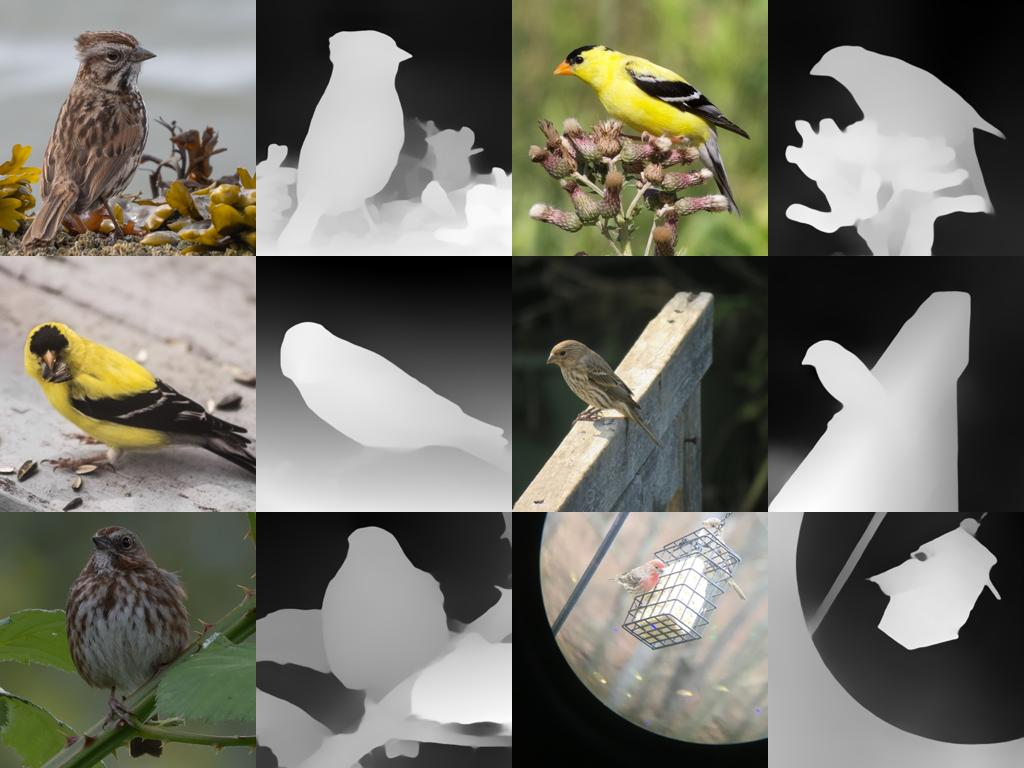

In [ ]:
NEW_PROMPT = 'a photo of a House Finch (Haemorhous mexicanus) perched on a snow-covered branch in winter'  # @param {type:"string"}

run_stage('encode', '--new-prompt', NEW_PROMPT)
show_image('kandinsky_controlnet_depth_hints.jpg', 'Cropped test photographs beside their depth hints')

<details>
<summary><b>Check your reasoning</b> — Section 5</summary>

Usually the bird and the branch it stands on are brightest, because they are nearest the camera, and open sky is darkest. Because each hint is min-max normalised, 255 means *the nearest thing in this photo*, not a distance in metres: two hints cannot be compared in absolute terms. Errors in the estimator — a blurred background read as near, a reflection read as far — become part of the condition the generator is asked to follow. Both conditions are fixed once computed, which is why a file of hints and a file of embeddings can serve every later process.
</details>

## 6. The frozen model: held-out denoising loss and depth-conditioned generations

**Section type:** Evaluation practice.  
**Question:** before any training, how well does the pretrained model reproduce these photographs' depth layouts and subjects?

The `frozen` stage builds the pipeline with `use_lora=True`, but the adapter's B matrices start at zero, so until Section 8 this is exactly the pretrained model. Three kinds of number are read and kept for the comparison.

1. **Held-out denoising loss** (`pipe.evaluate`): each validation and test photograph is MoVQ-encoded, noised at five fixed timesteps (100, 300, 500, 700, 900) with a seeded noise tensor, and the UNet — given the caption's embedding and the photograph's own hint — predicts that noise. The score is the mean squared error. The same seed gives the same latents, noise and timesteps later, so the adapted number is a *paired* comparison.
2. **CLIP scores** (`score_generations`): each of the 12 test photographs contributes its caption and its hint, and one image is generated from them at a fixed seed (20 steps, guidance 4.0). CLIP ViT-B/32 scores prompt alignment, which caption each image is nearest to, and similarity to the held-out photographs. `real_photo_reference` scores the held-out real photographs the same way, **leave-one-out**: each photograph's reference similarity is measured against the *other* held-out photographs of its caption, itself excluded. It is a reference line, not a ceiling: a generator conditioned on the prompt can match the prompt more closely than a photograph does, so generated images can score above it on prompt similarity, and on reference similarity, where they are compared with all the held-out photographs of their caption.
3. **Depth fidelity** (`score_depth_fidelity`): the estimator measures the depth of each generated image, and the notebook reports its Pearson correlation with the hint and the mean error after aligning scale and offset. The same numbers against *another* image's hint are the mismatched-hint baseline — what an image that ignored its hint would score. `real_photo_depth_ceiling` re-measures the real photographs as a check of the measurement itself.

The stage also keeps the twelve generated images in the run directory, so Sections 7 and 9 can show them beside their own results.

**Predict first:** will the depth correlation of the frozen model's images be closer to 1.0 or to the mismatched baseline? Will CLIP label accuracy be closer to the real-photo reference or to chance (1 in 6)? Which timestep will have the largest denoising loss: 100 (a little noise) or 900 (almost all noise)?

**What to notice:** the per-timestep loss **falling** as the noise level rises — largest at t = 100, smallest at t = 900 — so the smallest timestep supplies most of the mean (the `share_of_test_mean_by_timestep` line); generated birds whose layout follows the hint; depth correlation well above the mismatched baseline; CLIP prompt similarity of the generated images that may sit above the real photographs' (the reference is not a ceiling); and a real-photo depth check near 1.0, which shows the measurement is consistent rather than that 1.0 is reachable.

Running stage 'frozen' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/frozen.log


W1004 13:15:55.375000 4452 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:15:55.435000 4452 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

{'frozen_clip': {'clip_prompt_similarity': 32.305, 'label_accuracy': 0.75, 'reference_similarity': 70.583}, 'real_photo_reference': {'clip_prompt_similarity': 30.25, 'label_accuracy': 0.9167, 'reference_similarity': 57.722}, 'reference_kind': 'leave-one-out real-photo reference'}


{'frozen_depth_fidelity': {'depth_correlation': 0.864233, 'depth_aligned_mae': 0.102967, 'mismatched_depth_correlation': 0.25601, 'mismatched_depth_aligned_mae': 0.241902}, 'real_photo_depth_check': {'depth_correlation': 1.0, 'depth_aligned_mae': 0.0}}


{'grid': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_frozen_grid.jpg'}


{'stage': 'frozen', 'status': 'ok', 'seconds': 177.0}


Frozen model: each hint beside the image generated from it -> /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_frozen_grid.jpg


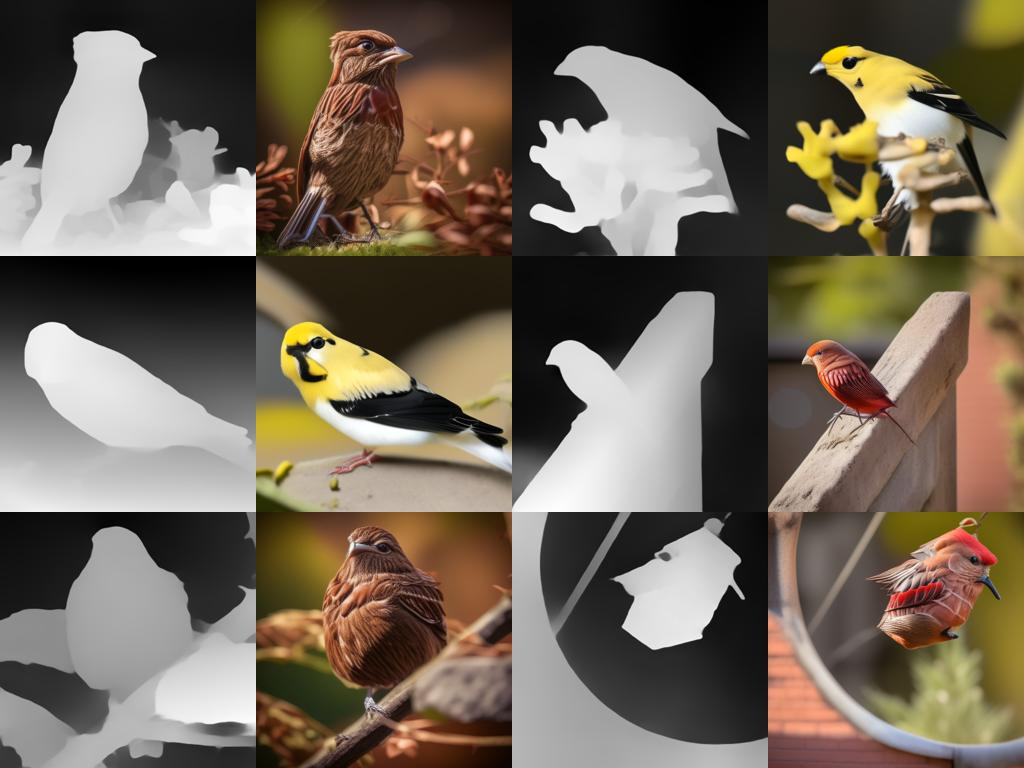

In [ ]:
STEPS = 20  # @param {type:"integer"}
GUIDANCE_SCALE = 4.0  # @param {type:"number"}

run_stage('frozen', '--steps', STEPS, '--guidance', GUIDANCE_SCALE)
show_image('kandinsky_controlnet_depth_frozen_grid.jpg', 'Frozen model: each hint beside the image generated from it')

<details>
<summary><b>Check your reasoning</b> — Section 6</summary>

A ControlNet-style model is trained to follow its hint, so the frozen model's depth correlation is expected to sit well above the mismatched baseline even before any adaptation; how far below 1.0 it stays reflects both the generator and the estimator's own noise. CLIP label accuracy asks whether CLIP can tell which of the six species each generated image shows. In the recorded Kaggle T4 run of the previous revision the frozen model already reached 0.75 (9 of 12) against chance 0.17 and 0.92 for the real photographs: the pretrained model already separates most of the six species, so adaptation has little room on 12 images, and one image is 0.083. Its prompt similarity (32.3) was above the real photographs' (30.3), because a generator renders the prompt more literally than a photograph does — which is why the real photographs are a reference, not a ceiling.

The denoising loss **falls** as the timestep rises. The UNet predicts the noise that was added (ε-prediction: the scheduler's `prediction_type` is `epsilon`). At t = 900 the latent is almost all noise, so the noise is nearly the input itself and is easy to predict; at t = 100 only a little noise sits on the image and is hard to separate from it. The recorded frozen test loss went 0.273, 0.066, 0.018, 0.004 and 0.0006 from t = 100 to t = 900, so the t = 100 term is about 76 % of the mean, and a change in the mean is mostly a change at the smallest timestep. None of these numbers says whether an image *looks good*; that needs a person.
</details>

## 7. Change one thing: the depth hint

**Section type:** Core concept (guided activity: Predict → Change one thing → Run → Observe → Explain).  
**Question:** how much of the image's layout comes from the hint rather than from the prompt?

The `activity` stage regenerates the first four test prompts with **the same prompts, seeds, steps and guidance** as Section 6 — only the hint changes, selected by `ACTIVITY_HINT`:

- `flat` (default): a constant depth map, i.e. *no* spatial information;
- `mismatched`: the hint of a different test photograph;
- `own`: the original hint, which should reproduce Section 6 (a control).

Depth fidelity is measured against each record's **own** hint, the layout Section 6 asked for, and compared with the Section 6 numbers for the same four images. The activity does not feed into training or the final comparison. Each run writes `outputs/activity_<hint>.json`, which a rerun with another hint leaves in place, and `outputs/activity.json`, the latest run with its time. The Section 9 evaluation report records the activity as it stood when Section 9 ran, under `activity_at_evaluation`, so a rerun after Section 9 does not change the report.

**Predict first:** with a flat hint, will the images still show a bird? Will their depth still correlate with the original photographs' layouts? Write down a number for the correlation before you run the cell.

**What to notice:** the prompt still decides *what* appears; the hint decides *where* and *how near*. With `flat` the correlation with the original layout should drop towards the mismatched baseline of Section 6; with `own` it should match Section 6 up to GPU nondeterminism. Try `mismatched` next and explain the difference.

Running stage 'activity' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/activity.log


W1004 13:18:54.589000 5199 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:18:54.650000 5199 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'hint_given': 'flat', 'depth_correlation_with_original_layout': {'section_6_own_hint': 0.9204, 'this_activity': 0.470469}, 'section_6_mismatched_baseline': 0.25601, 'clip_prompt_similarity': 32.572, 'written_at': '2026-10-04T13:19:34Z', 'file': 'outputs/activity_flat.json'}


{'grid': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_activity_grid.jpg'}


{'stage': 'activity', 'status': 'ok', 'seconds': 117.4}


Section 6 image, the changed hint, and the image generated from it -> /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_activity_grid.jpg


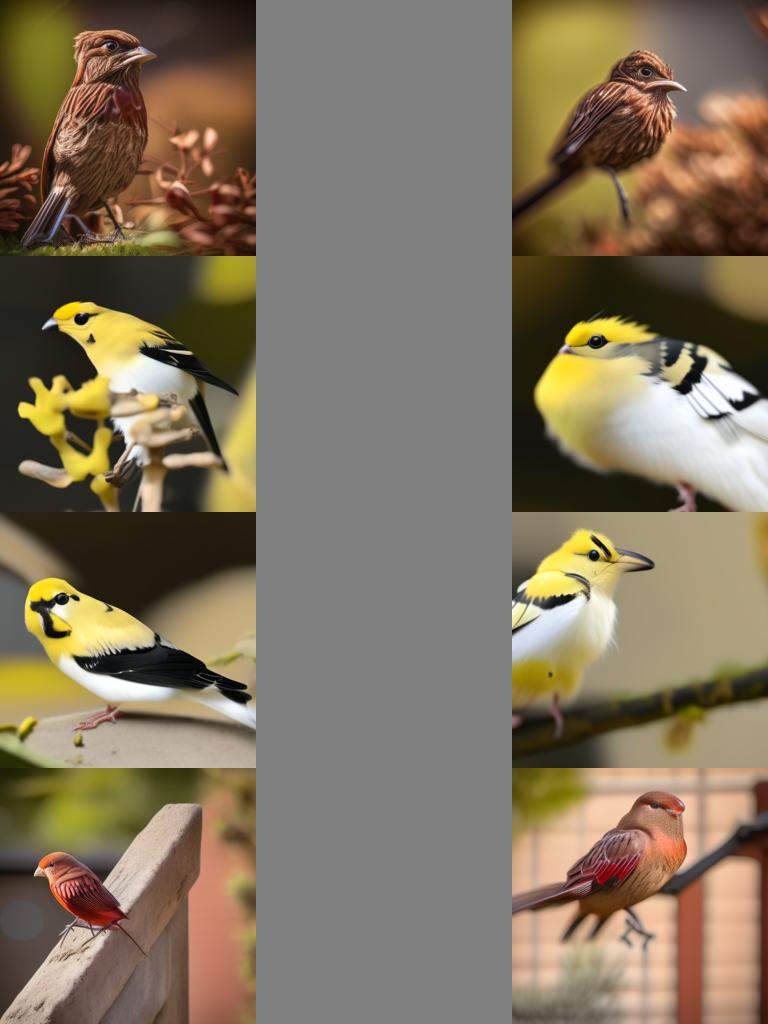

In [ ]:
ACTIVITY_HINT = 'flat'  # @param ["flat", "mismatched", "own"]

run_stage('activity', '--hint', ACTIVITY_HINT)
show_image('kandinsky_controlnet_depth_activity_grid.jpg', 'Section 6 image, the changed hint, and the image generated from it')

<details>
<summary><b>Check your reasoning</b> — Section 7</summary>

With a flat hint the model still paints a bird, because the prompt embedding carries the subject, but the scene's arrangement is no longer tied to the original photograph, so its depth correlation with that layout falls towards the level of an unrelated hint. With a mismatched hint the bird is placed where the *other* photograph's bird was. That separation — words for content, hint for layout — is what the depth conditioning buys. Four images at one seed are an illustration, not a measurement: repeat with other seeds before drawing a firm conclusion.
</details>

## 8. Bounded LoRA fine-tuning

**Section type:** Core concept (adaptation).  
**Question:** can a small adapter teach the model these six species without disturbing its depth conditioning?

The `adapt` stage calls `pipe.adapt`, which trains the 176 LoRA tensors (rank 8, 1,646,592 parameters — about 0.13 % of the UNet) that `peft` attached to the attention projections `to_q`, `to_k`, `to_v` and `to_out.0`, and nothing else: the UNet base weights, its hint encoder, the MoVQ, the prior and the depth estimator are frozen. This is **parameter-efficient gradient training**, not full fine-tuning. Each step takes one training photograph's latent (MoVQ-encoded once), its caption embedding and its own depth hint, draws a timestep and a noise tensor (both seeded), and minimises the MSE between the predicted and the true noise. The optimiser is AdamW at a fixed learning rate with gradient-norm clipping at 1.0 and float16 autocast with loss scaling on CUDA. Epoch 0 records the frozen model's validation loss, and the epoch with the lowest validation loss is kept. Before its process ends, the stage records two reference values of the trained model still in memory — its test denoising loss and one image at a fixed prompt, hint and seed — and exports the adapter as `outputs/kandinsky_controlnet_depth_adapter/` (`adapter.safetensors` + `manifest.json`).

**What to notice:** the training loss is noisy, because every step draws a random timestep; the validation loss is the number that decides which epoch is kept. A falling training loss alone is not evidence of better images. The exported artifact holds 176 tensors of a few MB, with its SHA-256.

In [ ]:
EPOCHS = 4  # @param {type:"integer"}
LEARNING_RATE = 1e-4  # @param {type:"number"}
BATCH_SIZE = 1  # @param {type:"integer"}

run_stage('adapt', '--epochs', EPOCHS, '--lr', LEARNING_RATE, '--batch-size', BATCH_SIZE)

Running stage 'adapt' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/adapt.log


W1004 13:20:53.347000 5707 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:20:53.404000 5707 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


{'epoch': 0, 'train_loss': None, 'val_denoising_mse': 0.070686, 'note': 'frozen model (LoRA at initialisation: B = 0)'}


...

{'epoch': 3, 'train_loss': 0.0385, 'val_denoising_mse': 0.070232}


{'epoch': 4, 'train_loss': 0.0663, 'val_denoising_mse': 0.070062}


{'trainable_parameters': 1646592, 'total_parameters': 1255075804, 'steps': 144, 'best_epoch': 4, 'precision': 'float16 autocast + GradScaler', 'seconds': 77.7, 'gpu_memory_gb': 2.71}


{'artifact': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_adapter', 'format': 'org.valcorza.kandinsky-controlnet-depth.adapter.v1', 'tensors': 176, 'bytes': 6607664, 'sha256': 'e5e108770862df44...'}


{'stage': 'adapt', 'status': 'ok', 'seconds': 180.6}


## 9. Held-out evaluation: the paired comparison

**Section type:** Evaluation practice.  
**Question:** on photographs the adapter never saw, did adaptation help, and did it cost depth fidelity?

The test photographs were never used for training or for choosing the epoch. The `evaluate` stage is a fresh process: it loads the adapter from the exported files — the artifact you would ship, not the object that was trained — and scores it exactly as the frozen model was scored in Section 6 — the same seed, so the same latents, noise and timesteps, and the same 12 prompt/hint/seed triples for generation — and the table puts frozen, adapted and reference numbers side by side. The stage asserts only what the procedure guarantees: the kept epoch's validation loss is no higher than the frozen model's, and the exported adapter reproduces the recorded value. The test numbers are printed, not asserted: a worse held-out result is a valid result and is kept.

**Predict first:** which number will move most — the denoising loss, CLIP label accuracy or depth correlation?

**What to notice:** read each change beside its reference — the leave-one-out real-photo reference for CLIP (a reference line, not a ceiling) and the mismatched baseline for depth. With 12 images, a difference of one image in label accuracy is 0.083. The grid shows each hint, the frozen image and the adapted image; the full record is `outputs/kandinsky_controlnet_depth_evaluation_report.json`.

Running stage 'evaluate' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/evaluate.log


W1004 13:24:00.616000 6465 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:24:00.676000 6465 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

{'grid': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_adapted_grid.jpg'}


{'test_denoising_mse_change': -0.000591, 'note': 'held-out observation, not asserted'}


{'report': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_evaluation_report.json'}


{'stage': 'evaluate', 'status': 'ok', 'seconds': 162.9}


Hint, frozen model, adapted model: same prompts, same seeds -> /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_adapted_grid.jpg


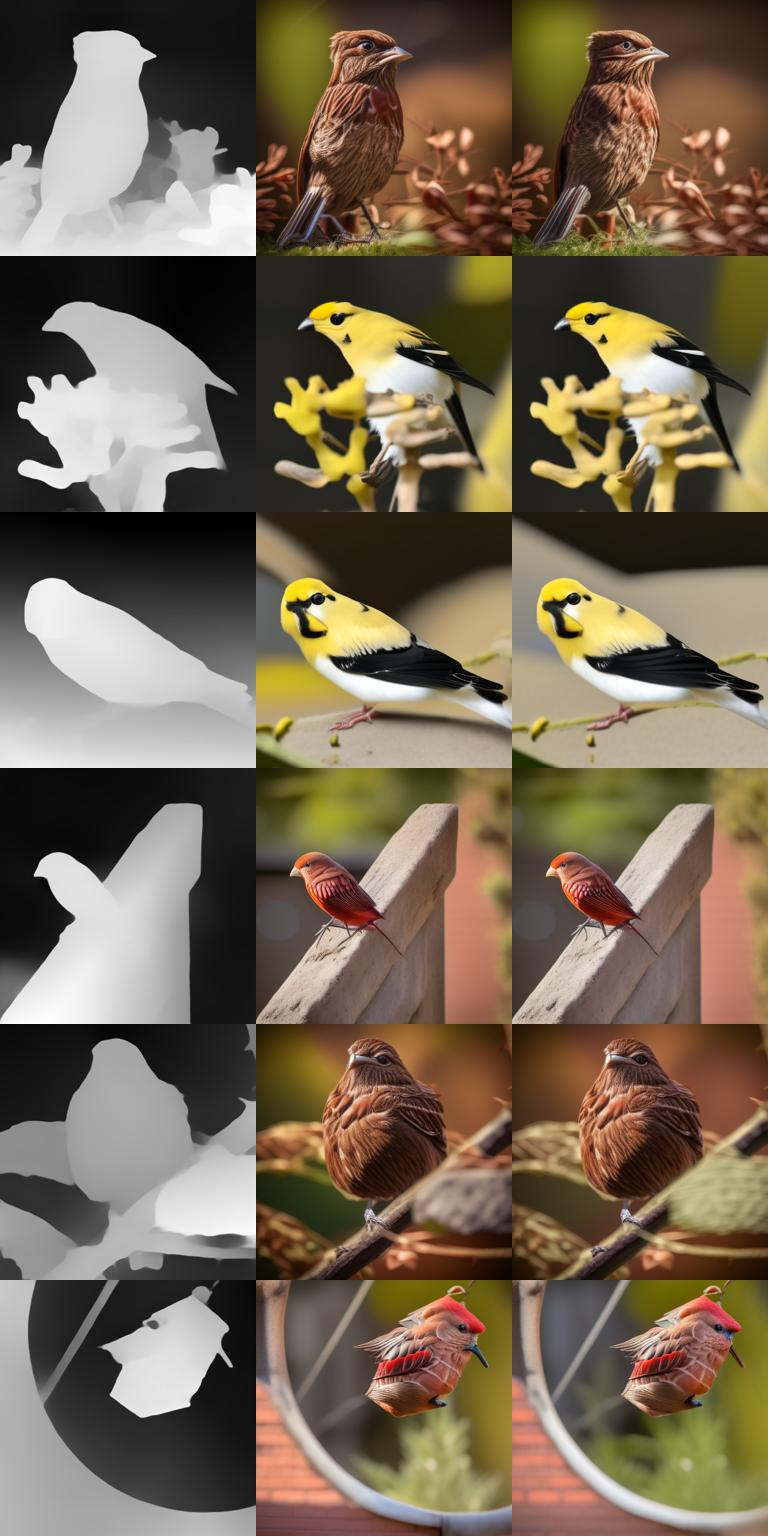

In [ ]:
run_stage('evaluate')
show_image('kandinsky_controlnet_depth_adapted_grid.jpg', 'Hint, frozen model, adapted model: same prompts, same seeds')

<details>
<summary><b>Check your reasoning</b> — Section 9</summary>

The denoising loss usually moves first and most reliably, because it is the quantity being optimised and it is measured with identical noise before and after. CLIP label accuracy and reference similarity can improve when the adapter learns what the six species look like, but with 12 images one image changes accuracy by 0.083, so small changes are within noise. Depth correlation should stay close to its frozen value: the hint encoder is frozen and the adapter only changes attention. A clear drop would mean the adaptation traded layout control for subject fidelity — a finding to report, not to hide.
</details>

## 10. Fresh reload and a new prompt

**Section type:** Engineering (artifact and reproducibility).  
**Question:** does the adapter work as a file, apart from the process that trained it?

The `reload` stage is a second fresh process. `KandinskyDepthPipeline.from_artifact` re-verifies the snapshots and checks the manifest — the artifact format, the decoder's id and revision, the prior and depth-estimator identities, the LoRA scope and the weights' SHA-256 — **before** deserialising; it loads a new UNet with the adapter attached and overlays the tensors. Nothing of the trained model survives in memory between processes, so this is a reload from files in the strictest sense. The stage then checks parity against the two reference values the `adapt` process recorded from the trained model while it was still in memory: the same held-out denoising loss and the same image for the same prompt, hint and seed. Loading is not the same as reproducing: only the parity check shows the artifact is equivalent. Only after parity holds does it render `NEW_PROMPT` — a composition that appears in no training caption — on the depth layouts of the first two test photographs (the same layout twice if a BYOD test set holds one); the CLIP and depth numbers are printed as a sanity check, not an evaluation. Finally it writes `outputs/kandinsky_controlnet_depth_result.json` with the provenance, the runtime versions and the comparison, and lists every file in the run's `outputs/`.

**What to notice:** an artifact of a few MB, a parity difference of 0 (or below the stated tolerance), the new-prompt numbers labelled as a sanity check, and the list of files under `outputs/`.

Running stage 'reload' in the isolated environment; log: /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/logs/reload.log


{'artifact': '/content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_adapter', 'format': 'org.valcorza.kandinsky-controlnet-depth.adapter.v1', 'tensors': 176, 'bytes': 6607664, 'sha256': 'e5e108770862df44...'}


W1004 13:26:46.403000 7160 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 13:26:46.455000 7160 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


...

  - outputs/prepare.json (2.2 KB)


  - outputs/reload.json (0.4 KB)


  - outputs/weights.json (2.1 KB)


{'stage': 'reload', 'status': 'ok', 'seconds': 120.2}


New prompt on the first test layout (reloaded adapter) -> /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_new_prompt_0.png


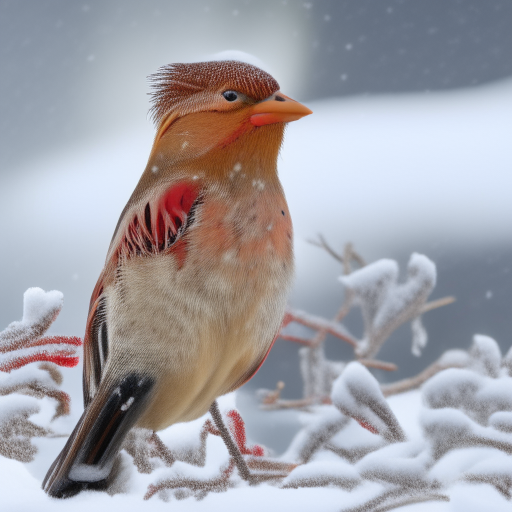

New prompt on the second test layout (reloaded adapter) -> /content/outputs/kandinsky_controlnet_depth/5a1517e18af0/outputs/kandinsky_controlnet_depth_new_prompt_1.png


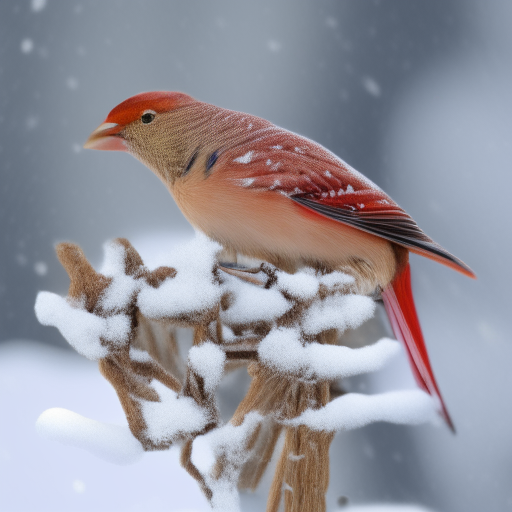

In [ ]:
run_stage('reload')
show_image('kandinsky_controlnet_depth_new_prompt_0.png', 'New prompt on the first test layout (reloaded adapter)')
show_image('kandinsky_controlnet_depth_new_prompt_1.png', 'New prompt on the second test layout (reloaded adapter)')

## 11. Troubleshooting

**Section type:** Engineering.

| Observation | What it means | What to do |
|---|---|---|
| Section 1 stops with `No GPU driver was found` or `CUDA was not detected`, or Section 2 stops with `The isolated environment cannot see a CUDA GPU` | the runtime has no GPU | Runtime → Change runtime type → T4 GPU, then Run all. This notebook is not supported on a CPU-only runtime; if Colab offers no GPU, your quota may be exhausted |
| Section 1 stops with `This notebook needs a Linux x86_64 GPU runtime` | a local Windows or macOS kernel, or an ARM machine | use Google Colab, Kaggle, or a Linux x86_64 machine with a CUDA GPU: the locked environment is built for manylinux x86_64 wheels |
| Section 1 stops with `Not enough free disk` | the four snapshots need about 17.8 GB and the isolated environment about 12 GB | start a fresh runtime with about 31 GB free; a `weights/` directory from an earlier run is reused and counted |
| `Carried file integrity failure` in Section 2 | a carried file was edited in the notebook | do not edit the infrastructure cells; open a fresh copy of the notebook from the repository |
| `uv 0.12.15 wheel size/hash mismatch`, or a `URLError` / timeout while downloading it | a network failure or an unexpected response from PyPI | re-run the Section 2 install cell; never replace the pinned URL or digest |
| `CalledProcessError` from `uv venv` or `uv pip install` (a hash mismatch, `Failed to download`, HTTP 5xx) | a transient PyPI or network failure, or a package that no longer matches the lock | re-run the Section 2 install cell (`uv` reuses what it already downloaded); if a hash mismatch repeats, stop and report it — never remove `--require-hashes`, a pin or a hash |
| `RuntimeError: Stage '…' failed (exit 2): …` | the stage raised an error; the text after the colon is the stage's own message, and its full log (with the traceback) is printed above and kept in the run directory's `logs/` | find the message in the rows below; a stage reads only files, so after fixing the cause re-run that cell and the cells after it |
| `… is missing: run the stage that writes it before …` | a learner cell was run before an earlier stage | run the notebook from the top, or re-run the earlier cells in order |
| `the dataset changed since 'prepare'` | the BYOD zip or the photo cache changed after Section 4 | re-run from Section 4 |
| `sha256 ... != manifest` or `size ... != manifest` | a download is incomplete or altered | delete the named file under `weights/` and re-run Section 3; never edit the manifest |
| `No space left on device` during a stage | the disk filled after the Section 1 check | start a fresh runtime with about 31 GB free |
| `CUDA out of memory` | a form field was raised, or another program holds GPU memory | keep `BATCH_SIZE = 1` and re-run that cell; each stage is its own process, so a failed stage's memory was released when it stopped; do not report a skipped stage as a result |
| A photo fetch fails in Section 4 | the open-data bucket is unreachable or a file changed | re-run the cell; a digest mismatch is refused on purpose, and verified photographs in `weights/inat-birds/` are reused |
| `ModuleNotFoundError: No module named 'google.colab'` with `USE_BYOD = True` | the upload dialog needs Google Colab | set `BYOD_PATH` to a zip already in the runtime, or keep `USE_BYOD = False` |
| BYOD: `captions.csv is missing columns` / `image sides must be within` / `split leaves no test record` / `split leaves N training records` | the upload does not meet the data contract | fix the zip as the message says: columns `id,file,caption`, sides 256..4096 px, at least one caption with three or more images, and at least 6 distinct images so that 4 remain for training after each caption with 3..7 images gives one test and one validation image (for example six of one caption) |
| `adapter depth estimator ... does not match` | an adapter from another estimator or revision | reload only adapters exported by this pipeline revision |

A negative or surprising held-out result is not an error. Keep it, and read Section 9's *Check your reasoning*.

## Interpretation and limits

A LoRA of 1.6 million parameters trained for a few minutes on 36 photographs and their depth hints changes the held-out denoising loss on twelve photographs the model never saw, and may move its depth-conditioned generations towards the held-out photographs of the same species. That is the claim the notebook can support: the adaptation contract teaches the UNet a narrow visual domain from a handful of captioned images while the depth conditioning stays in place, the held-out objective is measured on identical inputs before and after, and the exported artifact reloads in a fresh process with the same outputs.

The numbers are sample-sanity evidence. A denoising loss is the training objective, not a quality score. CLIP similarity and CLIP's nearest-caption vote are a frozen model's opinion, not a human judgement. Depth fidelity is measured by the same estimator that made the hints, so it rewards agreement with DPT, including DPT's mistakes. Twelve images from one seeded run give no dispersion estimate, and nothing here measures aesthetics, diversity or artefacts. Fine-tuning on a narrow domain can also erode the model elsewhere — the new prompt in Section 10 is a sanity check on one composition.

**Pretraining overlap.** The sample photographs are public iNaturalist web images. The generator's web-scale training data and the LAION-2B training data of the CLIP scorer may include some of them, so the CLIP numbers on the sample — label accuracy, reference similarity and the real-photo reference — may be optimistic. BYOD with private photographs avoids this.

## Conclude with evidence

Complete this in your own words, using only numbers this notebook printed:

> On [n] held-out photographs of [subject], the frozen model reached a denoising loss of [x] and a depth correlation of [r] against a mismatched-hint baseline of [b]; CLIP label accuracy was [a] against a real-photo reference of [c]. After [epochs] epochs of rank-8 LoRA training, these became [x'], [r'] and [a']. Changing only the hint to [flat / mismatched] changed the depth correlation from [r] to [r'']. Because [one seed, twelve images, one scorer, one estimator], these results do not show [generality / image quality / ...]. Next I would [collect ... / repeat with seeds ... / ask people to rate ...].

**Transfer:** try BYOD with photographs of a subject whose depth layout matters — rooms, streets, tabletop objects — and check whether the adapted model keeps following the hint.

Three things to carry to real data. **Captions and hints are both the contract:** the adapter learns caption text, image and depth together, so a caption that does not describe its image, or a hint estimated from a distorted crop, teaches noise. **Stratify by caption, and keep near-duplicates together:** every caption has held-out images, so the test measures new photographs of seen captions, not unseen captions; a random split assumes independent photographs, so bursts, crops or edits of one scene must not straddle it. **Licences travel with the outputs:** the Kandinsky and DPT weights are Apache-2.0 and the training photographs here are CC0; with your own data, the rights are yours to establish.

Successful execution proves that the recorded repository revision's pipeline modules and stage runner, carried in this standalone notebook and run in an isolated hash-locked environment, can stage and digest-verify four pinned safetensors snapshots, fetch and validate digest-pinned real photographs, compute depth hints, encode prompts and release the prior, execute bounded LoRA fine-tuning, evaluate the frozen and the adapted model on identical held-out inputs beside a leave-one-out real-photo reference and a mismatched-hint baseline, reload the exported adapter in a fresh process with parity to the trained model, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, image quality beyond the checks shown, or that the pinned safetensors conversion is bit-identical to the upstream `.bin` weights.

## References

- Repository README: https://github.com/kurtvalcorza/kandinsky-controlnet-depth-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/kandinsky-controlnet-depth-pipeline/blob/main/MODEL_CARD.md
- Weights notes: https://github.com/kurtvalcorza/kandinsky-controlnet-depth-pipeline/blob/main/docs/WEIGHTS.md
- Hugging Face decoder repository: https://huggingface.co/kandinsky-community/kandinsky-2-2-controlnet-depth (revision `08632524a2b7e3bed39a7901d92cdd07e37544d0`, conversion pull request #5)
- Hugging Face prior repository: https://huggingface.co/kandinsky-community/kandinsky-2-2-prior
- Hugging Face depth estimator: https://huggingface.co/Intel/dpt-large
- Shakhmatov, A., et al. (2023). Kandinsky 2.2: https://github.com/ai-forever/Kandinsky-2
- Zhang, L., Rao, A., & Agrawala, M. (2023). Adding conditional control to text-to-image diffusion models. ICCV: https://arxiv.org/abs/2302.05543
- Ranftl, R., Bochkovskiy, A., & Koltun, V. (2021). Vision transformers for dense prediction. ICCV: https://arxiv.org/abs/2103.13413
- uv (the installer that builds the isolated environment): https://docs.astral.sh/uv/
- Hu, E. J., et al. (2022). LoRA: Low-rank adaptation of large language models. ICLR: https://arxiv.org/abs/2106.09685
- Cherti, M., et al. (2023). Reproducible scaling laws for contrastive language-image learning. CVPR (the LAION CLIP scorer): https://arxiv.org/abs/2212.07143
- DIMER Notebook Specification 2.2 and Model Card Specification 1.2 (in the ml-worker repository)